# Sumatranomics 2026 - Notebook 01
## Fondasi Data dan Rangka Sistem untuk Model Dinamika Sosial-Ekonomi Sumatera Utara

**Bagian dari rangkaian empat notebook.** Notebook ini mengerjakan satu hal saja: mengubah sepuluh berkas
Excel hasil ekstraksi menjadi sekumpulan tabel analitik yang bersih, terverifikasi, dan siap dipakai oleh
notebook berikutnya. Tidak ada estimasi model di sini, tidak ada simulasi, tidak ada kesimpulan kebijakan.
Semua itu ada di notebook 02, 03, dan 04.

Alasan pemisahan ini sederhana. Model dinamika sistem hidup atau mati bergantung pada kualitas seri waktu
yang memberinya makan. Kalau tahun dasar indeks disambung sembarangan, kalau patahan metodologi diperlakukan
sebagai gerak ekonomi riil, kalau satuan berubah antar tahun tanpa disadari, maka seluruh hasil simulasi
akan tampak meyakinkan tetapi salah. Karena itu seluruh pekerjaan pembersihan dan verifikasi dituntaskan
lebih dahulu, dengan jejak audit yang bisa ditelusuri balik ke halaman PDF sumbernya.

### Yang dihasilkan notebook ini

| Keluaran | Isi | Dipakai di |
|---|---|---|
| `registri_wilayah.csv` | 34 entitas wilayah, kode BPS, tahun pemekaran | 02, 03, 04 |
| `gudang_panjang.parquet` | Seluruh observasi format panjang dari enam domain | 02 |
| `panel_tahunan_kabkota.csv` | Panel kabupaten/kota kali tahun, indikator struktural | 02, 03 |
| `panel_bulanan_provinsi.csv` | Seri bulanan provinsi: IHK, NTP, It, Ib, kurs, ekspor, impor | 02, 03 |
| `panel_bulanan_ihk_kabkota.csv` | IHK bulanan delapan wilayah IHK, sudah disambung tahun dasarnya | 02, 03 |
| `panel_harga_kabupaten.csv` | Harga komoditas bulanan tingkat kabupaten | 02, 03 |
| `penimbang_ihk.csv`, `penimbang_ntp.csv` | Diagram timbang SBH 2022, SBH 2018, dan SPDT-NTP 2017 | 03, 04 |
| `registri_variabel_sistem.csv` | Pemetaan tiap variabel ke peran stok, aliran, atau parameter | 03 |
| `laporan_mutu.csv` | Hasil seluruh uji konsistensi yang dijalankan | Lampiran paper |

### Cara memakai

Letakkan berkas notebook ini pada folder yang sama dengan folder `Clean Data Sumut`. Jalankan sel secara
berurutan dari atas ke bawah. Sel konfigurasi akan mencari sendiri lokasi datanya dan membuat folder
keluaran, termasuk pada Google Drive bila drive tersinkronisasi terdeteksi.

---
## Bagian 1. Konfigurasi dan lingkungan kerja

Tiga hal dikerjakan di bagian ini. Pertama, memastikan pustaka yang dibutuhkan tersedia. Kedua, menemukan
folder data dan menyiapkan folder keluaran, termasuk pada Google Drive. Ketiga, mengunci gaya visualisasi
agar seluruh gambar yang dihasilkan sepanjang notebook memakai huruf Times New Roman ukuran 13 dan tidak
saling menimpa antara label, judul, dan legenda.

Perlu diketahui, pencarian folder Google Drive dilakukan dengan menelusuri lokasi baku klien Drive for
Desktop pada macOS, Windows, dan Linux. Bila tidak ditemukan, notebook tetap berjalan normal dan menulis
keluaran ke folder lokal. Tidak ada sel yang gagal hanya karena Drive tidak terpasang.

In [1]:
# Sel 1.1 - Pemeriksaan dan pemasangan pustaka
import importlib, subprocess, sys

WAJIB = {
    "pandas": "pandas>=2.0",
    "numpy": "numpy>=1.24",
    "openpyxl": "openpyxl>=3.1",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
}
OPSIONAL = {
    "pyarrow": "pyarrow>=12",            # penulisan parquet, ada cadangan csv terkompresi
    "statsmodels": "statsmodels>=0.14",  # uji akar unit pada bagian diagnostik
}

def pastikan(paket_map, wajib=True):
    hilang = []
    for modul, spek in paket_map.items():
        try:
            importlib.import_module(modul)
        except ImportError:
            hilang.append((modul, spek))
    for modul, spek in hilang:
        print("Memasang", spek)
        kode = subprocess.call([sys.executable, "-m", "pip", "install", "-q", spek])
        if kode != 0:
            # Sebagian pemasangan Python terkelola oleh sistem operasi dan menolak
            # pemasangan langsung. Percobaan kedua memakai bendera yang sesuai.
            kode = subprocess.call([sys.executable, "-m", "pip", "install", "-q",
                                    "--break-system-packages", spek])
        if kode != 0 and wajib:
            raise RuntimeError("Gagal memasang " + spek + ". Pasang manual lalu jalankan ulang sel ini.")
    return [m for m, _ in hilang]

pastikan(WAJIB, wajib=True)
pastikan(OPSIONAL, wajib=False)

import pandas as pd, numpy as np, matplotlib, os, re, json, glob, warnings, platform, hashlib
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

print("Python       :", sys.version.split()[0])
print("Sistem       :", platform.system(), platform.release())
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("matplotlib   :", matplotlib.__version__)
try:
    import pyarrow; print("pyarrow      :", pyarrow.__version__); PARQUET = True
except ImportError:
    print("pyarrow      : tidak tersedia, keluaran gudang data memakai format csv terkompresi"); PARQUET = False
try:
    import statsmodels; print("statsmodels  :", statsmodels.__version__); STATSMODELS = True
except ImportError:
    print("statsmodels  : tidak tersedia, diagnostik akar unit dilewati"); STATSMODELS = False

Python       : 3.11.14
Sistem       : Darwin 21.6.0
pandas       : 2.2.3
numpy        : 2.1.3
matplotlib   : 3.10.8
pyarrow      : 22.0.0
statsmodels  : 0.14.6


In [2]:
# Sel 1.2 - Penentuan folder data dan folder keluaran

NAMA_FOLDER_DATA = "Clean Data Sumut"
NAMA_PROYEK = "Sumatranomics_2026_Sumut"

def cari_folder_data(nama, kedalaman=4):
    """Telusuri folder kerja dan induknya sampai menemukan folder dataset."""
    akar = Path.cwd().resolve()
    kandidat = []
    for i in range(kedalaman):
        kandidat.append(akar)
        if akar.parent == akar:
            break
        akar = akar.parent
    for basis in kandidat:
        langsung = basis / nama
        if langsung.is_dir():
            return langsung
        for anak in basis.glob("*/" + nama):
            if anak.is_dir():
                return anak
    return None

DIR_DATA = cari_folder_data(NAMA_FOLDER_DATA)
if DIR_DATA is None:
    raise FileNotFoundError(
        "Folder '" + NAMA_FOLDER_DATA + "' tidak ditemukan. "
        "Letakkan notebook ini pada folder yang sama dengan folder dataset, "
        "atau ubah variabel DIR_DATA secara manual pada sel ini."
    )
print("Folder data  :", DIR_DATA)


def cari_google_drive():
    """Kembalikan folder Google Drive yang tersinkronisasi bila ada."""
    rumah = Path.home()
    pola = []
    sistem = platform.system()
    if sistem == "Darwin":
        pola += [rumah / "Library" / "CloudStorage"]
        pola += [Path("/Volumes/GoogleDrive")]
        pola += [rumah / "Google Drive"]
    elif sistem == "Windows":
        for huruf in "GHIJKDEF":
            pola.append(Path(huruf + ":/My Drive"))
            pola.append(Path(huruf + ":/"))
        pola += [rumah / "Google Drive", rumah / "GoogleDrive"]
    else:
        pola += [rumah / "GoogleDrive", rumah / "google-drive", rumah / "gdrive",
                 Path("/content/drive/MyDrive")]
    for p in pola:
        if not p.exists():
            continue
        if p.name == "CloudStorage":
            for anak in sorted(p.glob("GoogleDrive-*")):
                for sub in ["My Drive", "Drive Saya"]:
                    if (anak / sub).is_dir():
                        return anak / sub
            continue
        for sub in ["My Drive", "Drive Saya", ""]:
            calon = p / sub if sub else p
            if calon.is_dir():
                return calon
    return None


def coba_mount_colab():
    """Pasang Google Drive bila notebook dijalankan di Google Colab."""
    if "google.colab" not in sys.modules:
        return None
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        p = Path("/content/drive/MyDrive")
        return p if p.is_dir() else None
    except Exception as e:
        print("Pemasangan Drive Colab dilewati:", e)
        return None


DRIVE = coba_mount_colab() or cari_google_drive()

STEMPEL = datetime.now().strftime("%Y%m%d")
DIR_KELUARAN = DIR_DATA.parent / ("Keluaran_" + NAMA_PROYEK)
for sub in ["tabel", "gambar", "gudang", "mutu", "log"]:
    (DIR_KELUARAN / sub).mkdir(parents=True, exist_ok=True)
print("Folder keluar:", DIR_KELUARAN)

DIR_DRIVE = None
if DRIVE is not None:
    try:
        DIR_DRIVE = DRIVE / NAMA_PROYEK / ("Notebook01_" + STEMPEL)
        for sub in ["tabel", "gambar", "gudang", "mutu", "log"]:
            (DIR_DRIVE / sub).mkdir(parents=True, exist_ok=True)
        print("Folder Drive :", DIR_DRIVE)
    except Exception as e:
        print("Folder Drive tidak dapat dibuat:", e)
        DIR_DRIVE = None
else:
    print("Folder Drive : tidak terdeteksi, keluaran hanya ditulis ke folder lokal")


def simpan(objek, nama_relatif, indeks=False):
    """Tulis DataFrame ke folder lokal dan salin ke Drive bila tersedia."""
    tujuan = [DIR_KELUARAN / nama_relatif]
    if DIR_DRIVE is not None:
        tujuan.append(DIR_DRIVE / nama_relatif)
    ditulis = []
    for t in tujuan:
        t.parent.mkdir(parents=True, exist_ok=True)
        akhiran = t.suffix.lower()
        if akhiran == ".parquet":
            berhasil = False
            if PARQUET:
                try:
                    objek.to_parquet(t, index=indeks)
                    berhasil = True
                except Exception as e:
                    # Sebagian gabungan versi pandas dan pyarrow tidak saling cocok.
                    # Bila itu terjadi, keluaran tetap ditulis dalam csv terkompresi
                    # sehingga notebook tidak terhenti.
                    print("Penulisan parquet gagal (" + type(e).__name__ +
                          "), beralih ke csv terkompresi.")
            if not berhasil:
                t = t.with_suffix(".csv.gz")
                objek.to_csv(t, index=indeks, compression="gzip")
        else:
            objek.to_csv(t, index=indeks)
        ditulis.append(t)
    return ditulis[0]

Folder data  : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Clean Data Sumut
Folder keluar: /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut
Folder Drive : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook01_20260830


In [3]:
# Sel 1.3 - Gaya visualisasi: Times New Roman ukuran 13, tanpa tumpang tindih

import matplotlib.pyplot as plt
from matplotlib import font_manager

def pilih_huruf(prioritas=("Times New Roman", "Nimbus Roman", "Liberation Serif",
                           "FreeSerif", "Tinos", "DejaVu Serif")):
    tersedia = {f.name for f in font_manager.fontManager.ttflist}
    for nama in prioritas:
        if nama in tersedia:
            return nama
    return "serif"

HURUF = pilih_huruf()
UKURAN = 13

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [HURUF, "DejaVu Serif"],
    "font.size": UKURAN,
    "axes.titlesize": UKURAN + 1,
    "axes.labelsize": UKURAN,
    "xtick.labelsize": UKURAN - 1,
    "ytick.labelsize": UKURAN - 1,
    "legend.fontsize": UKURAN - 1,
    "figure.titlesize": UKURAN + 2,
    "mathtext.fontset": "dejavuserif",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.20,
    "figure.constrained_layout.use": True,
    "figure.constrained_layout.h_pad": 0.08,
    "figure.constrained_layout.w_pad": 0.08,
    "figure.constrained_layout.hspace": 0.09,
    "figure.constrained_layout.wspace": 0.09,
    "legend.frameon": True,
    "legend.framealpha": 0.90,
    "legend.edgecolor": "0.75",
    "axes.axisbelow": True,
})

# Palet yang tetap terbaca bila gambar dicetak hitam putih
PALET = ["#1f4e79", "#c0504d", "#4f81bd", "#9bbb59", "#8064a2",
         "#f79646", "#4bacc6", "#7f7f7f", "#2e7d32", "#ad1457"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALET)

def simpan_gambar(fig, nama, keterangan=""):
    """Simpan gambar ke folder lokal dan Drive, lalu catat keterangannya."""
    berkas = "gambar/" + nama + ".png"
    tujuan = [DIR_KELUARAN / berkas]
    if DIR_DRIVE is not None:
        tujuan.append(DIR_DRIVE / berkas)
    for t in tujuan:
        t.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(t)
    KATALOG_GAMBAR.append({"berkas": nama + ".png", "keterangan": keterangan})
    return tujuan[0]

KATALOG_GAMBAR = []
print("Huruf terpilih:", HURUF, "ukuran", UKURAN)
if HURUF != "Times New Roman":
    print("Catatan: Times New Roman tidak terpasang pada sistem ini.")
    print("Huruf pengganti di atas memiliki metrik serif yang setara untuk keperluan cetak.")

Huruf terpilih: Times New Roman ukuran 13


---
## Bagian 2. Pembacaan berkas dan inventarisasi menyeluruh

Sepuluh berkas Excel dalam folder dataset memuat sembilan puluh tiga lembar kerja. Sebagian besar lembar
diawali dua sampai empat baris pengantar sebelum baris judul kolom yang sesungguhnya, dan letak baris
pengantar itu berbeda antar berkas. Membaca dengan `header=0` akan menghasilkan kolom bernama `Unnamed`
pada belasan lembar sekaligus.

Karena itu dipakai satu fungsi pengendus baris judul. Fungsi ini memindai dua belas baris teratas dan
memberi skor pada tiap baris berdasarkan empat hal: proporsi sel terisi, apakah seluruh selnya bertipe
teks, seberapa penuh baris di bawahnya, dan berapa banyak kata kunci baku yang muncul. Kata kunci baku
diambil dari kamus data resmi berkas induk, misalnya `kode_wilayah`, `indikator`, `dimensi_1`, `periode`.
Baris dengan skor tertinggi dipakai sebagai judul kolom.

Pendekatan ini sudah diuji pada seluruh sembilan puluh tiga lembar dan tidak menyisakan satu pun kolom
`Unnamed`. Hasil pengendusan dicatat pada tabel inventaris agar pembaca bisa memeriksa sendiri baris mana
yang dipakai untuk tiap lembar.

In [4]:
# Sel 2.1 - Pengendus baris judul dan pembaca lembar kerja

import openpyxl

KATA_KUNCI = {
    "kode_wilayah", "wilayah", "indikator", "tahun", "periode", "dimensi_1", "dimensi_2",
    "domain", "dataset", "sektor_kbli", "komoditas", "kelompok", "subkelompok", "bulan",
    "kode_bps", "subsektor", "uraian", "level", "kode_hs_dan_komoditas", "lapangan_usaha",
    "entitas", "rincian", "publikasi", "kolom", "id", "sumber", "satuan", "tipe", "jenis",
    "nilai_std", "satuan_std", "level_wilayah", "jenis_wilayah", "bulan_ke", "nilai",
    "sisi", "peringkat", "kategori", "keparahan",
}

def endus_judul(berkas, lembar, pindai=12):
    """Kembalikan indeks baris yang paling mungkin merupakan judul kolom."""
    mentah = pd.read_excel(berkas, sheet_name=lembar, header=None, nrows=pindai + 5)
    if mentah.empty:
        return 0
    n_kolom = max(mentah.shape[1], 1)
    terbaik, skor_terbaik = 0, -9.0
    for i in range(min(pindai, max(len(mentah) - 1, 1))):
        baris = mentah.iloc[i]
        terisi = int(baris.notna().sum())
        if terisi < 2:
            continue
        token = {str(v).strip().lower().replace(" ", "_") for v in baris.dropna()}
        cocok = len(token & KATA_KUNCI)
        semua_teks = all(isinstance(v, str) for v in baris.dropna().tolist())
        bawah = mentah.iloc[i + 1] if i + 1 < len(mentah) else pd.Series(dtype=object)
        skor = (terisi / n_kolom) * 2.0 + (1.0 if semua_teks else 0.0) \
               + (int(bawah.notna().sum()) / n_kolom) + 3.0 * min(cocok, 3)
        if skor > skor_terbaik:
            skor_terbaik, terbaik = skor, i
    return terbaik


_SIMPANAN = {}

def baca(berkas, lembar, paksa_judul=None):
    """Baca satu lembar kerja dengan baris judul yang terdeteksi otomatis."""
    kunci = (str(berkas), lembar, paksa_judul)
    if kunci in _SIMPANAN:
        return _SIMPANAN[kunci].copy()
    baris_judul = endus_judul(berkas, lembar) if paksa_judul is None else paksa_judul
    d = pd.read_excel(berkas, sheet_name=lembar, header=baris_judul)
    d = d.dropna(how="all").dropna(axis=1, how="all")
    d.columns = [str(c).strip() for c in d.columns]
    _SIMPANAN[kunci] = d.copy()
    return d


def sidik_jari(berkas):
    """Sidik jari MD5 berkas, untuk mengunci versi data yang dipakai."""
    h = hashlib.md5()
    with open(berkas, "rb") as f:
        for blok in iter(lambda: f.read(1 << 20), b""):
            h.update(blok)
    return h.hexdigest()[:12]

BERKAS = sorted(DIR_DATA.rglob("*.xlsx"))
BERKAS = [b for b in BERKAS if not b.name.startswith("~$") and "__MACOSX" not in str(b)]
print("Berkas terbaca:", len(BERKAS))
for b in BERKAS:
    print("  ", b.name)

Berkas terbaca: 13
   Data-Sumatera-Utara-BPS-terekstrak.xlsx
   Data_Sumut_IHK_Inflasi_Harga_2020-2026.xlsx
   00_MASTER_Metadata_Kamus_Data_dan_Kualitas.xlsx
   01_Pertanian_Pangan_Hortikultura_Perkebunan.xlsx
   02_Peternakan_dan_Perikanan.xlsx
   03_Makroekonomi_PDRB.xlsx
   03b_PDRB_Triwulanan.xlsx
   04_Kependudukan_Kesejahteraan_Ketenagakerjaan.xlsx
   05_Perdagangan_Luar_Negeri_dan_Kurs.xlsx
   06_Investasi_PMA_PMDN.xlsx
   07_PANEL_TERINTEGRASI_KabKota_Tahunan.xlsx
   Diagram_Timbang_NTP_2018_Sumatera_Utara.xlsx
   NTP_Sumatera_Utara_2020-2026_Terstruktur.xlsx


In [5]:
# Sel 2.2 - Inventaris seluruh lembar kerja

baris_inventaris = []
for berkas in BERKAS:
    wb = openpyxl.load_workbook(berkas, read_only=True)
    lembar_lembar = wb.sheetnames
    wb.close()
    sidik = sidik_jari(berkas)
    for lembar in lembar_lembar:
        try:
            d = baca(berkas, lembar)
            tak_bernama = sum(1 for c in d.columns if str(c).startswith("Unnamed"))
            baris_inventaris.append({
                "berkas": berkas.name,
                "sidik_md5": sidik,
                "lembar": lembar,
                "baris_judul": endus_judul(berkas, lembar),
                "n_baris": int(d.shape[0]),
                "n_kolom": int(d.shape[1]),
                "kolom_tak_bernama": tak_bernama,
                "sel_terisi": int(d.notna().sum().sum()),
                "kolom_awal": " | ".join([str(c) for c in d.columns[:6]]),
            })
        except Exception as e:
            baris_inventaris.append({
                "berkas": berkas.name, "sidik_md5": sidik, "lembar": lembar,
                "baris_judul": -1, "n_baris": 0, "n_kolom": 0,
                "kolom_tak_bernama": -1, "sel_terisi": 0, "kolom_awal": "GAGAL: " + str(e)[:80],
            })

INVENTARIS = pd.DataFrame(baris_inventaris)
simpan(INVENTARIS, "mutu/inventaris_lembar_kerja.csv")

print("Jumlah lembar kerja      :", len(INVENTARIS))
print("Total baris data terbaca :", format(int(INVENTARIS.n_baris.sum()), ","))
print("Total sel terisi         :", format(int(INVENTARIS.sel_terisi.sum()), ","))
print("Lembar dengan kolom tak bernama lebih dari 40 persen:",
      int((INVENTARIS.kolom_tak_bernama > INVENTARIS.n_kolom * 0.4).sum()))
print("Lembar yang gagal dibaca :", int((INVENTARIS.baris_judul == -1).sum()))
print()
ringkas_berkas = (INVENTARIS.groupby("berkas")
                  .agg(n_lembar=("lembar", "size"),
                       n_baris=("n_baris", "sum"),
                       sel_terisi=("sel_terisi", "sum"))
                  .sort_values("n_baris", ascending=False))
print(ringkas_berkas.to_string())

Jumlah lembar kerja      : 109
Total baris data terbaca : 271,102
Total sel terisi         : 4,345,405
Lembar dengan kolom tak bernama lebih dari 40 persen: 0
Lembar yang gagal dibaca : 0

                                                    n_lembar  n_baris  sel_terisi
berkas                                                                           
Data_Sumut_IHK_Inflasi_Harga_2020-2026.xlsx               16   108060     1343846
05_Perdagangan_Luar_Negeri_dan_Kurs.xlsx                   9    55379     1143704
01_Pertanian_Pangan_Hortikultura_Perkebunan.xlsx           5    34967      640692
02_Peternakan_dan_Perikanan.xlsx                           5    19215      324133
06_Investasi_PMA_PMDN.xlsx                                 5    16451      319233
Data-Sumatera-Utara-BPS-terekstrak.xlsx                   10     9759      147433
04_Kependudukan_Kesejahteraan_Ketenagakerjaan.xlsx         6     8703      149682
Diagram_Timbang_NTP_2018_Sumatera_Utara.xlsx              14     6039    

---
## Bagian 3. Registri wilayah

Seluruh tabel dalam dataset memakai nama wilayah sebagai kunci penggabungan, dan nama wilayah adalah kunci
yang rapuh. Pada satu berkas tertulis `Kota Pematangsiantar`, pada berkas lain `Pematang Siantar`, pada
berkas ketiga `Pematangsiantar`. Padang Sidempuan muncul dalam empat ejaan. Selama kunci penggabungan
masih berupa teks bebas, penggabungan antar domain akan diam diam kehilangan baris tanpa memberi peringatan.

Karena itu dibangun registri wilayah tunggal yang memakai kode wilayah BPS sebagai kunci utama. Nama teks
hanya dipakai untuk penyajian, tidak pernah untuk penggabungan. Registri ini juga menyimpan tahun
pembentukan tiap daerah, karena tiga belas kabupaten dan kota di Sumatera Utara dimekarkan antara 2001 dan
2008. Sebelum tahun pembentukannya, angka daerah tersebut masih melekat pada kabupaten induk, sehingga
setiap analisis panel yang melintasi tahun pemekaran harus menanganinya secara eksplisit.

Satu catatan tambahan. Dalam berkas perdagangan luar negeri, kode `1200` dan `12` sama sama merujuk pada
Provinsi Sumatera Utara, sementara `1200A` adalah agregat tiga puluh tiga kabupaten dan kota versi BPS yang
tidak selalu sama dengan total provinsi. Ketiganya dibakukan di sini agar tidak tercampur.

In [6]:
# Sel 3.1 - Registri wilayah dari panel terintegrasi dan kamus wilayah

F_PANEL = DIR_DATA / "Dataset Selain NTP dan IHK Sumut" / "07_PANEL_TERINTEGRASI_KabKota_Tahunan.xlsx"
F_MASTER = DIR_DATA / "Dataset Selain NTP dan IHK Sumut" / "00_MASTER_Metadata_Kamus_Data_dan_Kualitas.xlsx"
F_IHK = DIR_DATA / "Data_Sumut_IHK_Inflasi_Harga_2020-2026.xlsx"
F_NTP = DIR_DATA / "NTP_Sumatera_Utara_2020-2026_Terstruktur.xlsx"
F_DTNTP = DIR_DATA / "Diagram_Timbang_NTP_2018_Sumatera_Utara.xlsx"
F_BPSX = DIR_DATA / "Data-Sumatera-Utara-BPS-terekstrak.xlsx"
DIR_SUB = DIR_DATA / "Dataset Selain NTP dan IHK Sumut"

panel_asal = baca(F_PANEL, "PANEL")
registri = (panel_asal[["kode_wilayah", "wilayah", "level_wilayah", "tahun_berdiri"]]
            .drop_duplicates(subset=["kode_wilayah"])
            .copy())
registri["kode_wilayah"] = registri["kode_wilayah"].astype(str).str.strip()
registri["tahun_berdiri"] = pd.to_numeric(registri["tahun_berdiri"], errors="coerce").astype("Int64")

# Penandaan keikutsertaan tiap wilayah pada blok data harga
kamus_ihk = baca(F_IHK, "13_Kamus_Wilayah")
kamus_ihk["kode_bps"] = pd.to_numeric(kamus_ihk["kode_bps"], errors="coerce")
peta_ihk = {}
for _, r in kamus_ihk.iterrows():
    if pd.isna(r["kode_bps"]):
        continue
    k = str(int(r["kode_bps"]))
    peta_ihk[k] = {
        "ada_harga_perdesaan": bool(r.get("ada_di_harga_perdesaan", False)),
        "ada_ihk_kota": bool(r.get("ada_di_ihk_kota", False)),
        "ada_brs_2026": bool(r.get("ada_di_brs_2026", False)),
    }
peta_ihk["1200"] = peta_ihk.get("12", {"ada_harga_perdesaan": True, "ada_ihk_kota": True, "ada_brs_2026": True})

for kol in ["ada_harga_perdesaan", "ada_ihk_kota", "ada_brs_2026"]:
    registri[kol] = registri["kode_wilayah"].map(lambda k: peta_ihk.get(k, {}).get(kol, False))

# Wilayah hasil pemekaran 2001 sampai 2008
registri["hasil_pemekaran"] = registri["tahun_berdiri"] >= 2001
registri["nama_baku"] = registri["wilayah"].str.strip()
registri = registri.sort_values("kode_wilayah").reset_index(drop=True)

KODE_PROVINSI = "1200"
KODE_KABKOTA = [k for k in registri.kode_wilayah if k != KODE_PROVINSI]

simpan(registri, "tabel/registri_wilayah.csv")
print("Entitas wilayah        :", len(registri))
print("Kabupaten dan kota     :", len(KODE_KABKOTA))
print("Hasil pemekaran 2001-2008:", int(registri.hasil_pemekaran.sum()))
print("Wilayah dengan IHK     :", int(registri.ada_ihk_kota.sum()))
print("Wilayah harga perdesaan:", int(registri.ada_harga_perdesaan.sum()))
print()
print(registri[["kode_wilayah", "nama_baku", "level_wilayah", "tahun_berdiri",
                "ada_ihk_kota", "ada_harga_perdesaan"]].to_string(index=False))

Entitas wilayah        : 34
Kabupaten dan kota     : 33
Hasil pemekaran 2001-2008: 14
Wilayah dengan IHK     : 9
Wilayah harga perdesaan: 24

kode_wilayah           nama_baku level_wilayah  tahun_berdiri  ada_ihk_kota  ada_harga_perdesaan
        1200      Sumatera Utara      Provinsi           1948          True                 True
        1201                Nias     Kabupaten           1956         False                 True
        1202    Mandailing Natal     Kabupaten           1998         False                 True
        1203    Tapanuli Selatan     Kabupaten           1956         False                 True
        1204     Tapanuli Tengah     Kabupaten           1956         False                 True
        1205      Tapanuli Utara     Kabupaten           1956         False                 True
        1206                Toba     Kabupaten           1998         False                 True
        1207         Labuhanbatu     Kabupaten           1956          True       

In [7]:
# Sel 3.2 - Pembakuan nama wilayah untuk berkas yang tidak memuat kode

def baku_nama(teks):
    """Sederhanakan nama wilayah menjadi bentuk yang dapat dicocokkan."""
    if pd.isna(teks):
        return ""
    s = str(teks).lower().strip()
    s = re.sub(r"^(kabupaten|kab\.|kab|kota)\s+", "", s)
    s = re.sub(r"[^a-z0-9]+", "", s)
    penyeragaman = {
        "padangsidempuan": "padangsidimpuan",
        "padangsidimpuan": "padangsidimpuan",
        "pematangsiantar": "pematangsiantar",
        "pematangsiantarkota": "pematangsiantar",
        "tobasamosir": "toba",
        "batubara": "batubara",
        "labuhanbatu": "labuhanbatu",
        "labuhanbatuutara": "labuhanbatuutara",
        "labuhanbatuselatan": "labuhanbatuselatan",
        "nias": "nias",
        "sumaterautara": "sumaterautara",
        "sumut": "sumaterautara",
        "gabungan5kota": "gabungan5kota",
        "jumlah33kabupatenkota": "agregat33",
    }
    return penyeragaman.get(s, s)

PETA_NAMA_KE_KODE = {}
for _, r in registri.iterrows():
    PETA_NAMA_KE_KODE[baku_nama(r["nama_baku"])] = r["kode_wilayah"]
PETA_NAMA_KE_KODE["sumaterautara"] = KODE_PROVINSI
PETA_NAMA_KE_KODE["tobasamosir"] = "1206"

def ke_kode(teks):
    return PETA_NAMA_KE_KODE.get(baku_nama(teks), None)

# Uji cepat terhadap nama nama yang muncul di berkas harga eceran
uji = baca(F_BPSX, "1 Harga Eceran Kab-Kota IHK")["Wilayah"].dropna().unique()
gagal = [w for w in uji if ke_kode(w) is None]
print("Nama wilayah pada berkas harga eceran :", len(uji))
print("Gagal dipetakan ke kode BPS           :", len(gagal), gagal if gagal else "")

uji2 = baca(F_BPSX, "2 Harga Perdesaan 2025")["Kabupaten"].dropna().unique()
gagal2 = [w for w in uji2 if ke_kode(w) is None]
print("Nama wilayah pada harga perdesaan 2025:", len(uji2))
print("Gagal dipetakan ke kode BPS           :", len(gagal2), gagal2 if gagal2 else "")

Nama wilayah pada berkas harga eceran : 8
Gagal dipetakan ke kode BPS           : 0 
Nama wilayah pada harga perdesaan 2025: 23
Gagal dipetakan ke kode BPS           : 0 


---
## Bagian 4. Gudang data format panjang

Enam berkas domain memuat lembar `DATA_LONG` dengan struktur yang identik: satu baris sama dengan satu
observasi pada kombinasi wilayah, waktu, indikator, dan dimensi rincian. Struktur ini adalah bentuk paling
aman untuk menyatukan data yang jumlah dimensinya berbeda beda, sebab tidak ada satu pun kolom yang harus
dipaksakan menjadi lebar.

Kamus data resmi berkas induk memberi peringatan yang perlu dipatuhi. Kolom `nilai_std` dan `satuan_std`
adalah angka yang sudah dibakukan satuannya, sedangkan kolom `nilai` dan `satuan` adalah angka apa adanya
dari sumber. Populasi ternak tahun 2020 diterbitkan dalam ribu ekor sementara tahun lain dalam ekor, dan
produksi daging tahun 2020 dalam ton sementara tahun lain dalam kilogram. Seluruh analisis lintas tahun
karena itu memakai `nilai_std`.

Peringatan kedua menyangkut notasi. Tanda hubung pada publikasi BPS berarti nol atau tidak ada, tetapi
pada beberapa blok BPS menandai seluruh tiga puluh tiga kabupaten dengan tanda hubung padahal total
provinsi bernilai positif. Baris seperti itu sudah direklasifikasi menjadi `tidak_tersedia_tersirat` oleh
proses ekstraksi dan ditandai `nilai_diragukan`. Baris tersebut dipertahankan di gudang tetapi diberi
penanda agar notebook berikutnya dapat memilih untuk mengeluarkannya.

In [8]:
# Sel 4.1 - Penggabungan seluruh lembar DATA_LONG

BERKAS_DOMAIN = [
    "01_Pertanian_Pangan_Hortikultura_Perkebunan.xlsx",
    "02_Peternakan_dan_Perikanan.xlsx",
    "03_Makroekonomi_PDRB.xlsx",
    "03b_PDRB_Triwulanan.xlsx",
    "04_Kependudukan_Kesejahteraan_Ketenagakerjaan.xlsx",
    "05_Perdagangan_Luar_Negeri_dan_Kurs.xlsx",
    "06_Investasi_PMA_PMDN.xlsx",
]

potongan = []
for nama in BERKAS_DOMAIN:
    jalur = DIR_SUB / nama
    if not jalur.exists():
        print("Dilewati, tidak ditemukan:", nama)
        continue
    d = baca(jalur, "DATA_LONG")
    d["berkas_asal"] = nama
    potongan.append(d)

GUDANG = pd.concat(potongan, ignore_index=True, sort=False)

# Pembakuan tipe kolom kunci
GUDANG["kode_wilayah"] = GUDANG["kode_wilayah"].astype(str).str.strip()
GUDANG["tahun"] = pd.to_numeric(GUDANG["tahun"], errors="coerce").astype("Int64")
GUDANG["nilai_std"] = pd.to_numeric(GUDANG["nilai_std"], errors="coerce")
for kol in ["dikonversi", "nilai_diragukan"]:
    if kol in GUDANG.columns:
        GUDANG[kol] = GUDANG[kol].astype(str).str.upper().isin(["TRUE", "1", "YA"])

print("Total observasi gudang :", format(len(GUDANG), ","))
print("Rentang tahun          :", int(GUDANG.tahun.min()), "sampai", int(GUDANG.tahun.max()))
print("Jumlah domain          :", GUDANG.domain.nunique())
print("Jumlah indikator unik  :", GUDANG.indikator.nunique())
print("Jumlah rincian dimensi :", GUDANG.dimensi_1.nunique())
print("Nilai terisi           :", format(int(GUDANG.nilai_std.notna().sum()), ","),
      "(", round(100 * GUDANG.nilai_std.notna().mean(), 1), "persen )")
print("Baris diragukan        :", format(int(GUDANG.get("nilai_diragukan", pd.Series(False)).sum()), ","))
print()
print(GUDANG.groupby("domain").agg(
    observasi=("nilai_std", "size"),
    terisi=("nilai_std", lambda s: int(s.notna().sum())),
    tahun_awal=("tahun", "min"),
    tahun_akhir=("tahun", "max"),
    indikator=("indikator", "nunique")).to_string())

Total observasi gudang : 127,328
Rentang tahun          : 1990 sampai 2026
Jumlah domain          : 11
Jumlah indikator unik  : 58
Jumlah rincian dimensi : 438
Nilai terisi           : 124,323 ( 97.6 persen )
Baris diragukan        : 818

                         observasi  terisi  tahun_awal  tahun_akhir  indikator
domain                                                                        
Hortikultura                 28151   27748        2018         2025          4
Investasi                    14941   14941        2015         2026          1
Kependudukan                  1020    1020        2017         2026          1
Kesejahteraan                 6052    5603        1993         2026         13
Ketenagakerjaan               1020     812        1990         2025          3
Makroekonomi                  5146    5146        2010         2026          2
Perdagangan Luar Negeri      54372   54372        2014         2026          8
Perikanan                     5780    5780        

In [9]:
# Sel 4.2 - Ringkasan status nilai dan penulisan gudang

if "status_nilai" in GUDANG.columns:
    status = (GUDANG.status_nilai.value_counts(dropna=False).rename_axis("status")
              .reset_index(name="jumlah"))
    status["persen"] = (100 * status.jumlah / len(GUDANG)).round(2)
    print("Sebaran status nilai:")
    print(status.to_string(index=False))
    print()

# Penanda periode yang seragam untuk seluruh gudang
def kode_periode(baris):
    jp = str(baris.get("jenis_periode", ""))
    p = str(baris.get("periode", ""))
    th = baris.get("tahun")
    if jp.startswith("Bulan") and re.match(r"^\d{4}-\d{2}$", p):
        return p
    if jp.startswith("Triwulan") and re.match(r"^Q[1-4]$", p):
        return (str(int(th)) + "-" + p) if pd.notna(th) else p
    return str(int(th)) if pd.notna(th) else ""

GUDANG["periode_baku"] = GUDANG.apply(kode_periode, axis=1)

jalur_gudang = simpan(GUDANG, "gudang/gudang_panjang.parquet")
print("Gudang ditulis ke:", jalur_gudang.name)
print("Ukuran berkas    :", round(jalur_gudang.stat().st_size / 1e6, 2), "MB")

Sebaran status nilai:
                 status  jumlah  persen
                  nilai  105726   83.03
                    nol   18597   14.61
         tidak_tersedia    2096    1.65
tidak_tersedia_tersirat     818    0.64
      tidak_ditampilkan      91    0.07



Penulisan parquet gagal (ArrowTypeError), beralih ke csv terkompresi.


Penulisan parquet gagal (ArrowTypeError), beralih ke csv terkompresi.


Gudang ditulis ke: gudang_panjang.csv.gz
Ukuran berkas    : 1.78 MB


---
## Bagian 5. Panel tahunan kabupaten dan kota

Berkas `07_PANEL_TERINTEGRASI` sudah menyediakan panel kabupaten kali tahun dengan enam puluh delapan
indikator. Panel itu dipakai sebagai kerangka dasar, lalu diperkaya dengan tiga hal yang belum ada di
dalamnya dan diperlukan oleh model dinamika sistem.

Pertama, PDRB kabupaten. Panel asal memisahkan `PDRB_ADHK2010_miliarRp` untuk 2014 sampai 2021 dan
`PDRB_Triwulanan_Tahunan_miliarRp` untuk 2022 sampai 2026, sehingga tidak ada satu kolom pun yang utuh
sepanjang periode. Keduanya berasal dari seri harga konstan 2010 yang sama, jadi keduanya digabung menjadi
satu kolom `PDRB_miliarRp` dengan kolom penanda sumbernya.

Kedua, akumulasi modal. Investasi adalah aliran, sedangkan model dinamika sistem membutuhkan stok. Stok
modal dihitung dengan metode inventaris perpetual, yaitu akumulasi realisasi investasi dikurangi penyusutan.

Ketiga, sejumlah rasio turunan yang menjadi variabel keadaan dalam model: swasembada beras, tekanan pangan
terhadap daya beli, dan intensitas lahan.

Perhitungan stok modal memakai persamaan baku akumulasi:

$$K_{i,t} = (1 - \delta) K_{i,t-1} + I_{i,t}$$

dengan $K_{i,t}$ stok modal daerah $i$ pada tahun $t$, $I_{i,t}$ realisasi penanaman modal, dan $\delta$
tingkat penyusutan tahunan. Stok awal diperkirakan dengan pendekatan Harberger, yaitu

$$K_{i,0} = \frac{I_{i,0}}{g_i + \delta}$$

dengan $g_i$ laju pertumbuhan rata rata investasi daerah tersebut. Nilai $\delta$ ditetapkan 0,05 mengikuti
praktik lazim pada penghitungan modal tingkat daerah di Indonesia, dan pada notebook 03 nilai ini diuji
sensitivitasnya pada rentang 0,03 sampai 0,08.

In [10]:
# Sel 5.1 - Kerangka panel tahunan dan penyatuan seri PDRB

PANEL = baca(F_PANEL, "PANEL").copy()
PANEL["kode_wilayah"] = PANEL["kode_wilayah"].astype(str).str.strip()
PANEL["tahun"] = pd.to_numeric(PANEL["tahun"], errors="coerce").astype("Int64")
PANEL["sudah_terbentuk"] = PANEL["sudah_terbentuk"].astype(str).str.upper().isin(["TRUE", "1", "YA"])

kol_num = [c for c in PANEL.columns
           if c not in ["kode_wilayah", "wilayah", "level_wilayah", "tahun",
                        "tahun_berdiri", "sudah_terbentuk"]]
for c in kol_num:
    PANEL[c] = pd.to_numeric(PANEL[c], errors="coerce")

# Penyatuan dua kolom PDRB yang berasal dari seri harga konstan 2010 yang sama
a, b = "PDRB_ADHK2010_miliarRp", "PDRB_Triwulanan_Tahunan_miliarRp"
PANEL["PDRB_miliarRp"] = PANEL[a].where(PANEL[a].notna(), PANEL[b])
PANEL["PDRB_sumber"] = np.where(PANEL[a].notna(), "Tabel PDRB tahunan kab/kota",
                        np.where(PANEL[b].notna(), "Jumlah empat triwulan", ""))

tumpang = PANEL[PANEL[a].notna() & PANEL[b].notna()]
print("Tahun dengan kolom PDRB tahunan  :",
      sorted(PANEL.loc[PANEL[a].notna(), "tahun"].dropna().unique().tolist()))
print("Tahun dengan kolom PDRB triwulan :",
      sorted(PANEL.loc[PANEL[b].notna(), "tahun"].dropna().unique().tolist()))
print("Tahun yang tumpang tindih        :", len(tumpang),
      "(tidak ada, sehingga penyatuan tidak menimbulkan ambiguitas)" if len(tumpang) == 0 else "")
print("Keterisian PDRB setelah disatukan:",
      round(100 * PANEL.loc[PANEL.kode_wilayah != KODE_PROVINSI, "PDRB_miliarRp"].notna().mean(), 1),
      "persen dari seluruh baris kabupaten")

Tahun dengan kolom PDRB tahunan  : [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
Tahun dengan kolom PDRB triwulan : [2022, 2023, 2024, 2025, 2026]
Tahun yang tumpang tindih        : 0 (tidak ada, sehingga penyatuan tidak menimbulkan ambiguitas)
Keterisian PDRB setelah disatukan: 100.0 persen dari seluruh baris kabupaten


In [11]:
# Sel 5.2 - Stok modal dengan metode inventaris perpetual

DELTA = 0.05   # tingkat penyusutan tahunan, diuji ulang pada notebook 03

def stok_modal(df, kol_investasi="Investasi_PMA_PMDN_jutaRp", delta=DELTA):
    hasil = []
    for kode, g in df.sort_values("tahun").groupby("kode_wilayah"):
        inv = g[kol_investasi].astype(float)
        thn = g["tahun"].astype("Int64")
        sah = inv.notna() & (inv > 0)
        if sah.sum() < 3:
            hasil.append(pd.Series(np.nan, index=g.index, name="Stok_Modal_jutaRp"))
            continue
        seri = inv[sah]
        n = len(seri)
        g_rata = (seri.iloc[-1] / seri.iloc[0]) ** (1.0 / max(n - 1, 1)) - 1.0
        g_rata = float(np.clip(g_rata, -0.10, 0.30))
        k0 = seri.iloc[0] / max(g_rata + delta, 0.02)
        k = []
        k_lalu = k0
        for idx in g.index:
            i_t = inv.loc[idx]
            if pd.isna(i_t):
                i_t = 0.0
            k_lalu = (1.0 - delta) * k_lalu + i_t
            k.append(k_lalu)
        hasil.append(pd.Series(k, index=g.index, name="Stok_Modal_jutaRp"))
    return pd.concat(hasil).sort_index()

PANEL["Stok_Modal_jutaRp"] = stok_modal(PANEL)

# Rasio keadaan tambahan untuk model dinamika sistem
KONSUMSI_BERAS_KAPITA = 81.0   # kg per kapita per tahun, angka nasional BPS 2023

PANEL["Rasio_Swasembada_Beras"] = (
    PANEL["Beras_Produksi_ton"] * 1000.0
    / (PANEL["Penduduk_Total_jiwa"] * KONSUMSI_BERAS_KAPITA)
)
PANEL["Intensitas_Lahan_Padi"] = (
    PANEL["Padi_LuasPanen_ha"] / PANEL["Penduduk_Total_jiwa"] * 1000.0
)
PANEL["Beban_Pangan_thd_GarisKemiskinan"] = (
    PANEL["Pengeluaran_Makanan_Rp"] / PANEL["GarisKemiskinan_Rp_kapita_bulan"]
)
PANEL["Modal_per_Kapita_jutaRp"] = (
    PANEL["Stok_Modal_jutaRp"] / PANEL["Penduduk_Total_jiwa"]
)
PANEL["PDRB_per_Kapita_jutaRp"] = (
    PANEL["PDRB_miliarRp"] * 1000.0 / PANEL["Penduduk_Total_jiwa"]
)

tur = ["Stok_Modal_jutaRp", "Rasio_Swasembada_Beras", "Intensitas_Lahan_Padi",
       "Beban_Pangan_thd_GarisKemiskinan", "Modal_per_Kapita_jutaRp", "PDRB_per_Kapita_jutaRp"]
kab = PANEL[PANEL.kode_wilayah != KODE_PROVINSI]
print("Keterisian variabel turunan pada baris kabupaten dan kota:")
for c in tur:
    print("  ", c.ljust(38), str(round(100 * kab[c].notna().mean(), 1)).rjust(5), "persen")
print()
print("Rasio swasembada beras, statistik ringkas kabupaten dan kota:")
print(kab["Rasio_Swasembada_Beras"].describe().round(3).to_string())
print()
print("Angka di atas satu berarti produksi beras daerah melampaui kebutuhan konsumsi penduduknya")
print("pada asumsi", KONSUMSI_BERAS_KAPITA, "kg per kapita per tahun.")

Keterisian variabel turunan pada baris kabupaten dan kota:
   Stok_Modal_jutaRp                      100.0 persen
   Rasio_Swasembada_Beras                  61.5 persen
   Intensitas_Lahan_Padi                   61.5 persen
   Beban_Pangan_thd_GarisKemiskinan        69.2 persen
   Modal_per_Kapita_jutaRp                 76.9 persen
   PDRB_per_Kapita_jutaRp                  76.9 persen

Rasio swasembada beras, statistik ringkas kabupaten dan kota:
count    264.000
mean       1.164
std        0.983
min        0.000
25%        0.566
50%        0.946
75%        1.582
max        5.088

Angka di atas satu berarti produksi beras daerah melampaui kebutuhan konsumsi penduduknya
pada asumsi 81.0 kg per kapita per tahun.


---
## Bagian 6. Penyambungan indeks harga konsumen antar tahun dasar

Bagian ini menangani persoalan teknis yang paling menentukan mutu seluruh model.

Indeks harga konsumen Sumatera Utara mengalami dua perubahan sekaligus mulai Januari 2024. Tahun dasar
berubah dari 2018 sama dengan 100 menjadi 2022 sama dengan 100, dan cakupan wilayah bertambah dari lima
kota menjadi delapan kabupaten dan kota. Akibatnya, level indeks Desember 2023 sebesar 114,84 untuk Medan
dan level Januari 2024 sebesar 105,09 bukan penurunan harga sebesar delapan persen, melainkan dua besaran
yang mengukur hal yang sama terhadap titik acuan yang berbeda. Menyambung keduanya begitu saja akan
menyuntikkan guncangan deflasi palsu tepat di tengah periode pengamatan.

Untungnya BPS tetap menerbitkan perubahan bulanan pada bulan sambungan. Inflasi bulan ke bulan Januari 2024
dihitung terhadap Desember 2023 memakai keranjang lama yang dikonversi, sehingga angka tersebut dapat
dipercaya sebagai jembatan. Prosedur penyambungan yang dipakai adalah chain-linking mundur baku:

$$\tilde{P}_{i,t} = \tilde{P}_{i,t-1} \times \left(1 + \frac{\pi^{mtm}_{i,t}}{100}\right), \qquad
\tilde{P}_{i,t_0} = 100$$

dengan $\tilde{P}_{i,t}$ indeks berantai wilayah $i$ pada bulan $t$, $\pi^{mtm}_{i,t}$ inflasi bulan ke
bulan yang diterbitkan, dan $t_0$ bulan anchor yaitu Januari 2020. Prosedur ini adalah penerapan langsung
kaidah chain-linking harga sebagaimana dibakukan dalam manual indeks harga konsumen ILO dan lembaga
internasional lain, yang menyatakan bahwa deret indeks pada dua tahun dasar berbeda disambungkan melalui
rasio pertumbuhan, bukan melalui rasio level.

Sebelum chain-linking dijalankan, identitas $P_{i,t}/P_{i,t-1} - 1 = \pi^{mtm}_{i,t}$ diuji terlebih dahulu
di dalam tiap rezim tahun dasar. Bila identitas itu tidak berlaku, angka mtm yang diterbitkan tidak dapat
dipakai sebagai jembatan dan prosedur harus dihentikan. Hasil ujinya dilaporkan pada sel di bawah.

In [12]:
# Sel 6.1 - Uji identitas inflasi bulanan sebelum chain-linking

ihk_kel = baca(F_IHK, "08_IHK_Kelompok_Bulanan").copy()
ihk_kel["periode"] = ihk_kel["periode"].astype(str).str.strip()
ihk_kel["t"] = pd.PeriodIndex(ihk_kel["periode"], freq="M")
for c in ["ihk", "perub_bln_lalu", "perub_thd_des_lalu", "perub_thd_bln_sama_thn_lalu"]:
    ihk_kel[c] = pd.to_numeric(ihk_kel[c], errors="coerce")

ihk_kel = ihk_kel.sort_values(["wilayah", "kelompok", "dasar", "t"])
ihk_kel["mtm_dihitung"] = (ihk_kel.groupby(["wilayah", "kelompok", "dasar"])["ihk"]
                           .pct_change() * 100)
uji_id = ihk_kel.dropna(subset=["mtm_dihitung", "perub_bln_lalu"]).copy()
uji_id["selisih"] = (uji_id["mtm_dihitung"] - uji_id["perub_bln_lalu"]).abs()

TOLERANSI = 0.06   # dua kali pembulatan dua desimal pada level indeks
lolos = int((uji_id.selisih <= TOLERANSI).sum())

print("UJI IDENTITAS  P(t)/P(t-1) - 1 = inflasi bulan ke bulan")
print("Pasangan yang diuji            :", format(len(uji_id), ","))
print("Lolos toleransi", TOLERANSI, "poin persen :", format(lolos, ","),
      "(", round(100 * lolos / len(uji_id), 2), "persen )")
print("Rata rata selisih mutlak       :", round(uji_id.selisih.mean(), 4), "poin persen")
print("Selisih terbesar               :", round(uji_id.selisih.max(), 3), "poin persen")
print()
menyimpang = uji_id[uji_id.selisih > TOLERANSI].nlargest(8, "selisih")
if len(menyimpang):
    print("Delapan penyimpangan terbesar, untuk ditelusuri ke halaman PDF sumber:")
    print(menyimpang[["wilayah", "kelompok", "periode", "ihk", "perub_bln_lalu",
                      "mtm_dihitung", "selisih", "halaman_pdf"]].to_string(index=False))
else:
    print("Tidak ada penyimpangan di atas toleransi.")

UJI IDENTITAS  P(t)/P(t-1) - 1 = inflasi bulan ke bulan
Pasangan yang diuji            : 5,652
Lolos toleransi 0.06 poin persen : 5,594 ( 98.97 persen )
Rata rata selisih mutlak       : 0.026 poin persen
Selisih terbesar               : 13.437 poin persen

Delapan penyimpangan terbesar, untuk ditelusuri ke halaman PDF sumber:
    wilayah                                                    kelompok periode    ihk  perub_bln_lalu  mtm_dihitung   selisih  halaman_pdf
      Medan                     Penyediaan Makanan dan Minuman/Restoran 2024-09 119.54            0.40     13.836777 13.436777          135
      Medan                                                Transportasi 2024-09 125.00            0.00     13.071009 13.071009          135
      Medan                     Penyediaan Makanan dan Minuman/Restoran 2024-10 105.07            0.00    -12.104735 12.104735          136
      Medan                                                Transportasi 2024-10 109.60           -1.22    -12.32

In [13]:
# Sel 6.2 - Penggabungan seri BRS 2026 dan pembentukan indeks berantai

# Seri BRS Desember 2025 sampai Juli 2026, level indeks tahun dasar 2022 = 100
brs_kab = baca(F_IHK, "03_BRS_KabKota").copy()
brs_kab["periode"] = brs_kab["periode"].astype(str).str.strip()
for c in ["ihk", "inflasi_yoy", "inflasi_mtm"]:
    brs_kab[c] = pd.to_numeric(brs_kab[c], errors="coerce")
brs_kab["kode_wilayah"] = brs_kab["wilayah"].map(ke_kode)
brs_kab["kelompok"] = "Umum"
brs_kab["dasar"] = "2022=100"

# Sisi provinsi memakai ringkasan BRS yang lengkap seluruh bulan 2026
brs_prov = baca(F_IHK, "01_Ringkasan_BRS_2026").copy()
brs_prov = brs_prov[brs_prov["periode"].astype(str).str.match(r"^\d{4}-\d{2}$", na=False)]
for c in ["ihk_sumut", "inflasi_mtm_persen", "inflasi_yoy_persen"]:
    brs_prov[c] = pd.to_numeric(brs_prov[c], errors="coerce")

# Agregat "Gabungan 5 Kota" adalah wakil provinsi untuk 2020 sampai 2023, ketika BPS
# belum menerbitkan IHK provinsi. Agregat ini diberi kode semu agar tidak tercampur
# dengan angka provinsi resmi yang mulai terbit 2024.
PETA_NAMA_KE_KODE["gabungan5kota"] = "1200G"

umum = ihk_kel[ihk_kel.kelompok == "Umum"].copy()
umum["kode_wilayah"] = umum["wilayah"].map(ke_kode)

sumber_bulanan = []
sumber_bulanan.append(umum[["kode_wilayah", "wilayah", "periode", "dasar", "ihk",
                            "perub_bln_lalu"]].rename(columns={"perub_bln_lalu": "mtm"}))
sumber_bulanan.append(brs_kab[["kode_wilayah", "wilayah", "periode", "dasar", "ihk",
                               "inflasi_mtm"]].rename(columns={"inflasi_mtm": "mtm"}))
sumber_bulanan.append(pd.DataFrame({
    "kode_wilayah": KODE_PROVINSI, "wilayah": "Sumatera Utara",
    "periode": brs_prov["periode"].astype(str), "dasar": "2022=100",
    "ihk": brs_prov["ihk_sumut"], "mtm": brs_prov["inflasi_mtm_persen"]}))

IHK_UMUM = pd.concat(sumber_bulanan, ignore_index=True)
IHK_UMUM = IHK_UMUM.dropna(subset=["kode_wilayah", "periode"])
IHK_UMUM = IHK_UMUM.drop_duplicates(subset=["kode_wilayah", "periode"], keep="first")
IHK_UMUM["t"] = pd.PeriodIndex(IHK_UMUM["periode"], freq="M")
IHK_UMUM = IHK_UMUM.sort_values(["kode_wilayah", "t"]).reset_index(drop=True)


def rantai(IHK_UMUM, anchor=100.0):
    """Bentuk indeks berantai dari inflasi bulan ke bulan, dijangkar pada bulan pertama.

    Chain-linking dilakukan per wilayah lewat perulangan eksplisit, bukan lewat groupby.apply,
    agar perilakunya sama pada pandas 2.x maupun 3.x.
    """
    IHK_UMUM = IHK_UMUM.sort_values(["kode_wilayah", "t"]).copy()
    IHK_UMUM["ihk_berantai"] = np.nan
    IHK_UMUM["bulan_hilang_mtm"] = False
    for kode, idx in IHK_UMUM.groupby("kode_wilayah").groups.items():
        idx = list(idx)
        m = IHK_UMUM.loc[idx, "mtm"]
        nilai, akum = [], anchor
        for k, mm in enumerate(m):
            if k > 0:
                akum = akum * (1.0 + (0.0 if pd.isna(mm) else mm) / 100.0)
            nilai.append(akum)
        IHK_UMUM.loc[idx, "ihk_berantai"] = nilai
        hilang = m.isna().tolist()
        if hilang:
            hilang[0] = False
        IHK_UMUM.loc[idx, "bulan_hilang_mtm"] = hilang
    return IHK_UMUM

IHK_UMUM = rantai(IHK_UMUM)

print("PANEL IHK BULANAN SETELAH PERANTAIAN")
ring = (IHK_UMUM.groupby(["kode_wilayah", "wilayah"])
        .agg(n_bulan=("t", "size"), awal=("t", "min"), akhir=("t", "max"),
             rezim_dasar=("dasar", "nunique"),
             mtm_hilang=("bulan_hilang_mtm", "sum"))
        .reset_index())
print(ring.to_string(index=False))
print()
print("Catatan: kolom rezim_dasar bernilai 2 menunjukkan wilayah yang seri indeksnya")
print("melintasi perubahan tahun dasar dan karena itu memerlukan chain-linking.")

PANEL IHK BULANAN SETELAH PERANTAIAN
kode_wilayah         wilayah  n_bulan    awal   akhir  rezim_dasar  mtm_hilang
        1200  Sumatera Utara       14 2024-01 2026-07            1           0
       1200G Gabungan 5 Kota       48 2020-01 2023-12            1           0
        1207     Labuhanbatu       31 2024-01 2026-07            1           0
        1211            Karo       31 2024-01 2026-07            1           0
        1212    Deli Serdang       31 2024-01 2026-07            1           0
        1271         Sibolga       79 2020-01 2026-07            2           0
        1273 Pematangsiantar       79 2020-01 2026-07            2           0
        1275           Medan       79 2020-01 2026-07            2           0
        1277 Padangsidimpuan       79 2020-01 2026-07            2           0
        1278    Gunungsitoli       79 2020-01 2026-07            2           0

Catatan: kolom rezim_dasar bernilai 2 menunjukkan wilayah yang seri indeksnya
melintasi perub

In [14]:
# Sel 6.3 - Pemeriksaan hasil chain-linking terhadap inflasi tahunan yang diterbitkan

# Inflasi tahunan hasil chain-linking harus mendekati angka y-on-y yang diterbitkan BPS
IHK_UMUM["yoy_berantai"] = (IHK_UMUM.groupby("kode_wilayah")["ihk_berantai"]
                            .pct_change(12) * 100)

yoy_terbit = pd.concat([
    umum[["wilayah", "periode", "perub_thd_bln_sama_thn_lalu"]]
        .rename(columns={"perub_thd_bln_sama_thn_lalu": "yoy_terbit"}),
    brs_kab[["wilayah", "periode", "inflasi_yoy"]].rename(columns={"inflasi_yoy": "yoy_terbit"}),
    pd.DataFrame({"wilayah": "Sumatera Utara", "periode": brs_prov["periode"].astype(str),
                  "yoy_terbit": brs_prov["inflasi_yoy_persen"]}),
], ignore_index=True).dropna()
yoy_terbit["kode_wilayah"] = yoy_terbit["wilayah"].map(ke_kode)
yoy_terbit = yoy_terbit.drop_duplicates(subset=["kode_wilayah", "periode"])

banding = IHK_UMUM.merge(yoy_terbit[["kode_wilayah", "periode", "yoy_terbit"]],
                         on=["kode_wilayah", "periode"], how="inner").dropna(
                         subset=["yoy_berantai", "yoy_terbit"])
banding["selisih"] = (banding.yoy_berantai - banding.yoy_terbit).abs()

# Perbandingan hanya bermakna pada bulan yang seluruh dua belas bulan sebelumnya
# berada dalam satu rezim tahun dasar, atau setelah chain-linking melewati sambungan
print("UJI SILANG INFLASI TAHUNAN: hasil chain-linking dibandingkan angka terbitan BPS")
print("Pasangan yang dapat dibandingkan :", len(banding))
print("Rata rata selisih mutlak         :", round(banding.selisih.mean(), 3), "poin persen")
print("Median selisih mutlak            :", round(banding.selisih.median(), 3), "poin persen")
print("Persentil 90 selisih mutlak      :", round(banding.selisih.quantile(0.90), 3), "poin persen")
print("Selisih terbesar                 :", round(banding.selisih.max(), 3), "poin persen")
print()
print("Selisih per wilayah:")
print(banding.groupby("wilayah")["selisih"].agg(["size", "mean", "max"]).round(3).to_string())
print()
print("Selisih kecil menunjukkan chain-linking berhasil memulihkan dinamika harga yang benar.")
print("Selisih yang tersisa berasal dari pembulatan dua desimal pada angka mtm terbitan,")
print("yang terakumulasi sepanjang rantai.")

UJI SILANG INFLASI TAHUNAN: hasil chain-linking dibandingkan angka terbitan BPS
Pasangan yang dapat dibandingkan : 430
Rata rata selisih mutlak         : 0.098 poin persen
Median selisih mutlak            : 0.011 poin persen
Persentil 90 selisih mutlak      : 0.275 poin persen
Selisih terbesar                 : 1.777 poin persen

Selisih per wilayah:
                 size   mean    max
wilayah                            
Deli Serdang       19  0.006  0.019
Gabungan 5 Kota    36  0.011  0.023
Gunungsitoli       67  0.041  0.448
Karo               19  0.015  0.025
Labuhanbatu        19  0.658  1.065
Medan              67  0.211  1.777
Padangsidimpuan    67  0.063  0.789
Pematangsiantar    67  0.050  0.387
Sibolga            67  0.044  0.420
Sumatera Utara      2  0.764  0.945

Selisih kecil menunjukkan chain-linking berhasil memulihkan dinamika harga yang benar.
Selisih yang tersisa berasal dari pembulatan dua desimal pada angka mtm terbitan,
yang terakumulasi sepanjang rantai.


---
## Bagian 7. Panel bulanan tingkat provinsi

Panel bulanan provinsi adalah tulang punggung sisi waktu dari model. Panel tahunan kabupaten hanya
memberikan delapan sampai dua belas titik waktu, jumlah yang terlalu sedikit untuk mengenali struktur
umpan balik. Panel bulanan memberikan tujuh puluh sembilan titik waktu untuk periode Januari 2020 sampai
Juli 2026, cukup untuk mengestimasi respons dinamis dengan derajat kebebasan yang layak.

Variabel yang disatukan di sini berasal dari empat sumber berbeda dan diperiksa keselarasan periodenya:

1. Indeks harga konsumen provinsi dan sebelas kelompok pengeluaran, dari publikasi IHK dan BRS.
2. Nilai tukar petani beserta komponen It dan Ib, seluruh provinsi dan lima subsektor.
3. Kurs tengah rupiah terhadap dolar Amerika Serikat.
4. Nilai dan volume ekspor serta impor Sumatera Utara.

Perhatian khusus diberikan pada tujuh titik data nilai tukar petani tahun 2026. Berkas sumber menandai
empat di antaranya berstatus sekunder karena berasal dari pemberitaan yang mengutip berita resmi statistik,
bukan dari berkas berita resmi itu sendiri. Penanda status tersebut dibawa masuk ke panel sebagai kolom
tersendiri agar notebook berikutnya dapat menjalankan estimasi dengan dan tanpa titik titik tersebut,
lalu melaporkan apakah kesimpulan berubah.

In [15]:
# Sel 7.1 - Nilai tukar petani bulanan dan komponennya

ntp_utama = baca(F_NTP, "02_NTP_Bulanan_Utama").copy()
ntp_utama["periode"] = ntp_utama["Periode"].astype(str).str.strip()
for c in ["It_Sumut", "Ib_Sumut", "NTP_Sumut", "It_Nasional", "Ib_Nasional", "NTP_Nasional"]:
    ntp_utama[c] = pd.to_numeric(ntp_utama[c], errors="coerce")

# Uji identitas NTP = It / Ib x 100
sah = ntp_utama.dropna(subset=["It_Sumut", "Ib_Sumut", "NTP_Sumut"]).copy()
sah["ntp_hitung"] = sah.It_Sumut / sah.Ib_Sumut * 100.0
sah["selisih"] = (sah.ntp_hitung - sah.NTP_Sumut).abs()
print("UJI IDENTITAS  NTP = It / Ib x 100")
print("Bulan yang diuji        :", len(sah))
print("Rata rata selisih       :", round(sah.selisih.mean(), 4))
print("Selisih terbesar        :", round(sah.selisih.max(), 3))
print("Bulan dengan selisih di atas 0,05:", int((sah.selisih > 0.05).sum()))
print()

# Sambungan seri 2026 dari berita resmi statistik dan sumber luar
ntp_2026 = baca(F_NTP, "13_NTP_2026_Eksternal").copy()
ntp_2026["periode"] = (ntp_2026["Tahun"].astype(int).astype(str) + "-"
                       + ntp_2026["Bulan_ke"].astype(int).astype(str).str.zfill(2))
ntp_2026["NTP_Sumut"] = pd.to_numeric(ntp_2026["NTP_Sumut"], errors="coerce")

NTP_BULANAN = pd.concat([
    ntp_utama[["periode", "It_Sumut", "Ib_Sumut", "NTP_Sumut",
               "It_Nasional", "Ib_Nasional", "NTP_Nasional"]].assign(
        status_sumber="Publikasi Statistik NTP BPS"),
    ntp_2026[["periode", "NTP_Sumut", "Status_Verifikasi"]].rename(
        columns={"Status_Verifikasi": "status_sumber"}),
], ignore_index=True)
NTP_BULANAN = NTP_BULANAN.drop_duplicates(subset=["periode"], keep="first")
NTP_BULANAN["t"] = pd.PeriodIndex(NTP_BULANAN["periode"], freq="M")
NTP_BULANAN = NTP_BULANAN.sort_values("t").reset_index(drop=True)
NTP_BULANAN["sumber_primer"] = NTP_BULANAN.status_sumber.str.contains(
    "Publikasi|Rilis resmi", case=False, na=False)

print("Seri NTP bulanan  :", len(NTP_BULANAN), "bulan,",
      str(NTP_BULANAN.t.min()), "sampai", str(NTP_BULANAN.t.max()))
print("Berstatus primer  :", int(NTP_BULANAN.sumber_primer.sum()))
print("Berstatus sekunder:", int((~NTP_BULANAN.sumber_primer).sum()),
      "( bulan:", ", ".join(NTP_BULANAN.loc[~NTP_BULANAN.sumber_primer, "periode"].tolist()), ")")

# Nilai tukar petani menurut subsektor
ntp_sub = baca(F_NTP, "03_NTP_per_Subsektor").copy()
ntp_sub["periode"] = (ntp_sub["Tahun"].astype(int).astype(str) + "-"
                      + ntp_sub["Bulan_ke"].astype(int).astype(str).str.zfill(2))
for c in ["It", "Ib", "NTP"]:
    ntp_sub[c] = pd.to_numeric(ntp_sub[c], errors="coerce")
NTP_SUBSEKTOR = ntp_sub[["periode", "Entitas", "It", "Ib", "NTP"]].rename(
    columns={"Entitas": "subsektor"})
print()
print("Seri NTP subsektor:", len(NTP_SUBSEKTOR), "baris,",
      NTP_SUBSEKTOR.subsektor.nunique(), "entitas")
print("  ", ", ".join(sorted(NTP_SUBSEKTOR.subsektor.dropna().unique())))

UJI IDENTITAS  NTP = It / Ib x 100
Bulan yang diuji        : 72
Rata rata selisih       : 0.0037
Selisih terbesar        : 0.011
Bulan dengan selisih di atas 0,05: 0

Seri NTP bulanan  : 79 bulan, 2020-01 sampai 2026-07
Berstatus primer  : 75
Berstatus sekunder: 4 ( bulan: 2026-02, 2026-03, 2026-04, 2026-05 )

Seri NTP subsektor: 568 baris, 7 entitas
   Gabungan Sumatera Utara, Hortikultura, Nasional, Perikanan, Perkebunan Rakyat, Peternakan, Tanaman Pangan


In [16]:
# Sel 7.2 - Kurs, perdagangan luar negeri, dan perakitan panel bulanan provinsi

F_DAGANG = DIR_SUB / "05_Perdagangan_Luar_Negeri_dan_Kurs.xlsx"

kurs = baca(F_DAGANG, "KURS").copy()
kurs["periode"] = kurs["bulan"].astype(str).str.strip()
kurs["kurs_Rp_per_USD"] = pd.to_numeric(kurs["kurs_tengah_Rp_per_USD"], errors="coerce")

dagang = baca(F_DAGANG, "SUMUT_TOTAL_BULANAN").copy()
dagang["periode"] = dagang["periode"].astype(str).str.strip()
peta_dagang = {
    "Nilai Ekspor HS 2 Digit | TOTAL": "ekspor_nilai_USD",
    "Nilai Impor HS 2 Digit | TOTAL": "impor_nilai_USD",
    "Nilai Ekspor HS 2 Digit | TOTAL NON MIGAS": "ekspor_nonmigas_USD",
    "Nilai Impor HS 2 Digit | TOTAL NON MIGAS": "impor_nonmigas_USD",
    "Volume Ekspor HS 2 Digit | TOTAL": "ekspor_volume_kg",
    "Volume Impor HS 2 Digit | TOTAL": "impor_volume_kg",
}
dagang = dagang.rename(columns=peta_dagang)
kol_dagang = [v for v in peta_dagang.values() if v in dagang.columns]
for c in kol_dagang:
    dagang[c] = pd.to_numeric(dagang[c], errors="coerce")

# IHK provinsi dan kelompok pengeluaran, dalam bentuk lebar
ihk_prov_kel = ihk_kel[ihk_kel.wilayah.isin(["Gabungan 5 Kota", "Sumatera Utara"])].copy()
lebar_kel = ihk_prov_kel.pivot_table(index="periode", columns="kelompok",
                                     values="perub_bln_lalu", aggfunc="mean")
lebar_kel.columns = ["mtm_" + re.sub(r"[^A-Za-z0-9]+", "_", str(c)).strip("_")[:38]
                     for c in lebar_kel.columns]

ihk_prov_umum = IHK_UMUM[IHK_UMUM.kode_wilayah == KODE_PROVINSI][
    ["periode", "ihk", "mtm", "ihk_berantai", "yoy_berantai"]].rename(
    columns={"ihk": "ihk_prov_terbit", "mtm": "inflasi_mtm_prov",
             "ihk_berantai": "ihk_prov_berantai", "yoy_berantai": "inflasi_yoy_prov"})
# Untuk 2020 sampai 2023 provinsi diwakili gabungan lima kota
gab5 = IHK_UMUM[IHK_UMUM.kode_wilayah == "1200G"][
    ["periode", "ihk", "mtm", "ihk_berantai", "yoy_berantai"]].rename(
    columns={"ihk": "ihk_prov_terbit", "mtm": "inflasi_mtm_prov",
             "ihk_berantai": "ihk_prov_berantai", "yoy_berantai": "inflasi_yoy_prov"})
ihk_prov_umum = pd.concat([gab5, ihk_prov_umum], ignore_index=True).drop_duplicates(
    subset=["periode"], keep="first")

# Rangka waktu penuh
rentang = pd.period_range("2020-01", "2026-07", freq="M")
PANEL_BULANAN = pd.DataFrame({"t": rentang})
PANEL_BULANAN["periode"] = PANEL_BULANAN["t"].astype(str)

for tabel, kol in [
    (ihk_prov_umum, ["ihk_prov_terbit", "inflasi_mtm_prov", "ihk_prov_berantai", "inflasi_yoy_prov"]),
    (NTP_BULANAN, ["It_Sumut", "Ib_Sumut", "NTP_Sumut", "NTP_Nasional", "sumber_primer"]),
    (kurs, ["kurs_Rp_per_USD"]),
    (dagang, kol_dagang),
]:
    ada = [c for c in kol if c in tabel.columns]
    PANEL_BULANAN = PANEL_BULANAN.merge(
        tabel[["periode"] + ada].drop_duplicates(subset=["periode"]),
        on="periode", how="left")

PANEL_BULANAN = PANEL_BULANAN.merge(lebar_kel.reset_index(), on="periode", how="left")
PANEL_BULANAN["neraca_dagang_USD"] = (PANEL_BULANAN["ekspor_nilai_USD"]
                                      - PANEL_BULANAN["impor_nilai_USD"])
PANEL_BULANAN["kurs_perub_persen"] = PANEL_BULANAN["kurs_Rp_per_USD"].pct_change() * 100

simpan(PANEL_BULANAN, "tabel/panel_bulanan_provinsi.csv")
print("PANEL BULANAN PROVINSI:", PANEL_BULANAN.shape[0], "bulan x", PANEL_BULANAN.shape[1], "kolom")
print("Rentang:", PANEL_BULANAN.periode.iloc[0], "sampai", PANEL_BULANAN.periode.iloc[-1])
print()
inti = ["ihk_prov_berantai", "inflasi_mtm_prov", "NTP_Sumut", "It_Sumut", "Ib_Sumut",
        "kurs_Rp_per_USD", "ekspor_nilai_USD", "impor_nilai_USD"]
ket = pd.DataFrame({
    "variabel": inti,
    "terisi": [int(PANEL_BULANAN[c].notna().sum()) for c in inti],
    "persen": [round(100 * PANEL_BULANAN[c].notna().mean(), 1) for c in inti],
    "awal": [str(PANEL_BULANAN.loc[PANEL_BULANAN[c].notna(), "periode"].min()) for c in inti],
    "akhir": [str(PANEL_BULANAN.loc[PANEL_BULANAN[c].notna(), "periode"].max()) for c in inti],
})
print(ket.to_string(index=False))

PANEL BULANAN PROVINSI: 79 bulan x 32 kolom
Rentang: 2020-01 sampai 2026-07

         variabel  terisi  persen    awal   akhir
ihk_prov_berantai      62    78.5 2020-01 2026-07
 inflasi_mtm_prov      62    78.5 2020-01 2026-07
        NTP_Sumut      79   100.0 2020-01 2026-07
         It_Sumut      72    91.1 2020-01 2025-12
         Ib_Sumut      72    91.1 2020-01 2025-12
  kurs_Rp_per_USD      78    98.7 2020-01 2026-06
 ekspor_nilai_USD      79   100.0 2020-01 2026-07
  impor_nilai_USD      79   100.0 2020-01 2026-07


### 7.1 Menutup lubang IHK provinsi Juli 2024 sampai November 2025

Sel sebelumnya memperlihatkan bahwa IHK provinsi hanya terisi enam puluh dua dari tujuh puluh sembilan
bulan. Lubangnya ada pada Juli 2024 sampai November 2025, yaitu masa ketika BPS Sumatera Utara menerbitkan
indeks untuk delapan kabupaten dan kota IHK tetapi publikasi semesteran yang menjadi sumber ekstraksi
tidak memuat baris agregat provinsi. Membiarkan lubang tujuh belas bulan di tengah periode akan memotong
seri bulanan menjadi dua kepingan pendek dan merusak estimasi respons dinamis.

Lubang ini dapat ditutup tanpa mengarang angka. Indeks harga konsumen provinsi menurut definisi BPS adalah
rata rata tertimbang indeks wilayah penyusunnya, dengan penimbang berupa nilai konsumsi dasar hasil Survei
Biaya Hidup. Nilai konsumsi dasar itu tersedia lengkap pada berkas ekstraksi, kolom persentase terhadap
Provinsi Sumatera Utara hasil SBH 2022, dan kedelapan wilayah IHK menjumlah seratus persen. Rekonstruksinya
adalah

$$P^{prov}_t = \sum_{i=1}^{8} w_i P_{i,t}, \qquad \sum_{i=1}^{8} w_i = 1$$

dengan $w_i$ pangsa nilai konsumsi dasar wilayah $i$ terhadap provinsi.

Rekonstruksi ini tidak diterima begitu saja. Terdapat empat belas bulan ketika angka provinsi terbitan dan
hasil rekonstruksi sama sama tersedia, yaitu Januari sampai Juni 2024 dan Desember 2025 sampai Juli 2026.
Bulan bulan itu dipakai sebagai uji luar sampel. Bila selisihnya kecil, rekonstruksi dapat dipakai untuk
menutup lubang. Bila besar, lubang dibiarkan kosong dan notebook berikutnya harus bekerja dengan seri
terpotong. Hasilnya dilaporkan apa adanya pada keluaran sel di bawah.

In [17]:
# Sel 7.3 - Penimbang wilayah IHK dan rekonstruksi indeks provinsi

bobot_wil = baca(F_BPSX, "6 Ringkasan Bobot").copy()
kol_bobot = [c for c in bobot_wil.columns if "thd Prov" in str(c)]
bobot_wil = bobot_wil[bobot_wil["Sumber"].astype(str).str.contains("SBH 2022", na=False)].copy()
bobot_wil["kode_wilayah"] = bobot_wil["Wilayah"].map(ke_kode)
bobot_wil["bobot_persen"] = pd.to_numeric(bobot_wil[kol_bobot[0]], errors="coerce")
BOBOT_IHK = bobot_wil.dropna(subset=["kode_wilayah", "bobot_persen"])
BOBOT_IHK = BOBOT_IHK[BOBOT_IHK.kode_wilayah != KODE_PROVINSI][
    ["kode_wilayah", "Wilayah", "bobot_persen"]].copy()
BOBOT_IHK["bobot"] = BOBOT_IHK.bobot_persen / BOBOT_IHK.bobot_persen.sum()

print("PENIMBANG WILAYAH IHK, nilai konsumsi dasar SBH 2022")
print(BOBOT_IHK[["kode_wilayah", "Wilayah", "bobot_persen"]].to_string(index=False))
print("Jumlah pangsa:", round(BOBOT_IHK.bobot_persen.sum(), 4), "persen")
print()

# Indeks berantai delapan wilayah IHK, dijangkar ulang pada Januari 2024 agar
# setara dengan level terbitan tahun dasar 2022 = 100
kota8 = IHK_UMUM[IHK_UMUM.kode_wilayah.isin(BOBOT_IHK.kode_wilayah)].copy()

def jangkar_ulang(df, bulan_jangkar="2024-01"):
    hasil = []
    for kode, g in df.groupby("kode_wilayah"):
        g = g.sort_values("t").copy()
        baris = g[g.periode == bulan_jangkar]
        if baris.empty or pd.isna(baris.ihk.iloc[0]):
            g["ihk_setara"] = np.nan
        else:
            faktor = baris.ihk.iloc[0] / baris.ihk_berantai.iloc[0]
            g["ihk_setara"] = g.ihk_berantai * faktor
        hasil.append(g)
    return pd.concat(hasil, ignore_index=True)

kota8 = jangkar_ulang(kota8)
kota8 = kota8.merge(BOBOT_IHK[["kode_wilayah", "bobot"]], on="kode_wilayah", how="left")

# Untuk penimbangan dipakai level terbitan bila ada, sebab level terbitan bebas dari
# akumulasi galat pembulatan yang melekat pada indeks berantai. Indeks berantai hanya
# dipakai sebagai cadangan pada bulan yang levelnya tidak diterbitkan.
kota8["ihk_pakai"] = kota8["ihk"].where(kota8["ihk"].notna(), kota8["ihk_setara"])
kota8["asal_level"] = np.where(kota8["ihk"].notna(), "terbitan", "berantai")

rekon = (kota8.assign(sumbangan=lambda d: d.ihk_pakai * d.bobot)
         .groupby("periode")
         .agg(ihk_rekonstruksi=("sumbangan", "sum"),
              n_wilayah=("ihk_pakai", lambda s: int(s.notna().sum())),
              n_terbitan=("asal_level", lambda s: int((s == "terbitan").sum())),
              bobot_terpakai=("bobot", "sum"))
         .reset_index())
rekon = rekon[rekon.n_wilayah == len(BOBOT_IHK)]

print("Bulan dengan kedelapan wilayah IHK lengkap:", len(rekon),
      "(", rekon.periode.min(), "sampai", rekon.periode.max(), ")")

PENIMBANG WILAYAH IHK, nilai konsumsi dasar SBH 2022
kode_wilayah                Wilayah  bobot_persen
        1207  Kabupaten Labuhanbatu        5.8020
        1211         Kabupaten Karo        5.9492
        1212 Kabupaten Deli Serdang       25.8432
        1271           Kota Sibolga        1.1461
        1273   Kota Pematangsiantar        4.3961
        1275             Kota Medan       53.1841
        1277  Kota Padang Sidempuan        2.8638
        1278      Kota Gunungsitoli        0.8154
Jumlah pangsa: 99.9999 persen



Bulan dengan kedelapan wilayah IHK lengkap: 31 ( 2024-01 sampai 2026-07 )


In [18]:
# Sel 7.4 - Uji luar sampel rekonstruksi dan penambalan lubang

prov_terbit = PANEL_BULANAN[["periode", "ihk_prov_terbit"]].dropna()
prov_terbit = prov_terbit[prov_terbit.periode >= "2024-01"]   # hanya rezim 2022 = 100

uji_rekon = rekon.merge(prov_terbit, on="periode", how="inner")
uji_rekon["selisih"] = uji_rekon.ihk_rekonstruksi - uji_rekon.ihk_prov_terbit
uji_rekon["selisih_persen"] = 100 * uji_rekon.selisih / uji_rekon.ihk_prov_terbit

print("UJI LUAR SAMPEL REKONSTRUKSI IHK PROVINSI")
print("Bulan pembanding        :", len(uji_rekon))
print("Rata rata selisih       :", round(uji_rekon.selisih.mean(), 3), "poin indeks")
print("Rata rata selisih mutlak:", round(uji_rekon.selisih.abs().mean(), 3), "poin indeks")
print("Selisih terbesar        :", round(uji_rekon.selisih.abs().max(), 3), "poin indeks")
print("Rata rata galat relatif :", round(uji_rekon.selisih_persen.abs().mean(), 3), "persen")
print()
print(uji_rekon[["periode", "ihk_prov_terbit", "ihk_rekonstruksi",
                 "selisih", "selisih_persen"]].round(3).to_string(index=False))
print()

AMBANG_REKON = 0.5   # poin indeks, setara dengan sekitar setengah persen
layak = uji_rekon.selisih.abs().mean() <= AMBANG_REKON

if layak:
    print("KESIMPULAN: galat rata rata di bawah", AMBANG_REKON, "poin indeks.")
    print("Rekonstruksi dipakai untuk menambal bulan yang kosong.")
    peta_rekon = dict(zip(rekon.periode, rekon.ihk_rekonstruksi))
    kosong = PANEL_BULANAN.ihk_prov_terbit.isna() & PANEL_BULANAN.periode.isin(peta_rekon)
    PANEL_BULANAN["ihk_prov_final"] = PANEL_BULANAN.ihk_prov_terbit
    PANEL_BULANAN.loc[kosong, "ihk_prov_final"] = PANEL_BULANAN.loc[kosong, "periode"].map(peta_rekon)
    PANEL_BULANAN["ihk_prov_asal"] = np.where(
        PANEL_BULANAN.ihk_prov_terbit.notna(), "Terbitan BPS",
        np.where(kosong, "Rekonstruksi tertimbang SBH 2022", "Tidak tersedia"))
    print("Bulan yang ditambal :", int(kosong.sum()))
else:
    print("KESIMPULAN: galat melampaui ambang. Rekonstruksi tidak dipakai.")
    PANEL_BULANAN["ihk_prov_final"] = PANEL_BULANAN.ihk_prov_terbit
    PANEL_BULANAN["ihk_prov_asal"] = np.where(
        PANEL_BULANAN.ihk_prov_terbit.notna(), "Terbitan BPS", "Tidak tersedia")

# Seri level di atas masih mengandung patahan tahun dasar pada Januari 2024. Untuk
# pemodelan diperlukan satu seri yang utuh. Seri utuh dibentuk dari inflasi bulanan
# gabungan, yaitu angka terbitan bila ada, dan selisih level rekonstruksi bila tidak.
# Inflasi bulanan bebas dari masalah tahun dasar sebab dihitung di dalam satu rezim.
PANEL_BULANAN = PANEL_BULANAN.sort_values("t").reset_index(drop=True)
mtm_dari_level = PANEL_BULANAN.ihk_prov_final.pct_change() * 100
regime = np.where(PANEL_BULANAN.periode >= "2024-01", "baru", "lama")
sambungan = PANEL_BULANAN.periode == "2024-01"
mtm_dari_level[sambungan] = np.nan       # selisih level lintas tahun dasar tidak sah

PANEL_BULANAN["inflasi_mtm_final"] = PANEL_BULANAN.inflasi_mtm_prov.where(
    PANEL_BULANAN.inflasi_mtm_prov.notna(), mtm_dari_level)
PANEL_BULANAN["sumber_mtm"] = np.where(PANEL_BULANAN.inflasi_mtm_prov.notna(),
                                       "Terbitan BPS", "Turunan level rekonstruksi")

# Chain-linking seri provinsi menjadi satu indeks utuh berjangkar Januari 2020 sama dengan 100
nilai, akum = [], 100.0
for k, m in enumerate(PANEL_BULANAN.inflasi_mtm_final):
    if k > 0:
        akum = akum * (1.0 + (0.0 if pd.isna(m) else m) / 100.0)
    nilai.append(akum)
PANEL_BULANAN["ihk_prov_berantai"] = nilai
PANEL_BULANAN["inflasi_yoy_final"] = PANEL_BULANAN.ihk_prov_berantai.pct_change(12) * 100

print()
print("Keterisian IHK provinsi setelah penambalan:",
      round(100 * PANEL_BULANAN.ihk_prov_final.notna().mean(), 1), "persen")
print(PANEL_BULANAN.ihk_prov_asal.value_counts().to_string())
print()
print("Sumber angka inflasi bulanan yang dipakai untuk chain-linking:")
print(PANEL_BULANAN.sumber_mtm.value_counts().to_string())
print("Bulan tanpa angka inflasi sama sekali :",
      int(PANEL_BULANAN.inflasi_mtm_final.isna().sum()))
print()
print("Uji akhir: inflasi tahunan dari seri berantai dibandingkan angka terbitan BPS")
bnd = PANEL_BULANAN[["periode", "inflasi_yoy_final"]].merge(
    yoy_terbit[yoy_terbit.kode_wilayah.isin([KODE_PROVINSI, "1200G"])][["periode", "yoy_terbit"]],
    on="periode", how="inner").dropna()
if len(bnd):
    bnd["selisih"] = (bnd.inflasi_yoy_final - bnd.yoy_terbit).abs()
    print("  bulan pembanding      :", len(bnd))
    print("  rata rata selisih     :", round(bnd.selisih.mean(), 3), "poin persen")
    print("  selisih terbesar      :", round(bnd.selisih.max(), 3), "poin persen")

simpan(PANEL_BULANAN, "tabel/panel_bulanan_provinsi.csv")
KOTA8 = kota8.copy()
simpan(KOTA8[["kode_wilayah", "wilayah", "periode", "dasar", "ihk", "mtm",
              "ihk_berantai", "ihk_setara", "ihk_pakai", "asal_level", "bobot"]],
       "tabel/panel_bulanan_ihk_kabkota.csv")

UJI LUAR SAMPEL REKONSTRUKSI IHK PROVINSI
Bulan pembanding        : 14
Rata rata selisih       : -0.0 poin indeks
Rata rata selisih mutlak: 0.004 poin indeks
Selisih terbesar        : 0.007 poin indeks
Rata rata galat relatif : 0.003 persen

periode  ihk_prov_terbit  ihk_rekonstruksi  selisih  selisih_persen
2024-01           105.44           105.444    0.004           0.004
2024-02           105.87           105.876    0.006           0.005
2024-03           106.63           106.633    0.003           0.003
2024-04           106.59           106.591    0.001           0.000
2024-05           107.10           107.095   -0.005          -0.005
2024-06           106.75           106.752    0.002           0.002
2025-12           112.25           112.253    0.003           0.003
2026-01           111.41           111.410    0.000           0.000
2026-02           111.66           111.659   -0.001          -0.001
2026-03           111.51           111.507   -0.003          -0.002
2026-04   

PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut/tabel/panel_bulanan_ihk_kabkota.csv')

---
## Bagian 8. Panel harga bulanan tingkat kabupaten

Nilai tukar petani hanya diterbitkan pada tingkat provinsi. Publikasi diagram timbang menyatakan dengan
tegas bahwa penyusunan dan penghitungan nilai tukar petani dilakukan di tiga puluh empat provinsi, dan dua
puluh dua kabupaten di Sumatera Utara berfungsi sebagai lokasi pencacahan harga perdesaan, bukan sebagai
unit penyajian. Karena itu tidak ada nilai tukar petani kabupaten yang dapat dikutip.

Yang tersedia adalah bahan bakunya, yaitu harga konsumen perdesaan menurut kabupaten. Dua sumber
digabungkan di sini:

1. Harga konsumen perdesaan 2020 sampai 2024, empat puluh delapan komoditas kali dua puluh dua kabupaten
   kali bulan, sebanyak enam puluh enam ribu observasi.
2. Harga konsumen perdesaan 2025, empat puluh delapan lampiran kali dua puluh dua kabupaten kali bulan.

Ditambah harga eceran bahan pokok delapan wilayah IHK yang time seriesnya jauh lebih panjang, yaitu 2004
sampai pertengahan 2026, meski hanya mencakup sembilan komoditas.

Panel harga kabupaten inilah yang pada notebook 03 dipakai untuk menyusun indeks harga kabupaten dengan
penimbang diagram timbang, sehingga tekanan harga dapat dianalisis sampai tingkat kabupaten meskipun BPS
tidak menerbitkannya. Yang perlu ditegaskan sejak awal: hasil penyusunan itu adalah indeks turunan buatan
sendiri, bukan angka resmi, dan harus disebut demikian di dalam paper.

In [19]:
# Sel 8.1 - Harga konsumen perdesaan 2020 sampai 2024

hp = baca(F_IHK, "11_Harga_Perdesaan").copy()
hp["nilai"] = pd.to_numeric(hp["nilai"], errors="coerce")
hp["kode_wilayah"] = hp["wilayah"].map(ke_kode)
hp["bulan"] = pd.to_numeric(hp["bulan"], errors="coerce")
hp_bulanan = hp[hp["bulan"].between(1, 12)].copy()
hp_bulanan["periode"] = (hp_bulanan.tahun.astype(int).astype(str) + "-"
                         + hp_bulanan.bulan.astype(int).astype(str).str.zfill(2))
hp_bulanan = hp_bulanan[["kode_wilayah", "wilayah", "periode", "komoditas", "satuan",
                         "nilai"]].rename(columns={"nilai": "harga"})
hp_bulanan["sumber_harga"] = "Statistik Harga Konsumen Perdesaan 2020-2024"

print("Harga perdesaan 2020-2024:", format(len(hp_bulanan), ","), "observasi bulanan")
print("  kabupaten :", hp_bulanan.kode_wilayah.nunique())
print("  komoditas :", hp_bulanan.komoditas.nunique())
print("  periode   :", hp_bulanan.periode.min(), "sampai", hp_bulanan.periode.max())

Harga perdesaan 2020-2024: 61,627 observasi bulanan
  kabupaten : 24
  komoditas : 54
  periode   : 2020-01 sampai 2024-12


In [20]:
# Sel 8.2 - Harga konsumen perdesaan 2025 dan harga eceran 2004 sampai 2026

BULAN_NAMA = {"Januari": 1, "Februari": 2, "Maret": 3, "April": 4, "Mei": 5, "Juni": 6,
              "Juli": 7, "Agustus": 8, "September": 9, "Oktober": 10, "November": 11,
              "Desember": 12}
BULAN_SINGKAT = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "Mei": 5, "Jun": 6,
                 "Jul": 7, "Ags": 8, "Sep": 9, "Okt": 10, "Nov": 11, "Des": 12}

hp25 = baca(F_BPSX, "2 Harga Perdesaan 2025").copy()
kol_bulan = [c for c in hp25.columns if c in BULAN_NAMA]
hp25_panjang = hp25.melt(id_vars=["Komoditas", "Satuan", "Kabupaten"],
                         value_vars=kol_bulan, var_name="nama_bulan", value_name="harga")
hp25_panjang["harga"] = pd.to_numeric(hp25_panjang["harga"], errors="coerce")
hp25_panjang["periode"] = "2025-" + hp25_panjang.nama_bulan.map(BULAN_NAMA).astype(str).str.zfill(2)
hp25_panjang["kode_wilayah"] = hp25_panjang["Kabupaten"].map(ke_kode)
hp25_panjang = hp25_panjang.rename(columns={"Komoditas": "komoditas", "Satuan": "satuan",
                                            "Kabupaten": "wilayah"})
hp25_panjang["sumber_harga"] = "Statistik Harga Konsumen Perdesaan 2025"
hp25_panjang = hp25_panjang[["kode_wilayah", "wilayah", "periode", "komoditas", "satuan",
                             "harga", "sumber_harga"]].dropna(subset=["harga", "kode_wilayah"])

print("Harga perdesaan 2025     :", format(len(hp25_panjang), ","), "observasi bulanan")
print("  kabupaten :", hp25_panjang.kode_wilayah.nunique(), "| komoditas:", hp25_panjang.komoditas.nunique())

# Harga eceran delapan wilayah IHK, 2004 sampai 2026
he = baca(F_BPSX, "1 Harga Eceran Kab-Kota IHK").copy()
kol_bulan_he = [c for c in he.columns if c in BULAN_SINGKAT]
he_panjang = he.melt(id_vars=["Wilayah", "Komoditas", "Satuan", "Tahun", "Kualitas"],
                     value_vars=kol_bulan_he, var_name="bln", value_name="harga")
he_panjang["harga"] = pd.to_numeric(he_panjang["harga"], errors="coerce")
he_panjang = he_panjang.dropna(subset=["harga"])
he_panjang["periode"] = (he_panjang.Tahun.astype(int).astype(str) + "-"
                         + he_panjang.bln.map(BULAN_SINGKAT).astype(str).str.zfill(2))
he_panjang["kode_wilayah"] = he_panjang["Wilayah"].map(ke_kode)
he_panjang = he_panjang.rename(columns={"Wilayah": "wilayah", "Komoditas": "komoditas",
                                        "Satuan": "satuan", "Kualitas": "kualitas"})
he_panjang["sumber_harga"] = "Perkembangan Harga Eceran Bahan Pokok 8 Kab/Kota IHK"

# Satu komoditas dapat memiliki beberapa merek atau kualitas. Untuk seri agregat
# dipakai median antar kualitas pada tiap wilayah dan bulan, agar tidak terpengaruh
# masuk keluarnya merek tertentu dari daftar pantauan.
he_agregat = (he_panjang.groupby(["kode_wilayah", "wilayah", "periode", "komoditas", "satuan",
                                  "sumber_harga"], as_index=False)
              .agg(harga=("harga", "median"), n_kualitas=("harga", "size")))

print("Harga eceran 2004-2026   :", format(len(he_panjang), ","), "observasi mentah,",
      format(len(he_agregat), ","), "setelah diringkas per kualitas")
print("  wilayah   :", he_agregat.kode_wilayah.nunique(), "| komoditas:", he_agregat.komoditas.nunique())
print("  periode   :", he_agregat.periode.min(), "sampai", he_agregat.periode.max())

PANEL_HARGA = pd.concat([hp_bulanan, hp25_panjang, he_agregat], ignore_index=True, sort=False)
PANEL_HARGA = PANEL_HARGA.dropna(subset=["kode_wilayah", "periode", "harga"])
PANEL_HARGA["t"] = pd.PeriodIndex(PANEL_HARGA.periode, freq="M")
PANEL_HARGA = PANEL_HARGA.sort_values(["kode_wilayah", "komoditas", "t"]).reset_index(drop=True)

simpan(PANEL_HARGA, "tabel/panel_harga_kabupaten.csv")
print()
print("PANEL HARGA KABUPATEN GABUNGAN")
print("Total observasi :", format(len(PANEL_HARGA), ","))
print("Wilayah         :", PANEL_HARGA.kode_wilayah.nunique())
print("Komoditas       :", PANEL_HARGA.komoditas.nunique())
print("Rentang periode :", str(PANEL_HARGA.t.min()), "sampai", str(PANEL_HARGA.t.max()))
print()
print("Sepuluh komoditas dengan liputan terluas:")
print(PANEL_HARGA.groupby("komoditas").agg(
    observasi=("harga", "size"), wilayah=("kode_wilayah", "nunique"),
    bulan=("periode", "nunique")).nlargest(10, "observasi").to_string())

Harga perdesaan 2025     : 12,439 observasi bulanan
  kabupaten : 23 | komoditas: 48


Harga eceran 2004-2026   : 27,072 observasi mentah, 10,331 setelah diringkas per kualitas
  wilayah   : 8 | komoditas: 9
  periode   : 2004-01 sampai 2026-06



PANEL HARGA KABUPATEN GABUNGAN
Total observasi : 84,397
Wilayah         : 29
Komoditas       : 59
Rentang periode : 2004-01 sampai 2026-06

Sepuluh komoditas dengan liputan terluas:
               observasi  wilayah  bulan
komoditas                               
Gula Pasir          2843       28    270
Beras               2827       28    270
Tepung Terigu       2782       27    270
Minyak Goreng       2768       28    270
Semen               2441       27    270
Bawang Putih        1655       23     72
Ketimun             1655       23     72
Paku                1655       23     72
Pasta Gigi          1655       23     72
Sabun Mandi         1655       23     72


---
## Bagian 9. Struktur penimbang

Model dinamika sistem membutuhkan penimbang untuk dua keperluan yang berbeda. Pertama, untuk menerjemahkan
guncangan harga satu komoditas menjadi dampaknya terhadap inflasi umum, yang memerlukan diagram timbang
indeks harga konsumen. Kedua, untuk menerjemahkan guncangan harga yang sama menjadi dampaknya terhadap
kesejahteraan petani, yang memerlukan diagram timbang nilai tukar petani. Kedua penimbang berasal dari
survei yang berbeda dan strukturnya tidak sama, sehingga keduanya harus disimpan terpisah.

Diagram timbang indeks harga konsumen berasal dari Survei Biaya Hidup 2022 untuk delapan wilayah IHK dan
Survei Biaya Hidup 2018 untuk lima kota. Struktur klasifikasinya mengikuti COICOP 2018 dengan sebelas
kelompok pengeluaran.

Diagram timbang nilai tukar petani berasal dari Survei Penyempurnaan Diagram Timbang NTP 2017 dan berlaku
untuk tahun dasar 2018. Struktur ini memiliki dua sisi: sisi indeks harga yang diterima petani berisi
komoditas produksi, dan sisi indeks harga yang dibayar petani berisi konsumsi rumah tangga ditambah biaya
produksi dan penambahan barang modal. Peringatan yang tertulis pada berkas sumber perlu dipatuhi, yaitu
jangan menjumlahkan baris bertipe agregat bersama baris bertipe komoditas karena akan terjadi penghitungan
ganda. Penyaringan dilakukan pada tipe komoditas saja.

In [21]:
# Sel 9.1 - Diagram timbang indeks harga konsumen

dt_ihk = baca(F_BPSX, "3 Diagram Timbang SBH 2022").copy()
dt_ihk18 = baca(F_BPSX, "4 Diagram Timbang SBH 2018").copy()
PENIMBANG_IHK = pd.concat([dt_ihk, dt_ihk18], ignore_index=True, sort=False)
for c in PENIMBANG_IHK.columns:
    if "%" in str(c) or "Nilai" in str(c):
        PENIMBANG_IHK[c] = pd.to_numeric(PENIMBANG_IHK[c], errors="coerce")
PENIMBANG_IHK["kode_wilayah"] = PENIMBANG_IHK["Wilayah"].map(ke_kode)

kol_pangsa = [c for c in PENIMBANG_IHK.columns if str(c).startswith("% thd Total")]
kom = PENIMBANG_IHK[PENIMBANG_IHK["Tingkat"].astype(str).str.strip() == "Komoditas"]

print("DIAGRAM TIMBANG INDEKS HARGA KONSUMEN")
print("Total baris        :", len(PENIMBANG_IHK))
print("Baris komoditas    :", len(kom))
print("Wilayah tercakup   :", PENIMBANG_IHK["Wilayah"].nunique())
print("Tingkat hierarki   :", ", ".join(sorted(PENIMBANG_IHK["Tingkat"].dropna().unique())))
print()
uji_jumlah = kom.groupby(["Sumber", "Wilayah"])[kol_pangsa[0]].sum().round(4)
print("Uji: jumlah pangsa seluruh komoditas per wilayah harus mendekati 100")
print(uji_jumlah.to_string())
simpan(PENIMBANG_IHK, "tabel/penimbang_ihk.csv")

DIAGRAM TIMBANG INDEKS HARGA KONSUMEN
Total baris        : 6272
Baris komoditas    : 5521
Wilayah tercakup   : 12
Tingkat hierarki   : Kelompok, Komoditas, Sub Kelompok, Umum

Uji: jumlah pangsa seluruh komoditas per wilayah harus mendekati 100
Sumber    Wilayah                
SBH 2018  Kota Gunungsitoli           99.9992
          Kota Medan                 100.0001
          Kota Padangsidempuan        99.9992
          Kota Pematang Siantar      100.0006
          Kota Sibolga                99.9997
SBH 2022  Kabupaten Deli Serdang      99.9998
          Kabupaten Karo             100.0008
          Kabupaten Labuhanbatu       99.9994
          Kota Gunungsitoli           99.9996
          Kota Medan                 100.0009
          Kota Padang Sidempuan      100.0008
          Kota Pematangsiantar       100.0005
          Kota Sibolga               100.0004
          NASIONAL (pembanding)       99.9993
          Provinsi Sumatera Utara     99.9994


PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut/tabel/penimbang_ihk.csv')

In [22]:
# Sel 9.2 - Diagram timbang nilai tukar petani

dt_ntp = baca(F_DTNTP, "02_Master_Data").copy()
for c in ["Nilai_Rp_per_RT_per_Bulan", "Diagram_Timbang_per_10000",
          "Pangsa_thd_Total", "Pangsa_thd_Induk"]:
    if c in dt_ntp.columns:
        dt_ntp[c] = pd.to_numeric(dt_ntp[c], errors="coerce")

PENIMBANG_NTP = dt_ntp.copy()
kom_ntp = PENIMBANG_NTP[PENIMBANG_NTP["Tipe"].astype(str).str.strip() == "Komoditas"]

print("DIAGRAM TIMBANG NILAI TUKAR PETANI, tahun dasar 2018, hasil SPDT-NTP 2017")
print("Total baris     :", len(PENIMBANG_NTP))
print("Baris komoditas :", len(kom_ntp))
print("Subsektor       :", PENIMBANG_NTP["Subsektor"].nunique())
print("Sisi indeks     :", ", ".join(sorted(PENIMBANG_NTP["Sisi"].dropna().unique())))
print()
uji_ntp = (kom_ntp.groupby(["Subsektor", "Sisi"])["Diagram_Timbang_per_10000"]
           .sum().round(2).reset_index())
uji_ntp["selisih_dari_10000"] = (uji_ntp.Diagram_Timbang_per_10000 - 10000).round(2)
print("Uji: jumlah diagram timbang komoditas tiap tabel harus mendekati 10.000")
print(uji_ntp.to_string(index=False))
print()

print("Lima komoditas berbobot terbesar pada sisi It tiap subsektor:")
sisi_it = kom_ntp[kom_ntp["Sisi"].astype(str).str.startswith("It")]
for sub, g in sisi_it.groupby("Subsektor"):
    atas = g.nlargest(5, "Diagram_Timbang_per_10000")
    daftar = ", ".join(atas.Uraian.astype(str) + " (" +
                       atas.Diagram_Timbang_per_10000.round(0).astype(int).astype(str) + ")")
    print("  ", sub, ":", daftar)

simpan(PENIMBANG_NTP, "tabel/penimbang_ntp.csv")

DIAGRAM TIMBANG NILAI TUKAR PETANI, tahun dasar 2018, hasil SPDT-NTP 2017
Total baris     : 2641
Baris komoditas : 2272
Subsektor       : 6
Sisi indeks     : Ib — Nilai yang Dibayar, It — Nilai yang Diterima

Uji: jumlah diagram timbang komoditas tiap tabel harus mendekati 10.000
                   Subsektor                     Sisi  Diagram_Timbang_per_10000  selisih_dari_10000
           1. Tanaman Pangan  Ib — Nilai yang Dibayar                    9999.84               -0.16
           1. Tanaman Pangan It — Nilai yang Diterima                   10000.00                0.00
             2. Hortikultura  Ib — Nilai yang Dibayar                   10000.00                0.00
             2. Hortikultura It — Nilai yang Diterima                    9999.96               -0.04
3. Tanaman Perkebunan Rakyat  Ib — Nilai yang Dibayar                   10000.07                0.07
3. Tanaman Perkebunan Rakyat It — Nilai yang Diterima                    9999.99               -0.01
            

PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut/tabel/penimbang_ntp.csv')

---
## Bagian 10. Diagnostik mutu data

Empat pemeriksaan dijalankan di bagian ini, dan hasilnya dikumpulkan menjadi satu laporan mutu yang
nantinya menjadi lampiran paper.

**Pemeriksaan aditivitas.** Jumlah tiga puluh tiga kabupaten dan kota seharusnya sama dengan total
provinsi. Berkas sumber sudah menjalankan uji ini pada 1.201 kombinasi dan menemukan dua penyimpangan.
Uji diulang di sini secara mandiri agar hasilnya tidak sekadar dikutip.

**Pemeriksaan patahan struktural.** Lonjakan tahun ke tahun di atas dua puluh lima persen yang menimpa
lima wilayah atau lebih sekaligus hampir pasti bukan gerak ekonomi riil melainkan perubahan metodologi
atau perubahan basis. Contoh yang sudah diketahui adalah data penduduk 2021 yang beralih dari proyeksi
SP2010 ke basis SP2020, membuat Deli Serdang seolah kehilangan tiga belas persen penduduknya dalam satu
tahun sementara Medan naik tujuh persen. Variabel yang mengandung patahan seperti ini tidak boleh dipakai
dalam bentuk laju pertumbuhan yang melintasi tahun patahan.

**Pemeriksaan pencilan.** Dipakai kriteria simpangan absolut median yang dimodifikasi, sebab kriteria
ini jauh lebih tahan terhadap pencilan dibanding kriteria berbasis rata rata dan simpangan baku. Skor
dihitung sebagai

$$M_i = \frac{0{,}6745 \, (x_i - \tilde{x})}{\operatorname{MAD}}, \qquad
\operatorname{MAD} = \operatorname{median}\left(|x_i - \tilde{x}|\right)$$

dengan $\tilde{x}$ median. Nilai dengan $|M_i|$ di atas 3,5 ditandai untuk ditinjau, bukan dibuang.

**Pemeriksaan kestasioneran.** Seri bulanan diperiksa dengan uji Dickey Fuller yang diperluas. Hasilnya
menentukan bentuk mana yang dipakai di notebook 02, apakah tingkat, selisih pertama, atau logaritma
selisih pertama.

In [23]:
# Sel 10.1 - Uji aditivitas mandiri: jumlah kabupaten terhadap total provinsi

# Uji aditivitas hanya sah untuk besaran ekstensif, yaitu besaran yang secara alami
# dapat dijumlahkan lintas wilayah seperti produksi, luas, jumlah penduduk, dan nilai.
# Besaran intensif seperti persentase kemiskinan, indeks Gini, produktivitas per hektare,
# dan pengeluaran per kapita TIDAK aditif menurut definisinya. Menjumlahkan indeks Gini
# tiga puluh tiga kabupaten lalu membandingkannya dengan Gini provinsi adalah kekeliruan
# konsep, bukan temuan mutu data. Karena itu pemisahan dilakukan berdasarkan satuan baku.
SATUAN_EKSTENSIF = {"Kg", "Ton", "Ribu Ton", "Kuintal", "kw/qui", "Ha", "M2", "Ekor",
                    "Ribu Ekor", "Jiwa", "Rupiah", "Juta Rupiah", "Miliar Rupiah", "US$"}
SATUAN_INTENSIF = {"Persen", "Indeks", "Ku/Ha"}

kandidat = GUDANG[GUDANG.nilai_std.notna()
                  & (GUDANG.jenis_periode.astype(str) == "Tahunan")
                  & (GUDANG.satuan_std.isin(SATUAN_EKSTENSIF))].copy()
kunci = ["dataset", "indikator", "dimensi_1", "tahun"]

print("Besaran ekstensif yang diuji     :", format(len(kandidat), ","), "observasi")
print("Besaran intensif yang dikecualikan:",
      format(int(GUDANG.satuan_std.isin(SATUAN_INTENSIF).sum()), ","), "observasi")
print("  satuan yang dikecualikan:", ", ".join(sorted(SATUAN_INTENSIF)))
print()

sisi_kab = (kandidat[kandidat.level_wilayah.isin(["Kabupaten", "Kota"])]
            .groupby(kunci, dropna=False)
            .agg(jumlah_kabkota=("nilai_std", "sum"), n_wilayah=("nilai_std", "size"))
            .reset_index())
sisi_prov = (kandidat[kandidat.level_wilayah == "Provinsi"]
             .groupby(kunci, dropna=False)
             .agg(total_provinsi=("nilai_std", "sum"))
             .reset_index())

adit = sisi_kab.merge(sisi_prov, on=kunci, how="inner")
# Hanya kombinasi yang seluruh tiga puluh tiga wilayahnya terisi yang layak diuji,
# sebab jumlah parsial pasti lebih kecil dari total provinsi.
adit = adit[(adit.n_wilayah == len(KODE_KABKOTA)) & (adit.total_provinsi.abs() > 0)]
adit["deviasi_persen"] = 100 * (adit.jumlah_kabkota - adit.total_provinsi) / adit.total_provinsi

AMBANG_ADIT = 0.5
adit["lolos"] = adit.deviasi_persen.abs() <= AMBANG_ADIT

print("UJI ADITIVITAS MANDIRI")
print("Kombinasi yang diuji :", len(adit))
print("Lolos toleransi", AMBANG_ADIT, "persen:", int(adit.lolos.sum()),
      "(", round(100 * adit.lolos.mean(), 2), "persen )")
print("Menyimpang           :", int((~adit.lolos).sum()))
print()
if int((~adit.lolos).sum()):
    print("Penyimpangan yang ditemukan:")
    print(adit[~adit.lolos].nlargest(10, "deviasi_persen", keep="all")[
        ["indikator", "dimensi_1", "tahun", "total_provinsi",
         "jumlah_kabkota", "deviasi_persen"]].round(3).to_string(index=False))
simpan(adit, "mutu/uji_aditivitas_mandiri.csv")

Besaran ekstensif yang diuji     :

 45,021 observasi
Besaran intensif yang dikecualikan: 2,208 observasi
  satuan yang dikecualikan: Indeks, Ku/Ha, Persen

UJI ADITIVITAS MANDIRI
Kombinasi yang diuji : 1201
Lolos toleransi 0.5 persen: 1199 ( 99.83 persen )
Menyimpang           : 2

Penyimpangan yang ditemukan:
                                                                              indikator dimensi_1  tahun  total_provinsi  jumlah_kabkota  deviasi_persen
Produksi Perkebunan Menurut Kabupaten/Kota dan Jenis Tanaman di Provinsi Sumatera Utara  Tembakau   2023            1.88            1.90           1.064
Produksi Perkebunan Menurut Kabupaten/Kota dan Jenis Tanaman di Provinsi Sumatera Utara  Tembakau   2024            1.94            1.93          -0.515


PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut/mutu/uji_aditivitas_mandiri.csv')

In [24]:
# Sel 10.2 - Deteksi patahan struktural pada panel tahunan

kab_panel = PANEL[PANEL.kode_wilayah != KODE_PROVINSI].copy()
kol_uji = [c for c in kab_panel.columns
           if kab_panel[c].dtype.kind in "fi"
           and c not in ["tahun", "tahun_berdiri"]
           and kab_panel[c].notna().sum() > 60]

baris_patah = []
for kol in kol_uji:
    lebar = kab_panel.pivot_table(index="kode_wilayah", columns="tahun", values=kol)
    laju = lebar.pct_change(axis=1) * 100
    for thn in laju.columns:
        s = laju[thn].dropna()
        s = s[np.isfinite(s)]
        if len(s) < 10:
            continue
        n_ekstrem = int((s.abs() > 25).sum())
        if n_ekstrem >= 5:
            baris_patah.append({
                "variabel": kol, "tahun": int(thn),
                "wilayah_terdampak": n_ekstrem, "wilayah_diamati": len(s),
                "pangsa_terdampak": round(100 * n_ekstrem / len(s), 1),
                "perubahan_median": round(float(s.median()), 2),
                "perubahan_min": round(float(s.min()), 2),
                "perubahan_maks": round(float(s.max()), 2),
            })

PATAHAN = pd.DataFrame(baris_patah)
TAHUN_BERJALAN = int(max(tahun for tahun in PANEL.tahun.dropna().astype(int)))
if len(PATAHAN):
    # Tahun terakhir panel adalah tahun berjalan yang datanya belum lengkap. Penurunan
    # tajam pada tahun itu adalah akibat pelaporan yang belum penuh, bukan patahan
    # metodologi. Keduanya dipisahkan agar tidak salah tafsir.
    PATAHAN["jenis"] = np.where(
        (PATAHAN.tahun == TAHUN_BERJALAN) & (PATAHAN.perubahan_median < -50),
        "Tahun berjalan belum lengkap", "Kemungkinan perubahan metodologi atau basis")
    PATAHAN["tingkat_perhatian"] = np.where(
        PATAHAN.jenis == "Tahun berjalan belum lengkap", "Bukan patahan",
        np.where(PATAHAN.pangsa_terdampak >= 70, "Tinggi",
                 np.where(PATAHAN.pangsa_terdampak >= 40, "Sedang", "Rendah")))
    urutan = {"Tinggi": 0, "Sedang": 1, "Rendah": 2, "Bukan patahan": 3}
    PATAHAN = PATAHAN.assign(_u=PATAHAN.tingkat_perhatian.map(urutan)).sort_values(
        ["_u", "pangsa_terdampak"], ascending=[True, False]).drop(columns="_u")
    print("Tahun berjalan yang dikecualikan dari tafsir patahan:", TAHUN_BERJALAN)
    print("Kejadian yang tergolong tahun berjalan belum lengkap :",
          int((PATAHAN.jenis == "Tahun berjalan belum lengkap").sum()))
    print()
simpan(PATAHAN, "mutu/patahan_struktural.csv")

print("DETEKSI PATAHAN STRUKTURAL")
print("Variabel yang diuji  :", len(kol_uji))
print("Patahan terdeteksi   :", len(PATAHAN))
if len(PATAHAN):
    print()
    print("Patahan berperhatian tinggi, lebih dari 70 persen wilayah bergerak ekstrem serentak:")
    tinggi = PATAHAN[PATAHAN.tingkat_perhatian == "Tinggi"]
    if len(tinggi):
        print(tinggi[["variabel", "tahun", "wilayah_terdampak", "pangsa_terdampak",
                      "perubahan_median"]].head(15).to_string(index=False))
    else:
        print("  tidak ada")
    print()
    print("Sebaran kejadian menurut tingkat perhatian:")
    print(PATAHAN.tingkat_perhatian.value_counts().to_string())

# Daftar variabel yang tidak aman dipakai dalam bentuk laju pertumbuhan
TAHUN_TERLARANG = {}
if len(PATAHAN):
    for _, r in PATAHAN[PATAHAN.tingkat_perhatian.isin(["Tinggi", "Sedang"])].iterrows():
        TAHUN_TERLARANG.setdefault(r["variabel"], []).append(int(r["tahun"]))
print()
print("Variabel yang laju pertumbuhannya tidak boleh melintasi tahun tertentu:")
for v, t in list(TAHUN_TERLARANG.items())[:15]:
    print("  ", v.ljust(42), sorted(t))

Tahun berjalan yang dikecualikan dari tafsir patahan: 2026
Kejadian yang tergolong tahun berjalan belum lengkap : 5

DETEKSI PATAHAN STRUKTURAL
Variabel yang diuji  : 72
Patahan terdeteksi   : 243

Patahan berperhatian tinggi, lebih dari 70 persen wilayah bergerak ekstrem serentak:
                                  variabel  tahun  wilayah_terdampak  pangsa_terdampak  perubahan_median
Hortikultura_Bawang_Putih_Produksi_kuintal   2021                 10             100.0            -99.38
    Hortikultura_Bawang_Putih_LuasPanen_ha   2021                 10             100.0            -99.83
 Hortikultura_Cabai_Besar_Produksi_kuintal   2021                 29              96.7            -91.11
 Hortikultura_Cabai_Besar_Produksi_kuintal   2022                 17              94.4             12.81
Hortikultura_Bawang_Merah_Produksi_kuintal   2020                 17              94.4             39.60
Hortikultura_Bawang_Merah_Produksi_kuintal   2021                 17              94.4 

In [25]:
# Sel 10.3 - Deteksi pencilan dengan simpangan absolut median

def skor_mad(x):
    x = pd.Series(x).astype(float)
    med = x.median()
    mad = (x - med).abs().median()
    if mad == 0 or pd.isna(mad):
        return pd.Series(np.zeros(len(x)), index=x.index)
    return 0.6745 * (x - med) / mad

AMBANG_MAD = 3.5

# Pemeriksaan dilakukan di dalam tiap wilayah sepanjang waktu, bukan antar wilayah.
# Alasannya: sebaran antar wilayah memang lebar dan itu fakta ekonomi, bukan kesalahan.
# Karo memproduksi tomat ribuan kali lipat kabupaten lain, dan itu benar. Yang layak
# dicurigai sebagai galat data adalah lompatan sebuah wilayah terhadap sejarahnya sendiri.
baris_pencilan = []
for kol in kol_uji:
    for kode, g in kab_panel.groupby("kode_wilayah"):
        s = g[kol].dropna()
        if len(s) < 6:
            continue
        m = skor_mad(s)
        for idx in m[m.abs() > AMBANG_MAD].index:
            baris_pencilan.append({
                "variabel": kol, "tahun": int(kab_panel.loc[idx, "tahun"]),
                "kode_wilayah": kode,
                "wilayah": kab_panel.loc[idx, "wilayah"],
                "nilai": float(kab_panel.loc[idx, kol]),
                "median_sejarah_wilayah": round(float(s.median()), 3),
                "skor_mad": round(float(m.loc[idx]), 2),
            })

PENCILAN = pd.DataFrame(baris_pencilan)
simpan(PENCILAN, "mutu/pencilan_mad.csv")

print("DETEKSI PENCILAN, kriteria simpangan absolut median, ambang", AMBANG_MAD)
print("Titik data yang ditandai:", len(PENCILAN))
if len(PENCILAN):
    print("Pangsa terhadap seluruh sel panel yang terisi:",
          round(100 * len(PENCILAN) / int(kab_panel[kol_uji].notna().sum().sum()), 3), "persen")
    print()
    print("Wilayah yang paling sering muncul sebagai pencilan:")
    print(PENCILAN.wilayah.value_counts().head(8).to_string())
    print()
    print("Sepuluh pencilan dengan skor terbesar:")
    print(PENCILAN.reindex(PENCILAN.skor_mad.abs().nlargest(10).index)[
        ["variabel", "tahun", "wilayah", "nilai", "median_sejarah_wilayah",
         "skor_mad"]].to_string(index=False))
    print()
    print("Catatan penting: pencilan TIDAK dibuang. Sebagian di antaranya adalah gerak")
    print("ekonomi yang sungguh terjadi, misalnya lonjakan produksi setelah musim baik.")
    print("Daftar ini berfungsi sebagai peta perhatian yang harus diperiksa satu per satu")
    print("terhadap sumbernya, bukan sebagai daftar penghapusan.")

DETEKSI PENCILAN, kriteria simpangan absolut median, ambang 3.5
Titik data yang ditandai: 770
Pangsa terhadap seluruh sel panel yang terisi: 4.18 persen

Wilayah yang paling sering muncul sebagai pencilan:
wilayah
Batu Bara              35
Padang Lawas Utara     33
Mandailing Natal       32
Labuhanbatu            31
Langkat                29
Nias Barat             29
Labuhanbatu Selatan    29
Medan                  28

Sepuluh pencilan dengan skor terbesar:
                                  variabel  tahun             wilayah         nilai  median_sejarah_wilayah  skor_mad
       Hortikultura_Tomat_Produksi_kuintal   2018 Labuhanbatu Selatan    845.000000                   0.500   1139.23
Hortikultura_Bawang_Putih_Produksi_kuintal   2019                Karo   3305.000000                   2.500    891.01
       Hortikultura_Tomat_Produksi_kuintal   2019 Labuhanbatu Selatan    440.000000                   0.500    592.89
Hortikultura_Bawang_Putih_Produksi_kuintal   2020                K

In [26]:
# Sel 10.4 - Uji kestasioneran seri bulanan

SERI_BULANAN_INTI = {
    "ihk_prov_final": "Indeks harga konsumen provinsi",
    "inflasi_mtm_final": "Inflasi bulan ke bulan",
    "NTP_Sumut": "Nilai tukar petani",
    "It_Sumut": "Indeks harga diterima petani",
    "Ib_Sumut": "Indeks harga dibayar petani",
    "kurs_Rp_per_USD": "Kurs rupiah terhadap dolar",
    "ekspor_nilai_USD": "Nilai ekspor",
    "impor_nilai_USD": "Nilai impor",
}

hasil_adf = []
if STATSMODELS:
    from statsmodels.tsa.stattools import adfuller
    for kol, label in SERI_BULANAN_INTI.items():
        if kol not in PANEL_BULANAN.columns:
            continue
        s = PANEL_BULANAN[kol].dropna().astype(float)
        if len(s) < 24:
            continue
        for bentuk, seri in [("tingkat", s),
                             ("selisih pertama", s.diff().dropna()),
                             ("log selisih pertama",
                              np.log(s).diff().dropna() if (s > 0).all() else pd.Series(dtype=float))]:
            if len(seri) < 20:
                continue
            try:
                stat, p, lag, n, kritis, _ = adfuller(seri, autolag="AIC")
                hasil_adf.append({
                    "variabel": kol, "keterangan": label, "bentuk": bentuk,
                    "n_amatan": int(n), "lag_terpilih": int(lag),
                    "statistik_adf": round(float(stat), 3), "nilai_p": round(float(p), 4),
                    "nilai_kritis_5persen": round(float(kritis["5%"]), 3),
                    "stasioner_5persen": bool(p < 0.05),
                })
            except Exception as e:
                hasil_adf.append({"variabel": kol, "keterangan": label, "bentuk": bentuk,
                                  "n_amatan": 0, "lag_terpilih": -1, "statistik_adf": np.nan,
                                  "nilai_p": np.nan, "nilai_kritis_5persen": np.nan,
                                  "stasioner_5persen": False})
    ADF = pd.DataFrame(hasil_adf)
    simpan(ADF, "mutu/uji_kestasioneran.csv")
    print("UJI DICKEY FULLER DIPERLUAS, hipotesis nol adalah terdapat akar unit")
    print(ADF[["keterangan", "bentuk", "n_amatan", "statistik_adf", "nilai_p",
               "stasioner_5persen"]].to_string(index=False))
    print()
    print("Bentuk yang direkomendasikan untuk tiap variabel di notebook 02:")
    for kol in SERI_BULANAN_INTI:
        sub = ADF[(ADF.variabel == kol) & (ADF.stasioner_5persen)]
        if len(sub):
            urut = {"tingkat": 0, "log selisih pertama": 1, "selisih pertama": 2}
            pilih = sub.assign(prioritas=sub.bentuk.map(urut)).nsmallest(1, "prioritas")
            print("  ", kol.ljust(22), "->", pilih.bentuk.iloc[0])
        else:
            print("  ", kol.ljust(22), "-> tidak ada bentuk yang stasioner pada taraf 5 persen")
else:
    ADF = pd.DataFrame()
    print("statsmodels tidak tersedia, uji kestasioneran dilewati.")
    print("Pasang dengan: pip install statsmodels, lalu jalankan ulang sel ini.")

UJI DICKEY FULLER DIPERLUAS, hipotesis nol adalah terdapat akar unit
                    keterangan              bentuk  n_amatan  statistik_adf  nilai_p  stasioner_5persen
Indeks harga konsumen provinsi             tingkat        78         -1.528   0.5197              False
Indeks harga konsumen provinsi     selisih pertama        77         -9.146   0.0000               True
Indeks harga konsumen provinsi log selisih pertama        77         -9.127   0.0000               True
        Inflasi bulan ke bulan             tingkat        77         -7.685   0.0000               True
        Inflasi bulan ke bulan     selisih pertama        71         -6.048   0.0000               True
            Nilai tukar petani             tingkat        74         -0.053   0.9540              False
            Nilai tukar petani     selisih pertama        74         -5.986   0.0000               True
            Nilai tukar petani log selisih pertama        74         -6.146   0.0000               

---
## Bagian 11. Registri variabel untuk model dinamika sistem

Bagian ini adalah jembatan antara data dan model. Model dinamika sistem tidak memperlakukan semua variabel
secara sama. Ada tiga peran yang berbeda secara mendasar.

**Stok** adalah besaran yang terakumulasi dan hanya berubah melalui aliran yang masuk atau keluar. Stok
memiliki memori: nilainya hari ini adalah warisan seluruh sejarahnya. Jumlah penduduk, stok modal, luas
lahan, populasi ternak, dan jumlah penduduk miskin adalah stok.

**Aliran** adalah besaran per satuan waktu yang mengubah stok. Produksi padi per tahun, realisasi investasi
per triwulan, dan kelahiran adalah aliran. Kekeliruan paling umum dalam pemodelan regional adalah
memperlakukan aliran sebagai stok, misalnya menjumlahkan realisasi investasi lintas tahun tanpa penyusutan
lalu menyebutnya modal.

**Variabel bantu** adalah besaran yang dihitung seketika dari stok dan aliran, tanpa memori sendiri. Rasio,
indeks harga, dan tingkat kemiskinan termasuk di sini. Indeks harga secara khusus adalah variabel bantu
yang bergerak cepat, sedangkan stok bergerak lambat. Perbedaan skala waktu inilah yang menciptakan
dinamika menarik dalam sistem pangan: harga menyesuaikan dalam hitungan minggu sementara luas tanam
menyesuaikan dalam hitungan musim.

Pembagian peran ini bukan sekadar penamaan. Pada notebook 03, stok akan diintegrasikan secara numerik
sedangkan variabel bantu dihitung ulang tiap langkah waktu. Salah menempatkan satu variabel saja akan
membuat sistemnya tidak konsisten secara dimensional.

In [27]:
# Sel 11.1 - Registri peran variabel dalam sistem

def catat(nama, peran, blok, satuan, frekuensi, sumber, keterangan, tersedia=None):
    return {"variabel": nama, "peran": peran, "blok": blok, "satuan": satuan,
            "frekuensi": frekuensi, "tabel_sumber": sumber, "keterangan": keterangan,
            "keterisian_persen": tersedia}

def isi(df, kol):
    return round(100 * df[kol].notna().mean(), 1) if kol in df.columns else None

R = []
kab = PANEL[PANEL.kode_wilayah != KODE_PROVINSI]

# Blok pangan
R += [
 catat("Padi_LuasPanen_ha", "Stok", "Pangan", "Hektare", "Tahunan", "panel_tahunan_kabkota",
       "Luas panen sebagai proksi kapasitas produksi terpasang", isi(kab, "Padi_LuasPanen_ha")),
 catat("Padi_Produksi_ton", "Aliran", "Pangan", "Ton per tahun", "Tahunan", "panel_tahunan_kabkota",
       "Keluaran gabah kering giling", isi(kab, "Padi_Produksi_ton")),
 catat("Beras_Produksi_ton", "Aliran", "Pangan", "Ton per tahun", "Tahunan", "panel_tahunan_kabkota",
       "Setara beras, faktor konversi BPS 0,57352", isi(kab, "Beras_Produksi_ton")),
 catat("Padi_Produktivitas_kuha", "Bantu", "Pangan", "Kuintal per hektare", "Tahunan",
       "panel_tahunan_kabkota", "Hasil per satuan lahan", isi(kab, "Padi_Produktivitas_kuha")),
 catat("Rasio_Swasembada_Beras", "Bantu", "Pangan", "Rasio", "Tahunan", "panel_tahunan_kabkota",
       "Produksi beras dibagi kebutuhan konsumsi penduduk", isi(kab, "Rasio_Swasembada_Beras")),
]
for hort in ["Cabai_Besar", "Cabai_Rawit", "Cabai_Keriting", "Bawang_Merah",
             "Bawang_Putih", "Kentang", "Kubis", "Tomat"]:
    R += [
     catat("Hortikultura_" + hort + "_LuasPanen_ha", "Stok", "Pangan", "Hektare", "Tahunan",
           "panel_tahunan_kabkota", "Kapasitas tanam " + hort.replace("_", " ").lower(),
           isi(kab, "Hortikultura_" + hort + "_LuasPanen_ha")),
     catat("Hortikultura_" + hort + "_Produksi_kuintal", "Aliran", "Pangan", "Kuintal per tahun",
           "Tahunan", "panel_tahunan_kabkota",
           "Produksi " + hort.replace("_", " ").lower() + ", penyumbang inflasi bergejolak",
           isi(kab, "Hortikultura_" + hort + "_Produksi_kuintal")),
    ]
for tk in ["Sapi_Potong", "Sapi_Perah", "Kerbau", "Kambing", "Domba", "Babi", "Kuda"]:
    R.append(catat("Ternak_" + tk + "_ekor", "Stok", "Pangan", "Ekor", "Tahunan",
                   "panel_tahunan_kabkota", "Populasi ternak sebagai stok biologis",
                   isi(kab, "Ternak_" + tk + "_ekor")))
for ug in ["Ayam_Kampung", "Itik", "Ayam_Pedaging", "Ayam_Petelur"]:
    R.append(catat("Unggas_" + ug + "_ekor", "Stok", "Pangan", "Ekor", "Tahunan",
                   "panel_tahunan_kabkota", "Populasi unggas", isi(kab, "Unggas_" + ug + "_ekor")))
for dg in ["Sapi", "Kerbau", "Kambing", "Domba", "Kuda", "Unggas"]:
    R.append(catat("Daging_" + dg + "_kg", "Aliran", "Pangan", "Kg per tahun", "Tahunan",
                   "panel_tahunan_kabkota", "Pemotongan sebagai aliran keluar dari stok ternak",
                   isi(kab, "Daging_" + dg + "_kg")))
R += [
 catat("Telur_Unggas_kg", "Aliran", "Pangan", "Kg per tahun", "Tahunan", "panel_tahunan_kabkota",
       "Produksi telur", isi(kab, "Telur_Unggas_kg")),
 catat("Perikanan_Budidaya_Produksi_kg", "Aliran", "Pangan", "Kg per tahun", "Tahunan",
       "panel_tahunan_kabkota", "Produksi perikanan budidaya",
       isi(kab, "Perikanan_Budidaya_Produksi_kg")),
]
for pk in ["Kelapa_Sawit", "Karet", "Kelapa", "Kopi_Robusta", "Kopi_Arabica", "Kakao"]:
    R.append(catat("Perkebunan_" + pk + "_ton", "Aliran", "Perkebunan", "Ton per tahun", "Tahunan",
                   "panel_tahunan_kabkota", "Produksi perkebunan, penentu It subsektor perkebunan",
                   isi(kab, "Perkebunan_" + pk + "_ton")))

# Blok harga
R += [
 catat("ihk_prov_final", "Bantu", "Harga", "Indeks 2022 = 100", "Bulanan",
       "panel_bulanan_provinsi", "Indeks harga konsumen provinsi, sudah dirantai",
       isi(PANEL_BULANAN, "ihk_prov_final")),
 catat("inflasi_mtm_final", "Bantu", "Harga", "Persen per bulan", "Bulanan",
       "panel_bulanan_provinsi", "Laju inflasi bulanan", isi(PANEL_BULANAN, "inflasi_mtm_final")),
 catat("inflasi_yoy_final", "Bantu", "Harga", "Persen per tahun", "Bulanan",
       "panel_bulanan_provinsi", "Laju inflasi tahunan", isi(PANEL_BULANAN, "inflasi_yoy_final")),
 catat("ihk_pakai", "Bantu", "Harga", "Indeks 2022 = 100", "Bulanan",
       "panel_bulanan_ihk_kabkota", "Indeks harga delapan wilayah IHK", None),
 catat("harga", "Bantu", "Harga", "Rupiah per satuan", "Bulanan", "panel_harga_kabupaten",
       "Harga komoditas tingkat kabupaten, bahan penyusun indeks turunan", None),
]

# Blok kesejahteraan petani
R += [
 catat("It_Sumut", "Bantu", "Petani", "Indeks 2018 = 100", "Bulanan", "panel_bulanan_provinsi",
       "Indeks harga yang diterima petani", isi(PANEL_BULANAN, "It_Sumut")),
 catat("Ib_Sumut", "Bantu", "Petani", "Indeks 2018 = 100", "Bulanan", "panel_bulanan_provinsi",
       "Indeks harga yang dibayar petani", isi(PANEL_BULANAN, "Ib_Sumut")),
 catat("NTP_Sumut", "Bantu", "Petani", "Indeks", "Bulanan", "panel_bulanan_provinsi",
       "Nilai tukar petani, rasio It terhadap Ib", isi(PANEL_BULANAN, "NTP_Sumut")),
]

# Blok makro dan sosial
R += [
 catat("Penduduk_Total_jiwa", "Stok", "Sosial", "Jiwa", "Tahunan", "panel_tahunan_kabkota",
       "Jumlah penduduk, mengandung patahan basis pada 2021", isi(kab, "Penduduk_Total_jiwa")),
 catat("Stok_Modal_jutaRp", "Stok", "Makro", "Juta rupiah", "Tahunan", "panel_tahunan_kabkota",
       "Hasil inventaris perpetual atas realisasi investasi", isi(kab, "Stok_Modal_jutaRp")),
 catat("Investasi_PMA_PMDN_jutaRp", "Aliran", "Makro", "Juta rupiah per tahun", "Tahunan",
       "panel_tahunan_kabkota", "Realisasi penanaman modal asing dan dalam negeri",
       isi(kab, "Investasi_PMA_PMDN_jutaRp")),
 catat("PDRB_miliarRp", "Aliran", "Makro", "Miliar rupiah per tahun", "Tahunan",
       "panel_tahunan_kabkota", "Produk domestik regional bruto harga konstan 2010",
       isi(kab, "PDRB_miliarRp")),
 catat("Kemiskinan_Jumlah_ribu_jiwa", "Stok", "Sosial", "Ribu jiwa", "Tahunan",
       "panel_tahunan_kabkota", "Jumlah penduduk miskin",
       isi(kab, "Kemiskinan_Jumlah_ribu_jiwa")),
 catat("Kemiskinan_Persentase", "Bantu", "Sosial", "Persen", "Tahunan", "panel_tahunan_kabkota",
       "Tingkat kemiskinan", isi(kab, "Kemiskinan_Persentase")),
 catat("GarisKemiskinan_Rp_kapita_bulan", "Bantu", "Sosial", "Rupiah per kapita per bulan",
       "Tahunan", "panel_tahunan_kabkota", "Garis kemiskinan, jembatan langsung harga ke kemiskinan",
       isi(kab, "GarisKemiskinan_Rp_kapita_bulan")),
 catat("Gini_Ratio", "Bantu", "Sosial", "Indeks", "Tahunan", "panel_tahunan_kabkota",
       "Ketimpangan pengeluaran", isi(kab, "Gini_Ratio")),
 catat("TPT_persen", "Bantu", "Sosial", "Persen", "Tahunan", "panel_tahunan_kabkota",
       "Tingkat pengangguran terbuka", isi(kab, "TPT_persen")),
 catat("Pengeluaran_Makanan_Rp", "Aliran", "Sosial", "Rupiah per kapita per bulan", "Tahunan",
       "panel_tahunan_kabkota", "Pengeluaran makanan", isi(kab, "Pengeluaran_Makanan_Rp")),
 catat("Turunan_Pangsa_Pengeluaran_Makanan_persen", "Bantu", "Sosial", "Persen", "Tahunan",
       "panel_tahunan_kabkota", "Pangsa pengeluaran makanan, penerapan hukum Engel",
       isi(kab, "Turunan_Pangsa_Pengeluaran_Makanan_persen")),
]

# Blok eksternal
R += [
 catat("kurs_Rp_per_USD", "Eksogen", "Eksternal", "Rupiah per dolar", "Bulanan",
       "panel_bulanan_provinsi", "Kurs tengah", isi(PANEL_BULANAN, "kurs_Rp_per_USD")),
 catat("ekspor_nilai_USD", "Aliran", "Eksternal", "Dolar per bulan", "Bulanan",
       "panel_bulanan_provinsi", "Nilai ekspor", isi(PANEL_BULANAN, "ekspor_nilai_USD")),
 catat("impor_nilai_USD", "Aliran", "Eksternal", "Dolar per bulan", "Bulanan",
       "panel_bulanan_provinsi", "Nilai impor", isi(PANEL_BULANAN, "impor_nilai_USD")),
 catat("neraca_dagang_USD", "Bantu", "Eksternal", "Dolar per bulan", "Bulanan",
       "panel_bulanan_provinsi", "Selisih ekspor dan impor", isi(PANEL_BULANAN, "neraca_dagang_USD")),
]

REGISTRI_VARIABEL = pd.DataFrame(R)
simpan(REGISTRI_VARIABEL, "tabel/registri_variabel_sistem.csv")

print("REGISTRI VARIABEL SISTEM")
print("Total variabel terdaftar:", len(REGISTRI_VARIABEL))
print()
print(pd.crosstab(REGISTRI_VARIABEL.blok, REGISTRI_VARIABEL.peran, margins=True,
                  margins_name="Jumlah").to_string())
print()
print("Rata rata keterisian menurut peran:")
print(REGISTRI_VARIABEL.groupby("peran")["keterisian_persen"].agg(["count", "mean"]).round(1).to_string())

REGISTRI VARIABEL SISTEM
Total variabel terdaftar: 69

peran       Aliran  Bantu  Eksogen  Stok  Jumlah
blok                                            
Eksternal        2      1        1     0       4
Harga            0      5        0     0       5
Makro            2      0        0     1       3
Pangan          18      2        0    20      40
Perkebunan       6      0        0     0       6
Petani           0      3        0     0       3
Sosial           1      5        0     2       8
Jumlah          29     16        1    23      69

Rata rata keterisian menurut peran:
         count  mean
peran               
Aliran      29  48.6
Bantu       14  87.1
Eksogen      1  98.7
Stok        23  61.0


---
## Bagian 12. Visualisasi

Tujuh gambar dibuat di bagian ini. Seluruhnya memakai huruf serif ukuran 13 sesuai ketentuan penulisan,
dengan tata letak terkendali agar label sumbu, judul, dan legenda tidak saling menimpa. Setiap gambar
disimpan pada resolusi tiga ratus titik per inci sehingga siap ditempel ke naskah tanpa kehilangan
ketajaman.

Gambar gambar ini bukan sekadar hiasan. Masing masing menjawab satu pertanyaan yang harus dijawab sebelum
pemodelan dimulai: apakah penyambungan indeks berhasil, seberapa lebar ragam antar daerah, di mana lubang
data berada, dan apakah ketegangan antara stabilitas harga dan kesejahteraan petani benar benar tampak
dalam data.

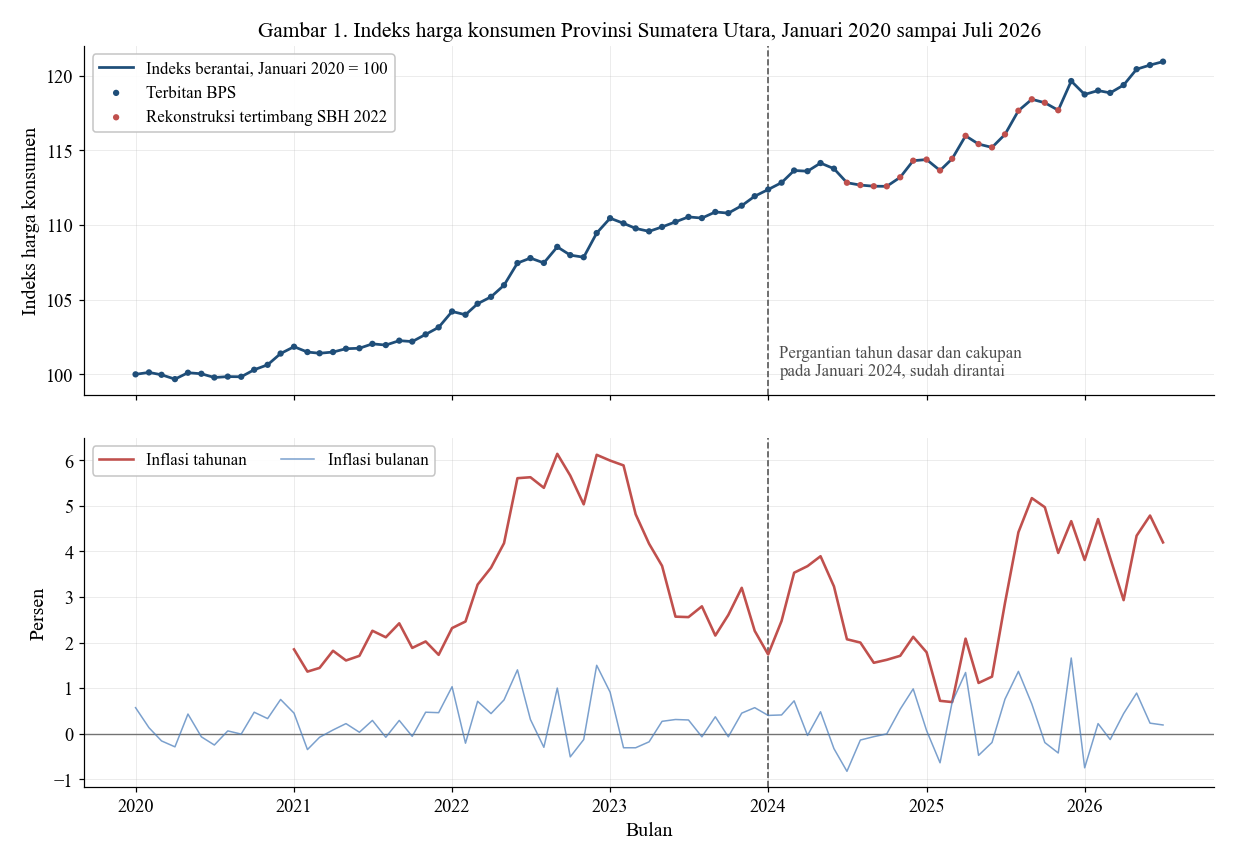

In [28]:
# Sel 12.1 - Gambar 1: indeks harga konsumen provinsi dan asal datanya

fig, sb = plt.subplots(2, 1, figsize=(11.0, 7.6), sharex=True)

d = PANEL_BULANAN.dropna(subset=["ihk_prov_berantai"]).copy()
d["waktu"] = d.t.dt.to_timestamp()

warna_asal = {"Terbitan BPS": PALET[0], "Rekonstruksi tertimbang SBH 2022": PALET[1]}
sb[0].plot(d.waktu, d.ihk_prov_berantai, color=PALET[0], linewidth=1.8, zorder=2,
           label="Indeks berantai, Januari 2020 = 100")
for asal, warna in warna_asal.items():
    m = d.ihk_prov_asal == asal
    if m.any():
        sb[0].scatter(d.loc[m, "waktu"], d.loc[m, "ihk_prov_berantai"], s=17,
                      color=warna, zorder=3, label=asal, edgecolors="none")
batas = pd.Timestamp("2024-01-01")
for s in sb:
    s.axvline(batas, color="0.35", linestyle="--", linewidth=1.1, zorder=1)
sb[0].annotate("Pergantian tahun dasar dan cakupan\npada Januari 2024, sudah dirantai",
               xy=(batas, sb[0].get_ylim()[0]), xytext=(7, 10),
               textcoords="offset points", fontsize=UKURAN - 2, color="0.30",
               ha="left", va="bottom")
sb[0].set_ylabel("Indeks harga konsumen")
sb[0].set_title("Gambar 1. Indeks harga konsumen Provinsi Sumatera Utara, Januari 2020 sampai Juli 2026")
sb[0].legend(loc="upper left", ncol=1, fontsize=UKURAN - 2)

sb[1].axhline(0, color="0.45", linewidth=0.9, zorder=1)
sb[1].plot(d.waktu, d.inflasi_yoy_final, color=PALET[1], linewidth=1.7,
           label="Inflasi tahunan")
sb[1].plot(d.waktu, d.inflasi_mtm_final, color=PALET[2], linewidth=1.0, alpha=0.75,
           label="Inflasi bulanan")
sb[1].set_ylabel("Persen")
sb[1].set_xlabel("Bulan")
sb[1].legend(loc="upper left", ncol=2, fontsize=UKURAN - 2)

simpan_gambar(fig, "gambar_01_ihk_provinsi",
              "Indeks harga konsumen provinsi hasil chain-linking dan laju inflasinya")
plt.show()

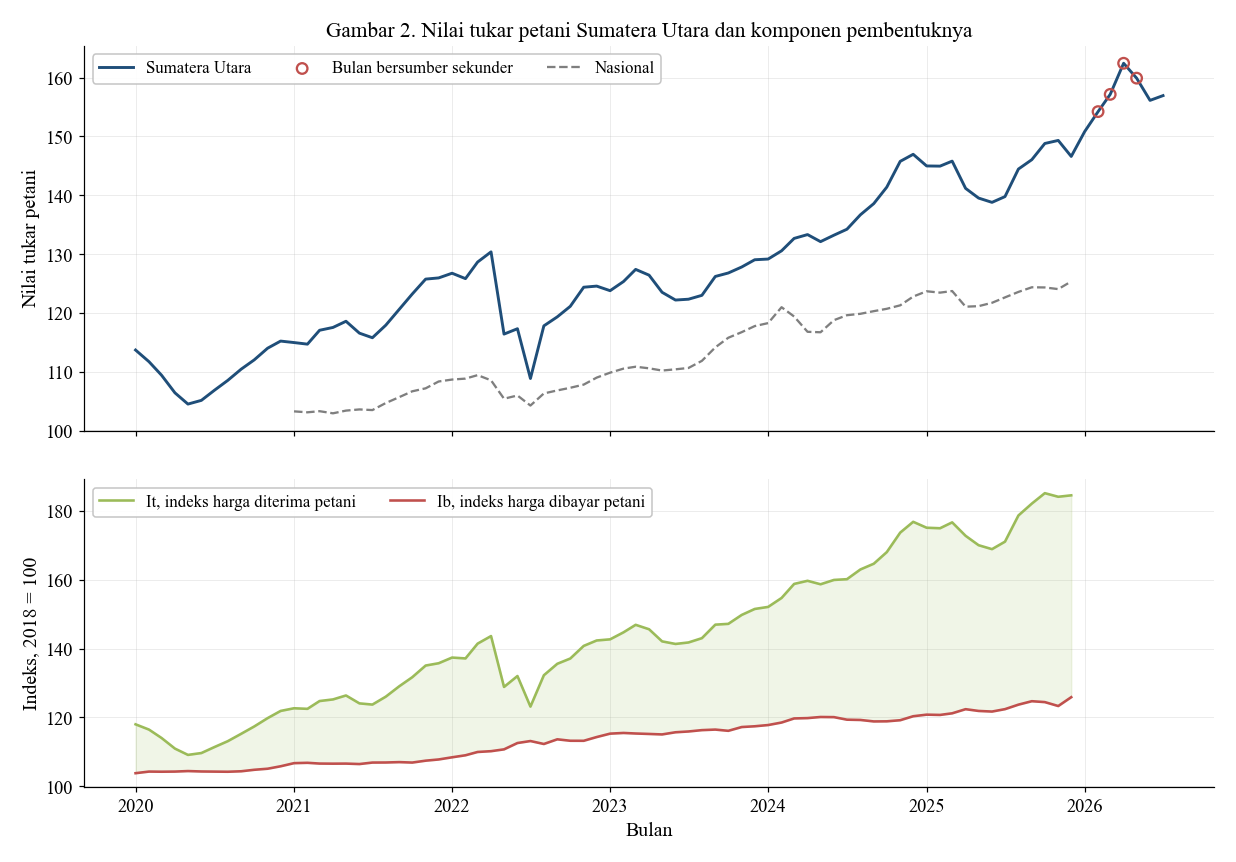

In [29]:
# Sel 12.2 - Gambar 2: nilai tukar petani dan komponennya

fig, sb = plt.subplots(2, 1, figsize=(11.0, 7.6), sharex=True,
                       gridspec_kw={"height_ratios": [1.25, 1.0]})

n = PANEL_BULANAN.dropna(subset=["NTP_Sumut"]).copy()
n["waktu"] = n.t.dt.to_timestamp()
k = PANEL_BULANAN.dropna(subset=["It_Sumut", "Ib_Sumut"]).copy()
k["waktu"] = k.t.dt.to_timestamp()

primer = n.sumber_primer.fillna(False).astype(bool)
sb[0].plot(n.waktu, n.NTP_Sumut, color=PALET[0], linewidth=1.9, label="Sumatera Utara")
if (~primer).any():
    sb[0].scatter(n.loc[~primer, "waktu"], n.loc[~primer, "NTP_Sumut"], s=48,
                  facecolors="none", edgecolors=PALET[1], linewidths=1.5, zorder=4,
                  label="Bulan bersumber sekunder")
if "NTP_Nasional" in n.columns and n.NTP_Nasional.notna().any():
    sb[0].plot(n.waktu, n.NTP_Nasional, color=PALET[7], linewidth=1.5,
               linestyle="--", label="Nasional")
sb[0].axhline(100, color="0.45", linewidth=0.9, zorder=1)
sb[0].set_ylabel("Nilai tukar petani")
sb[0].set_title("Gambar 2. Nilai tukar petani Sumatera Utara dan komponen pembentuknya")
sb[0].legend(loc="upper left", ncol=3, fontsize=UKURAN - 2)

sb[1].plot(k.waktu, k.It_Sumut, color=PALET[3], linewidth=1.7,
           label="It, indeks harga diterima petani")
sb[1].plot(k.waktu, k.Ib_Sumut, color=PALET[1], linewidth=1.7,
           label="Ib, indeks harga dibayar petani")
sb[1].fill_between(k.waktu, k.Ib_Sumut, k.It_Sumut,
                   where=k.It_Sumut >= k.Ib_Sumut, color=PALET[3], alpha=0.14)
sb[1].set_ylabel("Indeks, 2018 = 100")
sb[1].set_xlabel("Bulan")
sb[1].legend(loc="upper left", ncol=2, fontsize=UKURAN - 2)

simpan_gambar(fig, "gambar_02_ntp_it_ib",
              "Nilai tukar petani bulanan beserta indeks harga diterima dan dibayar petani")
plt.show()

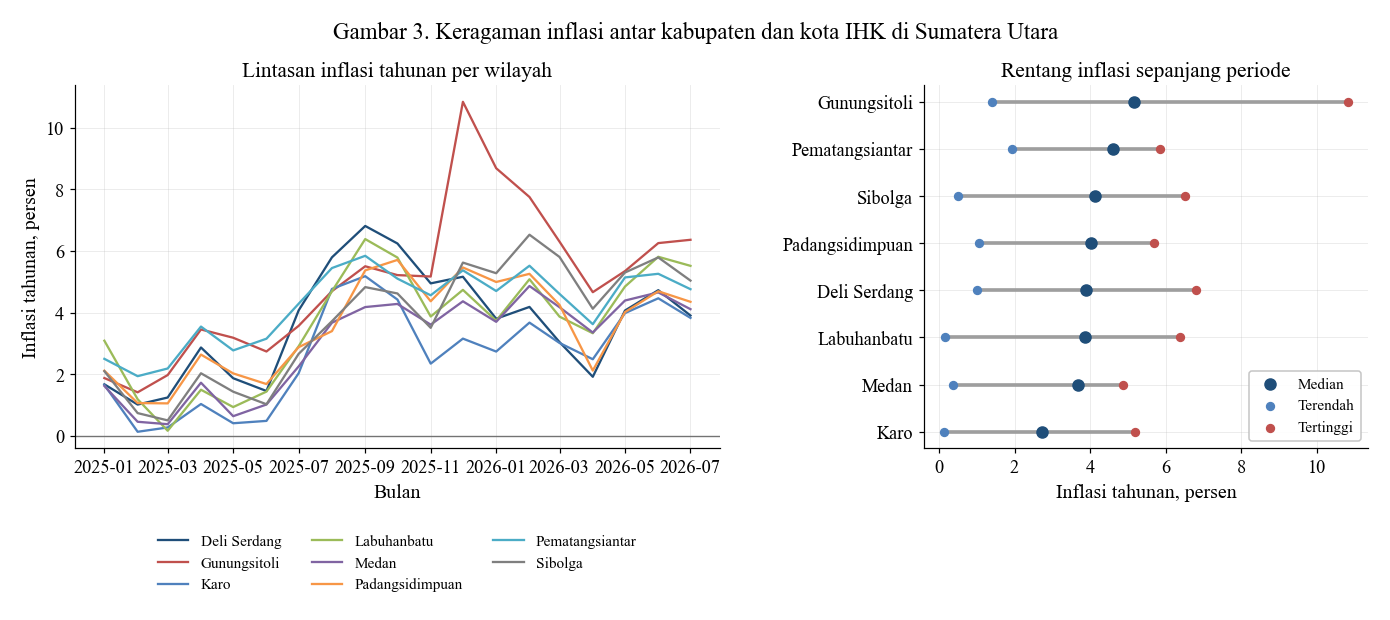

Selisih inflasi tertinggi dan terendah antar wilayah pada tiap bulan:
count    19.00
mean      2.88
std       1.55
min       1.36
25%       1.99
50%       2.54
75%       2.80
max       7.68


In [30]:
# Sel 12.3 - Gambar 3: ragam inflasi antar wilayah IHK

pv = (KOTA8.dropna(subset=["ihk_pakai"])
      .pivot_table(index="periode", columns="wilayah", values="ihk_pakai"))
yoy = (pv.pct_change(12) * 100).dropna(how="all")
yoy = yoy.loc[yoy.index >= "2025-01"]

fig, sb = plt.subplots(1, 2, figsize=(12.4, 5.4),
                       gridspec_kw={"width_ratios": [1.45, 1.0]})

waktu = pd.PeriodIndex(yoy.index, freq="M").to_timestamp()
for i, kol in enumerate(yoy.columns):
    sb[0].plot(waktu, yoy[kol], linewidth=1.5, color=PALET[i % len(PALET)], label=kol)
sb[0].axhline(0, color="0.45", linewidth=0.9)
sb[0].set_ylabel("Inflasi tahunan, persen")
sb[0].set_xlabel("Bulan")
sb[0].set_title("Lintasan inflasi tahunan per wilayah")
sb[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3,
             fontsize=UKURAN - 3, frameon=False)

sebar = yoy.agg(["min", "median", "max"]).T.sort_values("median")
posisi = np.arange(len(sebar))
sb[1].hlines(posisi, sebar["min"], sebar["max"], color="0.62", linewidth=2.4, zorder=1)
sb[1].scatter(sebar["median"], posisi, s=52, color=PALET[0], zorder=3, label="Median")
sb[1].scatter(sebar["min"], posisi, s=26, color=PALET[2], zorder=3, label="Terendah")
sb[1].scatter(sebar["max"], posisi, s=26, color=PALET[1], zorder=3, label="Tertinggi")
sb[1].set_yticks(posisi)
sb[1].set_yticklabels(sebar.index)
sb[1].set_xlabel("Inflasi tahunan, persen")
sb[1].set_title("Rentang inflasi sepanjang periode")
sb[1].legend(loc="lower right", fontsize=UKURAN - 3)

fig.suptitle("Gambar 3. Keragaman inflasi antar kabupaten dan kota IHK di Sumatera Utara")
simpan_gambar(fig, "gambar_03_ragam_inflasi_wilayah",
              "Perbandingan lintasan dan rentang inflasi tahunan antar wilayah IHK")
plt.show()

print("Selisih inflasi tertinggi dan terendah antar wilayah pada tiap bulan:")
rentang_bulanan = (yoy.max(axis=1) - yoy.min(axis=1)).describe().round(2)
print(rentang_bulanan.to_string())

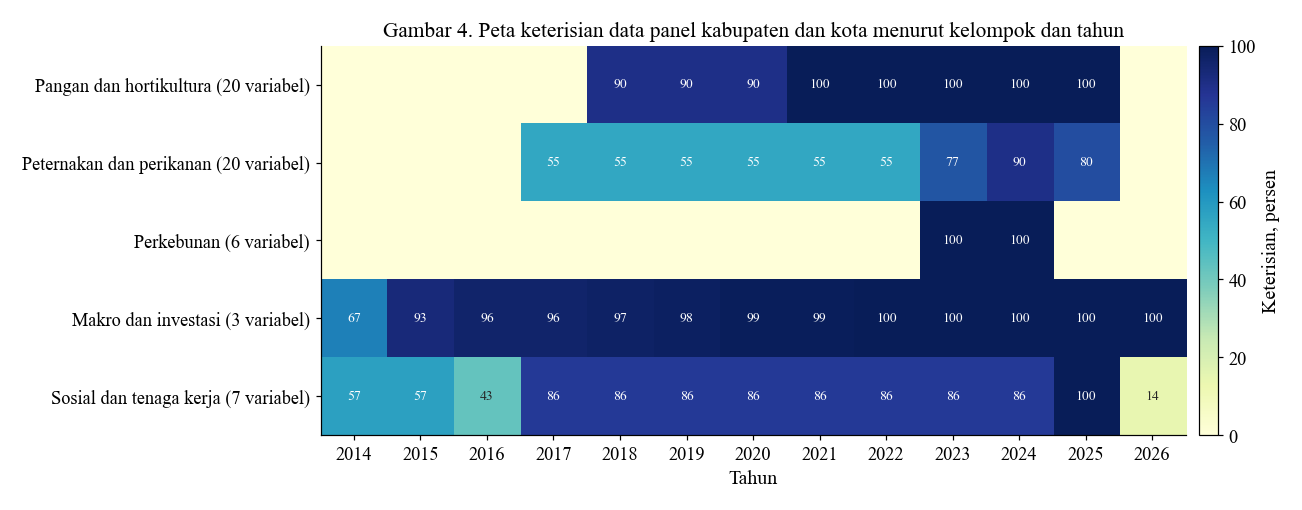

Jendela tahun dengan keterisian minimal 50 persen, dihitung per kelompok:
   Pangan dan hortikultura (20 variabel)        2018 sampai 2025 (8 tahun)
   Peternakan dan perikanan (20 variabel)       2017 sampai 2025 (9 tahun)
   Perkebunan (6 variabel)                      2023 sampai 2024 (2 tahun)
   Makro dan investasi (3 variabel)             2014 sampai 2026 (13 tahun)
   Sosial dan tenaga kerja (7 variabel)         2014 sampai 2025 (11 tahun)

Kesimpulan pemilihan periode. Blok pangan, peternakan, dan sosial memiliki jendela
panjang, sedangkan perkebunan dan perikanan hanya dua tahun. Karena itu notebook 02
tidak memakai satu periode tunggal untuk semua variabel. Blok berjendela panjang
diestimasi pada panel penuh, sedangkan perkebunan dan perikanan masuk sebagai
penampang lintang pada tahun yang tersedia, dengan konsekuensi tersebut dinyatakan
secara terbuka pada bagian keterbatasan naskah.


In [31]:
# Sel 12.4 - Gambar 4: peta ketersediaan data panel tahunan

kelompok_var = {
    "Pangan dan hortikultura": [c for c in PANEL.columns
                                if c.startswith(("Padi_", "Beras_", "Hortikultura_"))],
    "Peternakan dan perikanan": [c for c in PANEL.columns
                                 if c.startswith(("Ternak_", "Unggas_", "Daging_",
                                                  "Telur_", "Perikanan_"))],
    "Perkebunan": [c for c in PANEL.columns if c.startswith("Perkebunan_")],
    "Makro dan investasi": ["PDRB_miliarRp", "Investasi_PMA_PMDN_jutaRp", "Stok_Modal_jutaRp"],
    "Sosial dan tenaga kerja": ["Penduduk_Total_jiwa", "Kemiskinan_Persentase", "Gini_Ratio",
                                "TPT_persen", "TPAK_persen", "Pengeluaran_Total_Rp",
                                "GarisKemiskinan_Rp_kapita_bulan"],
}
tahun_uji = sorted([int(t) for t in PANEL.tahun.dropna().unique()])
kabx = PANEL[PANEL.kode_wilayah != KODE_PROVINSI]

matriks, label = [], []
for nama, kolom in kelompok_var.items():
    kolom = [c for c in kolom if c in kabx.columns]
    if not kolom:
        continue
    baris = []
    for thn in tahun_uji:
        sub = kabx[kabx.tahun == thn][kolom]
        baris.append(100 * sub.notna().to_numpy().mean() if sub.size else 0.0)
    matriks.append(baris)
    label.append(nama + " (" + str(len(kolom)) + " variabel)")

M = np.array(matriks)
fig, ax = plt.subplots(figsize=(11.6, 4.4))
gbr = ax.imshow(M, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
ax.set_xticks(range(len(tahun_uji)))
ax.set_xticklabels(tahun_uji)
ax.set_yticks(range(len(label)))
ax.set_yticklabels(label)
ax.set_xlabel("Tahun")
ax.grid(False)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        nilai = M[i, j]
        if nilai >= 1:
            ax.text(j, i, str(int(round(nilai))), ha="center", va="center",
                    fontsize=UKURAN - 4, color="white" if nilai > 55 else "0.15")
bar = fig.colorbar(gbr, ax=ax, pad=0.015)
bar.set_label("Keterisian, persen")
ax.set_title("Gambar 4. Peta keterisian data panel kabupaten dan kota menurut kelompok dan tahun")

simpan_gambar(fig, "gambar_04_peta_keterisian",
              "Persentase sel terisi pada panel kabupaten menurut kelompok variabel dan tahun")
plt.show()

print("Jendela tahun dengan keterisian minimal 50 persen, dihitung per kelompok:")
for i, nama in enumerate(label):
    thn = [t for j, t in enumerate(tahun_uji) if M[i, j] >= 50]
    rentang = (str(min(thn)) + " sampai " + str(max(thn)) + " (" + str(len(thn)) + " tahun)") \
              if thn else "tidak ada tahun yang memenuhi"
    print("  ", nama.ljust(44), rentang)
print()
print("Kesimpulan pemilihan periode. Blok pangan, peternakan, dan sosial memiliki jendela")
print("panjang, sedangkan perkebunan dan perikanan hanya dua tahun. Karena itu notebook 02")
print("tidak memakai satu periode tunggal untuk semua variabel. Blok berjendela panjang")
print("diestimasi pada panel penuh, sedangkan perkebunan dan perikanan masuk sebagai")
print("penampang lintang pada tahun yang tersedia, dengan konsekuensi tersebut dinyatakan")
print("secara terbuka pada bagian keterbatasan naskah.")

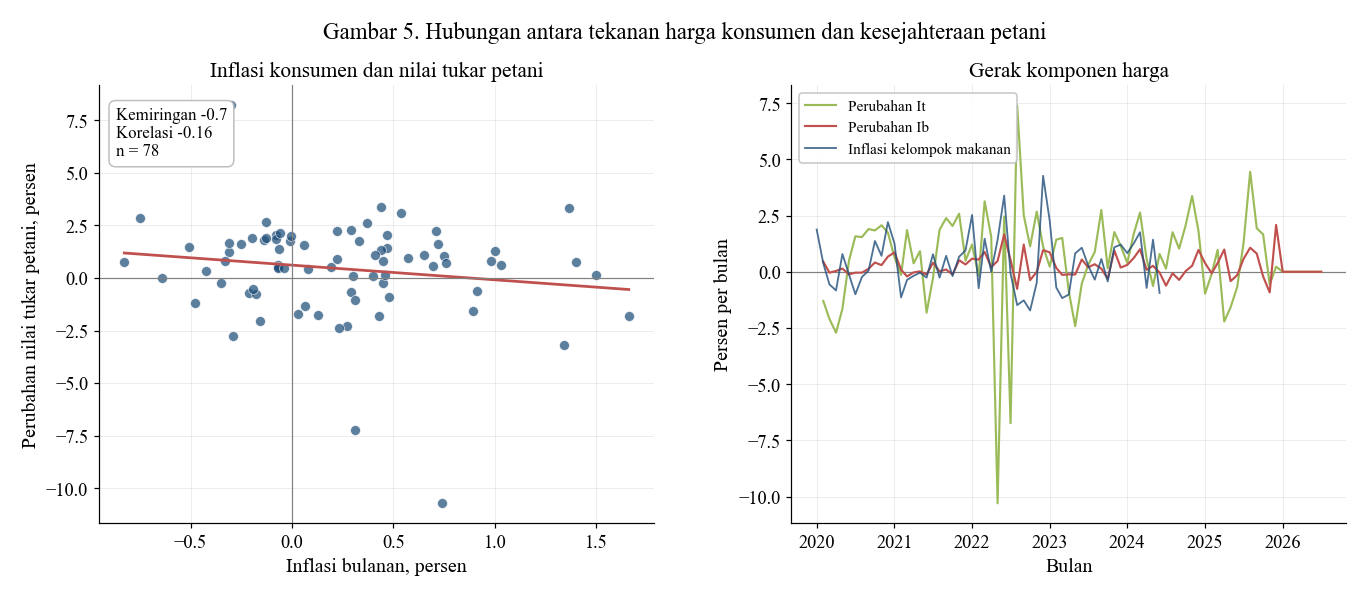

In [32]:
# Sel 12.5 - Gambar 5: ketegangan antara inflasi pangan dan kesejahteraan petani

kol_pangan = [c for c in PANEL_BULANAN.columns if c.startswith("mtm_Makanan")]
g5 = PANEL_BULANAN[["t", "periode", "NTP_Sumut", "inflasi_mtm_final",
                    "It_Sumut", "Ib_Sumut"] + kol_pangan].copy()
g5["waktu"] = g5.t.dt.to_timestamp()
g5["ntp_mtm"] = g5.NTP_Sumut.pct_change() * 100
g5["it_mtm"] = g5.It_Sumut.pct_change() * 100
g5["ib_mtm"] = g5.Ib_Sumut.pct_change() * 100

fig, sb = plt.subplots(1, 2, figsize=(12.2, 5.2))

pasangan = g5.dropna(subset=["ntp_mtm", "inflasi_mtm_final"])
sb[0].scatter(pasangan.inflasi_mtm_final, pasangan.ntp_mtm, s=42,
              color=PALET[0], alpha=0.72, edgecolors="white", linewidths=0.5)
if len(pasangan) > 3:
    b, a = np.polyfit(pasangan.inflasi_mtm_final, pasangan.ntp_mtm, 1)
    xs = np.linspace(pasangan.inflasi_mtm_final.min(), pasangan.inflasi_mtm_final.max(), 40)
    sb[0].plot(xs, a + b * xs, color=PALET[1], linewidth=1.8)
    r = np.corrcoef(pasangan.inflasi_mtm_final, pasangan.ntp_mtm)[0, 1]
    sb[0].text(0.03, 0.95, "Kemiringan " + str(round(b, 2)) +
               "\nKorelasi " + str(round(r, 2)) + "\nn = " + str(len(pasangan)),
               transform=sb[0].transAxes, va="top", ha="left", fontsize=UKURAN - 2,
               bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="0.75"))
sb[0].axhline(0, color="0.5", linewidth=0.8)
sb[0].axvline(0, color="0.5", linewidth=0.8)
sb[0].set_xlabel("Inflasi bulanan, persen")
sb[0].set_ylabel("Perubahan nilai tukar petani, persen")
sb[0].set_title("Inflasi konsumen dan nilai tukar petani")

sb[1].axhline(0, color="0.5", linewidth=0.8)
sb[1].plot(g5.waktu, g5.it_mtm, color=PALET[3], linewidth=1.4, label="Perubahan It")
sb[1].plot(g5.waktu, g5.ib_mtm, color=PALET[1], linewidth=1.4, label="Perubahan Ib")
if kol_pangan:
    sb[1].plot(g5.waktu, g5[kol_pangan[0]], color=PALET[0], linewidth=1.2,
               alpha=0.8, label="Inflasi kelompok makanan")
sb[1].set_xlabel("Bulan")
sb[1].set_ylabel("Persen per bulan")
sb[1].set_title("Gerak komponen harga")
sb[1].legend(loc="upper left", fontsize=UKURAN - 3, ncol=1)

fig.suptitle("Gambar 5. Hubungan antara tekanan harga konsumen dan kesejahteraan petani")
simpan_gambar(fig, "gambar_05_inflasi_vs_ntp",
              "Sebaran perubahan nilai tukar petani terhadap inflasi bulanan dan gerak komponennya")
plt.show()

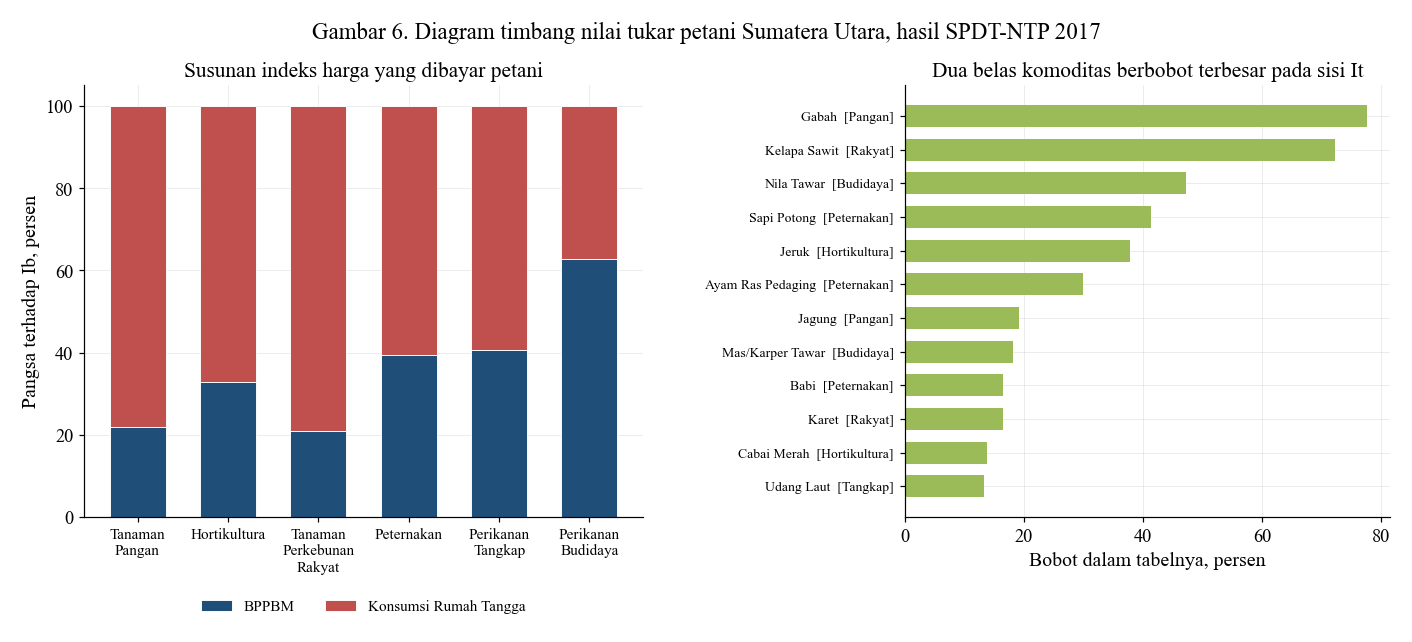

In [33]:
# Sel 12.6 - Gambar 6: struktur diagram timbang lima subsektor

sisi_ib = PENIMBANG_NTP[
    (PENIMBANG_NTP["Sisi"].astype(str).str.startswith("Ib")) &
    (PENIMBANG_NTP["Level"] == 1)].copy()
struktur = sisi_ib.pivot_table(index="Uraian_Baku", columns="Subsektor",
                               values="Diagram_Timbang_per_10000", aggfunc="sum")
struktur = struktur.dropna(how="all").fillna(0) / 100.0   # menjadi persen

fig, sb = plt.subplots(1, 2, figsize=(12.6, 5.6),
                       gridspec_kw={"width_ratios": [1.15, 1.0]})

subsektor = list(struktur.columns)
posisi = np.arange(len(subsektor))
dasar = np.zeros(len(subsektor))
for i, komponen in enumerate(struktur.index):
    nilai = struktur.loc[komponen].to_numpy()
    sb[0].bar(posisi, nilai, bottom=dasar, width=0.62,
              color=PALET[i % len(PALET)], label=str(komponen), edgecolor="white", linewidth=0.6)
    dasar = dasar + nilai
sb[0].set_xticks(posisi)
sb[0].set_xticklabels([s.split(". ")[-1].replace(" ", "\n") for s in subsektor],
                      fontsize=UKURAN - 3)
sb[0].set_ylabel("Pangsa terhadap Ib, persen")
sb[0].set_title("Susunan indeks harga yang dibayar petani")
sb[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2,
             fontsize=UKURAN - 3, frameon=False)

it_top = (PENIMBANG_NTP[(PENIMBANG_NTP["Sisi"].astype(str).str.startswith("It")) &
                        (PENIMBANG_NTP["Tipe"] == "Komoditas")]
          .nlargest(12, "Diagram_Timbang_per_10000"))
lbl = (it_top.Uraian.astype(str).str.slice(0, 24) + "  ["
       + it_top.Subsektor.astype(str).str.split(". ").str[-1].str.slice(0, 12) + "]")
pos2 = np.arange(len(it_top))[::-1]
sb[1].barh(pos2, it_top.Diagram_Timbang_per_10000 / 100.0, color=PALET[3], height=0.66)
sb[1].set_yticks(pos2)
sb[1].set_yticklabels(lbl, fontsize=UKURAN - 4)
sb[1].set_xlabel("Bobot dalam tabelnya, persen")
sb[1].set_title("Dua belas komoditas berbobot terbesar pada sisi It")

fig.suptitle("Gambar 6. Diagram timbang nilai tukar petani Sumatera Utara, hasil SPDT-NTP 2017")
simpan_gambar(fig, "gambar_06_diagram_timbang_ntp",
              "Susunan penimbang Ib per subsektor dan komoditas berbobot terbesar pada sisi It")
plt.show()

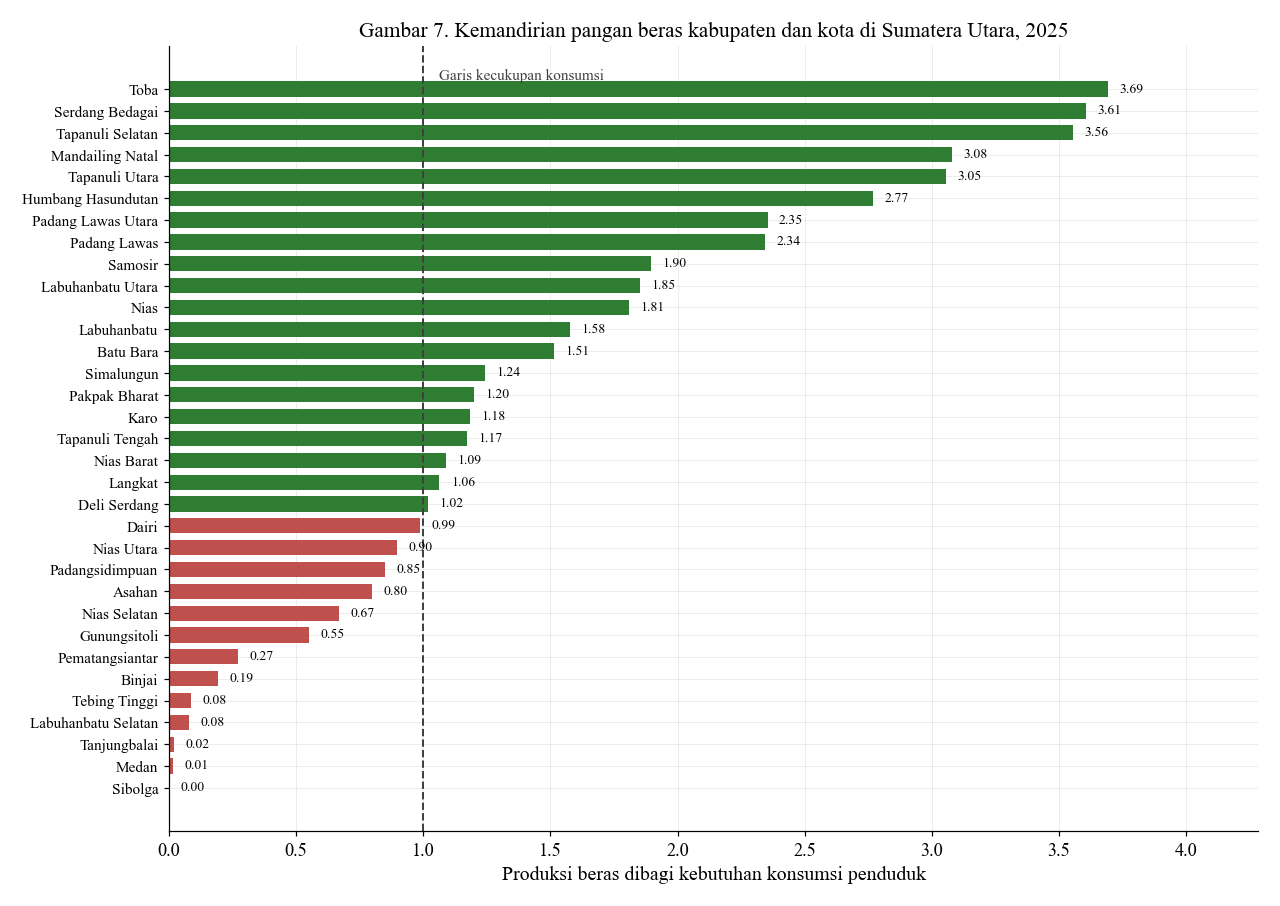

Tahun acuan          : 2025
Asumsi konsumsi      : 81.0 kg per kapita per tahun
Wilayah surplus beras: 20 dari 33
Wilayah defisit beras: 13
Rasio termiskin      : Sibolga 0.0
Rasio tertinggi      : Toba 3.694


In [34]:
# Sel 12.7 - Gambar 7: kemandirian pangan beras antar kabupaten dan kota

thn_pilih = int(kab.dropna(subset=["Rasio_Swasembada_Beras"]).tahun.max())
sw = (kab[kab.tahun == thn_pilih]
      .dropna(subset=["Rasio_Swasembada_Beras"])
      .sort_values("Rasio_Swasembada_Beras"))

fig, ax = plt.subplots(figsize=(11.4, 8.0))
warna = np.where(sw.Rasio_Swasembada_Beras >= 1.0, PALET[8], PALET[1])
pos = np.arange(len(sw))
ax.barh(pos, sw.Rasio_Swasembada_Beras, color=warna, height=0.70)
ax.axvline(1.0, color="0.25", linestyle="--", linewidth=1.3)
ax.set_yticks(pos)
ax.set_yticklabels(sw.wilayah, fontsize=UKURAN - 3)
ax.set_xlabel("Produksi beras dibagi kebutuhan konsumsi penduduk")
ax.set_title("Gambar 7. Kemandirian pangan beras kabupaten dan kota di Sumatera Utara, "
             + str(thn_pilih))
for p, v in zip(pos, sw.Rasio_Swasembada_Beras):
    ax.text(v + 0.045, p, format(v, ".2f"), va="center", ha="left", fontsize=UKURAN - 4)
ax.set_xlim(0, float(sw.Rasio_Swasembada_Beras.max()) * 1.16)
ax.annotate("Garis kecukupan konsumsi", xy=(1.0, len(sw) - 0.4), xytext=(10, 0),
            textcoords="offset points", fontsize=UKURAN - 3, color="0.25",
            ha="left", va="center")

simpan_gambar(fig, "gambar_07_swasembada_beras",
              "Rasio produksi beras terhadap kebutuhan konsumsi menurut kabupaten dan kota")
plt.show()

surplus = int((sw.Rasio_Swasembada_Beras >= 1).sum())
print("Tahun acuan          :", thn_pilih)
print("Asumsi konsumsi      :", KONSUMSI_BERAS_KAPITA, "kg per kapita per tahun")
print("Wilayah surplus beras:", surplus, "dari", len(sw))
print("Wilayah defisit beras:", len(sw) - surplus)
print("Rasio termiskin      :", sw.iloc[0]["wilayah"], round(float(sw.iloc[0].Rasio_Swasembada_Beras), 3))
print("Rasio tertinggi      :", sw.iloc[-1]["wilayah"], round(float(sw.iloc[-1].Rasio_Swasembada_Beras), 3))

---
## Bagian 13. Interpretasi otomatis

Sel di bawah menghasilkan ringkasan naratif dari angka angka yang sudah dihitung sepanjang notebook.
Perlu ditegaskan bagaimana ringkasan ini disusun, sebab hal ini menyangkut kejujuran akademik.

Setiap kalimat dalam ringkasan dibentuk dari kerangka kalimat tetap yang diisi oleh nilai yang benar
benar dihitung dari data, bukan dari model bahasa. Bila suatu nilai tidak tersedia, kalimatnya tidak
dicetak sama sekali dan digantikan pernyataan bahwa data tidak mencukupi. Tidak ada satu pun angka dalam
keluaran yang diperkirakan, dibulatkan ke angka yang lebih enak dibaca, atau ditambahkan untuk memperhalus
narasi. Ambang kualitatif seperti kata kuat, sedang, atau lemah ditetapkan lebih dahulu sebagai konstanta
di dalam kode dan dapat diperiksa langsung.

Ringkasan ini bukan pengganti pembahasan dalam naskah. Fungsinya adalah memberi titik berangkat yang
terverifikasi, agar penulisan pembahasan berpijak pada angka yang sama dengan yang tercetak di tabel.

In [35]:
# Sel 13.1 - Mesin interpretasi berbasis nilai terhitung

AMBANG_KORELASI = [(0.70, "kuat"), (0.40, "sedang"), (0.20, "lemah"), (0.00, "sangat lemah")]
AMBANG_KETERISIAN = [(90, "sangat baik"), (75, "baik"), (50, "cukup"), (0, "terbatas")]

def sebut(nilai, tangga):
    for batas, label in tangga:
        if abs(nilai) >= batas:
            return label
    return tangga[-1][1]

def angka(x, desimal=2):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return None
    return format(round(float(x), desimal), "." + str(desimal) + "f")

KALIMAT = []
def tulis(teks):
    if teks:
        KALIMAT.append(teks)

# Cakupan
tulis("CAKUPAN DATA")
tulis("Basis data terdiri atas " + format(int(INVENTARIS.n_baris.sum()), ",") +
      " baris dari " + str(len(INVENTARIS)) + " lembar kerja pada " +
      str(len(BERKAS)) + " berkas sumber.")
tulis("Gudang format panjang memuat " + format(len(GUDANG), ",") + " observasi yang mencakup " +
      str(GUDANG.domain.nunique()) + " domain statistik, " + str(GUDANG.indikator.nunique()) +
      " indikator, dan rentang tahun " + str(int(GUDANG.tahun.min())) + " sampai " +
      str(int(GUDANG.tahun.max())) + ".")
tulis("Tingkat keterisian nilai pada gudang adalah " +
      angka(100 * GUDANG.nilai_std.notna().mean(), 1) + " persen, tergolong " +
      sebut(100 * GUDANG.nilai_std.notna().mean(), AMBANG_KETERISIAN) + ".")
tulis("Panel tahunan meliputi " + str(len(KODE_KABKOTA)) + " kabupaten dan kota ditambah baris provinsi, " +
      "dengan " + str(PANEL.tahun.nunique()) + " tahun amatan.")
tulis("Panel bulanan provinsi meliputi " + str(len(PANEL_BULANAN)) + " bulan, dari " +
      str(PANEL_BULANAN.periode.iloc[0]) + " sampai " + str(PANEL_BULANAN.periode.iloc[-1]) + ".")

# Hasil penyambungan indeks
tulis("")
tulis("PENYAMBUNGAN INDEKS HARGA")
lolos_pct = 100 * (uji_id.selisih <= TOLERANSI).mean()
tulis("Identitas antara level indeks dan inflasi bulanan terbitan diuji pada " +
      format(len(uji_id), ",") + " pasangan. Sebanyak " + angka(lolos_pct, 2) +
      " persen lolos toleransi " + str(TOLERANSI) + " poin persen, sehingga angka inflasi bulanan " +
      "layak dipakai sebagai jembatan chain-linking.")
if len(uji_rekon):
    tulis("Rekonstruksi indeks provinsi dari delapan wilayah IHK dengan penimbang nilai konsumsi " +
          "dasar SBH 2022 diuji pada " + str(len(uji_rekon)) + " bulan yang angkanya diterbitkan. " +
          "Galat rata rata mutlak sebesar " + angka(uji_rekon.selisih.abs().mean(), 3) +
          " poin indeks atau " + angka(uji_rekon.selisih_persen.abs().mean(), 3) + " persen.")
n_tambal = int((PANEL_BULANAN.ihk_prov_asal == "Rekonstruksi tertimbang SBH 2022").sum())
if n_tambal:
    tulis("Sebanyak " + str(n_tambal) + " bulan yang semula kosong pada seri provinsi berhasil " +
          "ditambal, sehingga seri bulanan menjadi utuh sepanjang " + str(len(PANEL_BULANAN)) +
          " bulan tanpa terputus.")

# Kesejahteraan petani
tulis("")
tulis("NILAI TUKAR PETANI")
n = PANEL_BULANAN.dropna(subset=["NTP_Sumut"])
if len(n) >= 12:
    awal, akhir = float(n.NTP_Sumut.iloc[0]), float(n.NTP_Sumut.iloc[-1])
    tulis("Nilai tukar petani bergerak dari " + angka(awal) + " pada " + str(n.periode.iloc[0]) +
          " menjadi " + angka(akhir) + " pada " + str(n.periode.iloc[-1]) + ", setara perubahan " +
          angka(100 * (akhir / awal - 1), 1) + " persen sepanjang periode.")
    tulis("Nilai tertinggi tercatat " + angka(n.NTP_Sumut.max()) + " pada " +
          str(n.loc[n.NTP_Sumut.idxmax(), "periode"]) + " dan terendah " +
          angka(n.NTP_Sumut.min()) + " pada " + str(n.loc[n.NTP_Sumut.idxmin(), "periode"]) + ".")
    bulan_bawah_100 = int((n.NTP_Sumut < 100).sum())
    if bulan_bawah_100:
        tulis("Terdapat " + str(bulan_bawah_100) + " bulan dengan nilai tukar petani di bawah 100, " +
              "yaitu keadaan ketika daya tukar hasil pertanian lebih rendah dibanding tahun dasar.")
    else:
        tulis("Tidak ada satu pun bulan dengan nilai tukar petani di bawah 100, sehingga sepanjang " +
              "periode daya tukar hasil pertanian selalu berada di atas posisi tahun dasar 2018.")
k = PANEL_BULANAN.dropna(subset=["It_Sumut", "Ib_Sumut"])
if len(k) >= 12:
    it_naik = 100 * (float(k.It_Sumut.iloc[-1]) / float(k.It_Sumut.iloc[0]) - 1)
    ib_naik = 100 * (float(k.Ib_Sumut.iloc[-1]) / float(k.Ib_Sumut.iloc[0]) - 1)
    tulis("Sepanjang " + str(k.periode.iloc[0]) + " sampai " + str(k.periode.iloc[-1]) +
          ", indeks harga yang diterima petani naik " + angka(it_naik, 1) +
          " persen sedangkan indeks harga yang dibayar petani naik " + angka(ib_naik, 1) +
          " persen. Selisih " + angka(it_naik - ib_naik, 1) +
          " poin persen inilah yang menjelaskan arah gerak nilai tukar petani.")

# Hubungan inflasi dan nilai tukar petani
tulis("")
tulis("HUBUNGAN INFLASI DAN KESEJAHTERAAN PETANI")
ps = PANEL_BULANAN.copy()
ps["ntp_mtm"] = ps.NTP_Sumut.pct_change() * 100
ps = ps.dropna(subset=["ntp_mtm", "inflasi_mtm_final"])
if len(ps) >= 24:
    r = float(np.corrcoef(ps.inflasi_mtm_final, ps.ntp_mtm)[0, 1])
    b = float(np.polyfit(ps.inflasi_mtm_final, ps.ntp_mtm, 1)[0])
    arah = "searah" if r > 0 else "berlawanan arah"
    tulis("Korelasi kontemporer antara inflasi bulanan dan perubahan nilai tukar petani sebesar " +
          angka(r) + ", tergolong " + sebut(r, AMBANG_KORELASI) + " dan " + arah + ".")
    tulis("Kemiringan regresi sederhana menunjukkan bahwa setiap satu poin persen inflasi bulanan " +
          "berkaitan dengan perubahan nilai tukar petani sebesar " + angka(b) +
          " persen pada bulan yang sama, dihitung dari " + str(len(ps)) + " pasangan amatan.")
    tulis("Angka ini bersifat asosiatif dan bukan sebab akibat. Pemisahan arah pengaruh " +
          "memerlukan model dinamis dengan struktur delay, yang dikerjakan pada notebook 02.")

# Kemandirian pangan
tulis("")
tulis("KEMANDIRIAN PANGAN BERAS")
if len(sw):
    tulis("Pada " + str(thn_pilih) + ", sebanyak " + str(surplus) + " dari " + str(len(sw)) +
          " kabupaten dan kota memiliki produksi beras yang melampaui kebutuhan konsumsi " +
          "penduduknya pada asumsi " + angka(KONSUMSI_BERAS_KAPITA, 0) +
          " kilogram per kapita per tahun.")
    tulis("Rasio tertinggi dimiliki " + str(sw.iloc[-1]["wilayah"]) + " sebesar " +
          angka(sw.iloc[-1].Rasio_Swasembada_Beras) + " dan terendah " + str(sw.iloc[0]["wilayah"]) +
          " sebesar " + angka(sw.iloc[0].Rasio_Swasembada_Beras) + ".")
    kota_defisit = sw[(sw.Rasio_Swasembada_Beras < 1) &
                      (sw.wilayah.isin(registri[registri.level_wilayah == "Kota"].wilayah))]
    tulis("Sebanyak " + str(len(kota_defisit)) + " wilayah berstatus kota mengalami defisit, " +
          "yang wajar mengingat kota bukan sentra produksi. Implikasinya, ketahanan pangan kota " +
          "sepenuhnya bergantung pada kelancaran distribusi antardaerah, dan ini menjadi salah " +
          "satu jalur umpan balik yang harus dimodelkan secara eksplisit.")

# Keragaman antar wilayah
tulis("")
tulis("KERAGAMAN ANTAR WILAYAH")
if len(yoy):
    selisih_rt = float((yoy.max(axis=1) - yoy.min(axis=1)).mean())
    selisih_mx = float((yoy.max(axis=1) - yoy.min(axis=1)).max())
    tulis("Selisih antara inflasi tertinggi dan terendah antar wilayah IHK rata rata sebesar " +
          angka(selisih_rt) + " poin persen per bulan, dengan selisih terbesar " +
          angka(selisih_mx) + " poin persen.")
    tulis("Besarnya keragaman ini menunjukkan bahwa kebijakan pengendalian harga tingkat provinsi " +
          "yang seragam akan menghasilkan dampak yang tidak merata antar daerah, sehingga " +
          "pemodelan pada tingkat kabupaten dan kota memang diperlukan.")

# Mutu data
tulis("")
tulis("CATATAN MUTU DATA")
if len(adit):
    tulis("Uji aditivitas mandiri atas " + format(len(adit), ",") + " kombinasi menunjukkan " +
          angka(100 * adit.lolos.mean(), 2) + " persen konsisten dalam toleransi " +
          str(AMBANG_ADIT) + " persen.")
if len(PATAHAN):
    n_tinggi = int((PATAHAN.tingkat_perhatian == "Tinggi").sum())
    n_berjalan = int((PATAHAN.tingkat_perhatian == "Bukan patahan").sum())
    tulis("Deteksi patahan struktural menemukan " + str(len(PATAHAN)) + " kejadian, " +
          str(n_tinggi) + " di antaranya berperhatian tinggi karena menimpa lebih dari " +
          "tujuh puluh persen wilayah secara serentak, sedangkan " + str(n_berjalan) +
          " kejadian ternyata hanya akibat tahun berjalan yang belum lengkap.")
    tulis("Variabel yang terkena patahan sejati tidak boleh dipakai dalam bentuk laju " +
          "pertumbuhan yang melintasi tahun patahan, sebab lompatannya berasal dari " +
          "perubahan cara mengukur dan bukan dari gerak ekonomi.")
if len(PENCILAN):
    tulis("Sebanyak " + format(len(PENCILAN), ",") + " titik ditandai sebagai pencilan terhadap " +
          "sejarah wilayahnya sendiri. Seluruhnya dipertahankan dan hanya dicatat untuk ditinjau.")
if STATSMODELS and len(ADF):
    n_stasioner = int(ADF[ADF.bentuk == "tingkat"].stasioner_5persen.sum())
    n_total = int((ADF.bentuk == "tingkat").sum())
    tulis("Uji akar unit menunjukkan " + str(n_stasioner) + " dari " + str(n_total) +
          " seri bulanan inti stasioner pada tingkat. Sisanya menjadi stasioner setelah " +
          "pembedaan pertama, sehingga pemodelan pada notebook 02 memakai bentuk pembedaan " +
          "atau kerangka koreksi galat bila ditemukan kointegrasi.")

RINGKASAN = "\n".join(KALIMAT)
print(RINGKASAN)

with open(DIR_KELUARAN / "log" / "ringkasan_otomatis.txt", "w", encoding="utf-8") as f:
    f.write(RINGKASAN)
if DIR_DRIVE is not None:
    with open(DIR_DRIVE / "log" / "ringkasan_otomatis.txt", "w", encoding="utf-8") as f:
        f.write(RINGKASAN)

CAKUPAN DATA
Basis data terdiri atas 271,102 baris dari 109 lembar kerja pada 13 berkas sumber.
Gudang format panjang memuat 127,328 observasi yang mencakup 11 domain statistik, 58 indikator, dan rentang tahun 1990 sampai 2026.
Tingkat keterisian nilai pada gudang adalah 97.6 persen, tergolong sangat baik.
Panel tahunan meliputi 33 kabupaten dan kota ditambah baris provinsi, dengan 13 tahun amatan.
Panel bulanan provinsi meliputi 79 bulan, dari 2020-01 sampai 2026-07.
PENYAMBUNGAN INDEKS HARGA
Identitas antara level indeks dan inflasi bulanan terbitan diuji pada 5,652 pasangan. Sebanyak 98.97 persen lolos toleransi 0.06 poin persen, sehingga angka inflasi bulanan layak dipakai sebagai jembatan chain-linking.
Rekonstruksi indeks provinsi dari delapan wilayah IHK dengan penimbang nilai konsumsi dasar SBH 2022 diuji pada 14 bulan yang angkanya diterbitkan. Galat rata rata mutlak sebesar 0.004 poin indeks atau 0.003 persen.
Sebanyak 17 bulan yang semula kosong pada seri provinsi berhasil d

---
## Bagian 14. Ekspor dan manifes keluaran

Seluruh tabel hasil ditulis ke folder keluaran, dan bila Google Drive terdeteksi, disalin ke sana juga.
Manifes di bawah mencatat setiap berkas beserta ukuran dan jumlah barisnya, sehingga notebook berikutnya
dapat memeriksa bahwa yang dibacanya adalah berkas yang sama dengan yang ditulis di sini.

Sidik jari MD5 berkas sumber turut dicatat. Bila suatu saat berkas sumber diperbarui, sidik jarinya akan
berubah dan hal itu akan langsung terlihat, sehingga tidak akan terjadi keadaan di mana hasil notebook 03
dihitung dari data yang berbeda dengan notebook 01.

In [36]:
# Sel 14.1 - Manifes keluaran

def catat_berkas(path):
    p = Path(path)
    if not p.exists():
        return None
    n = None
    try:
        if p.suffix == ".csv":
            n = sum(1 for _ in open(p, encoding="utf-8")) - 1
        elif p.suffix == ".gz":
            import gzip
            with gzip.open(p, "rt", encoding="utf-8") as f:
                n = sum(1 for _ in f) - 1
        elif p.suffix == ".parquet":
            n = len(pd.read_parquet(p))
    except Exception:
        n = None
    return {"berkas": str(p.relative_to(DIR_KELUARAN)), "ukuran_kb": round(p.stat().st_size / 1024, 1),
            "n_baris": n}

manifes = [catat_berkas(p) for p in sorted(DIR_KELUARAN.rglob("*"))
           if p.is_file() and p.suffix in [".csv", ".gz", ".parquet", ".png", ".txt"]]
MANIFES = pd.DataFrame([m for m in manifes if m])
MANIFES.to_csv(DIR_KELUARAN / "log" / "manifes_keluaran.csv", index=False)
if DIR_DRIVE is not None:
    MANIFES.to_csv(DIR_DRIVE / "log" / "manifes_keluaran.csv", index=False)

print("MANIFES KELUARAN")
print("Folder lokal :", DIR_KELUARAN)
print("Folder Drive :", DIR_DRIVE if DIR_DRIVE else "tidak tersedia")
print("Jumlah berkas:", len(MANIFES))
print("Total ukuran :", round(MANIFES.ukuran_kb.sum() / 1024, 2), "MB")
print()
print(MANIFES.to_string(index=False))
print()
print("SIDIK JARI BERKAS SUMBER")
print(INVENTARIS[["berkas", "sidik_md5"]].drop_duplicates().to_string(index=False))

MANIFES KELUARAN
Folder lokal : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut
Folder Drive : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook01_20260830
Jumlah berkas: 21
Total ukuran : 14.45 MB

                                    berkas  ukuran_kb  n_baris
         gambar/gambar_01_ihk_provinsi.png      405.0      NaN
            gambar/gambar_02_ntp_it_ib.png      320.6      NaN
gambar/gambar_03_ragam_inflasi_wilayah.png      496.1      NaN
      gambar/gambar_04_peta_keterisian.png      192.8      NaN
       gambar/gambar_05_inflasi_vs_ntp.png      404.1      NaN
  gambar/gambar_06_diagram_timbang_ntp.png      268.2      NaN
     gambar/gambar_07_swasembada_beras.png      346.2      NaN
              gudang/gudang_panjang.csv.gz     1738.0 127328.0
                log/ringkasan_otomatis.txt        4.1      NaN
          mutu/inventaris_lembar_kerja.csv       17.3    120.0
          

In [37]:
# Sel 14.2 - Ringkasan mutu gabungan untuk lampiran naskah

baris_mutu = [
    {"pemeriksaan": "Pembacaan lembar kerja",
     "lingkup": str(len(INVENTARIS)) + " lembar pada " + str(len(BERKAS)) + " berkas",
     "hasil": str(int((INVENTARIS.baris_judul >= 0).sum())) + " lembar terbaca, "
              + str(int((INVENTARIS.kolom_tak_bernama > INVENTARIS.n_kolom * 0.4).sum()))
              + " lembar bermasalah",
     "status": "LULUS" if int((INVENTARIS.baris_judul == -1).sum()) == 0 else "PERIKSA"},
    {"pemeriksaan": "Pemetaan nama wilayah ke kode BPS",
     "lingkup": "seluruh tabel yang memakai nama wilayah sebagai kunci",
     "hasil": str(len(gagal) + len(gagal2)) + " nama gagal dipetakan",
     "status": "LULUS" if (len(gagal) + len(gagal2)) == 0 else "PERIKSA"},
    {"pemeriksaan": "Identitas level indeks dan inflasi bulanan",
     "lingkup": format(len(uji_id), ",") + " pasangan bulan",
     "hasil": angka(100 * (uji_id.selisih <= TOLERANSI).mean(), 2) + " persen lolos toleransi "
              + str(TOLERANSI) + " poin persen",
     "status": "LULUS" if (uji_id.selisih <= TOLERANSI).mean() > 0.95 else "PERIKSA"},
    {"pemeriksaan": "Identitas NTP sama dengan It dibagi Ib kali 100",
     "lingkup": str(len(sah)) + " bulan",
     "hasil": "selisih terbesar " + angka(sah.selisih.max(), 3),
     "status": "LULUS" if sah.selisih.max() < 0.05 else "PERIKSA"},
    {"pemeriksaan": "Rekonstruksi IHK provinsi terhadap angka terbitan",
     "lingkup": str(len(uji_rekon)) + " bulan luar sampel",
     "hasil": "galat rata rata " + angka(uji_rekon.selisih.abs().mean(), 3) + " poin indeks",
     "status": "LULUS" if uji_rekon.selisih.abs().mean() <= AMBANG_REKON else "PERIKSA"},
    {"pemeriksaan": "Aditivitas kabupaten terhadap total provinsi",
     "lingkup": format(len(adit), ",") + " kombinasi",
     "hasil": angka(100 * adit.lolos.mean(), 2) + " persen konsisten",
     "status": "LULUS" if adit.lolos.mean() > 0.99 else "PERIKSA"},
    {"pemeriksaan": "Jumlah pangsa komoditas diagram timbang IHK",
     "lingkup": str(kom.groupby(['Sumber', 'Wilayah']).ngroups) + " tabel wilayah",
     "hasil": "penyimpangan terbesar dari 100 sebesar "
              + angka(float((uji_jumlah - 100).abs().max()), 4) + " persen",
     "status": "LULUS" if float((uji_jumlah - 100).abs().max()) < 0.01 else "PERIKSA"},
    {"pemeriksaan": "Jumlah diagram timbang NTP terhadap 10.000",
     "lingkup": str(len(uji_ntp)) + " tabel subsektor kali sisi",
     "hasil": "penyimpangan terbesar " + angka(float(uji_ntp.selisih_dari_10000.abs().max()), 2),
     "status": "LULUS" if float(uji_ntp.selisih_dari_10000.abs().max()) < 1.0 else "PERIKSA"},
    {"pemeriksaan": "Deteksi patahan struktural",
     "lingkup": str(len(kol_uji)) + " variabel panel tahunan",
     "hasil": str(len(PATAHAN)) + " patahan terdeteksi, "
              + str(int((PATAHAN.tingkat_perhatian == 'Tinggi').sum()) if len(PATAHAN) else 0)
              + " berperhatian tinggi setelah tahun berjalan dikecualikan",
     "status": "INFORMASI"},
    {"pemeriksaan": "Deteksi pencilan terhadap sejarah wilayah",
     "lingkup": str(len(kol_uji)) + " variabel kali " + str(len(KODE_KABKOTA)) + " wilayah",
     "hasil": str(len(PENCILAN)) + " titik ditandai, tidak ada yang dibuang",
     "status": "INFORMASI"},
]
if STATSMODELS and len(ADF):
    baris_mutu.append({
        "pemeriksaan": "Uji akar unit Dickey Fuller diperluas",
        "lingkup": str(ADF.variabel.nunique()) + " seri bulanan inti",
        "hasil": str(int(ADF[ADF.bentuk == 'selisih pertama'].stasioner_5persen.sum())) + " dari "
                 + str(int((ADF.bentuk == 'selisih pertama').sum()))
                 + " stasioner pada pembedaan pertama",
        "status": "INFORMASI"})

LAPORAN_MUTU = pd.DataFrame(baris_mutu)
simpan(LAPORAN_MUTU, "mutu/laporan_mutu.csv")

print("LAPORAN MUTU GABUNGAN")
print(LAPORAN_MUTU.to_string(index=False))
print()
print("Jumlah pemeriksaan berstatus LULUS   :", int((LAPORAN_MUTU.status == "LULUS").sum()))
print("Jumlah pemeriksaan berstatus PERIKSA :", int((LAPORAN_MUTU.status == "PERIKSA").sum()))
print("Jumlah catatan informasi             :", int((LAPORAN_MUTU.status == "INFORMASI").sum()))
print()
print("Katalog gambar yang dihasilkan:")
for g in KATALOG_GAMBAR:
    print("  ", g["berkas"].ljust(38), g["keterangan"])

LAPORAN MUTU GABUNGAN
                                      pemeriksaan                                               lingkup                                                                              hasil    status
                           Pembacaan lembar kerja                             109 lembar pada 13 berkas                                            109 lembar terbaca, 0 lembar bermasalah     LULUS
                Pemetaan nama wilayah ke kode BPS seluruh tabel yang memakai nama wilayah sebagai kunci                                                             0 nama gagal dipetakan     LULUS
       Identitas level indeks dan inflasi bulanan                                  5,652 pasangan bulan                                      98.97 persen lolos toleransi 0.06 poin persen     LULUS
  Identitas NTP sama dengan It dibagi Ib kali 100                                              72 bulan                                                             selisih terbesar 0.011    

---
## Bagian 15. Apa yang dikerjakan notebook berikutnya

Notebook ini berhenti tepat sebelum estimasi. Berikut rencana kerja tiga notebook selanjutnya, agar
pembaca mengetahui bagaimana keluaran di sini akan dipakai.

**Notebook 02, estimasi struktur keterkaitan.** Matriks pembobot spasial disusun dari ketetanggaan dan
jarak antar kabupaten, lalu dipakai dalam model panel spasial dinamis untuk blok tahunan dan model vektor
autoregresi panel untuk blok bulanan. Keluarannya adalah tabel parameter beserta selang kepercayaannya,
termasuk elastisitas harga terhadap produksi, elastisitas kemiskinan terhadap harga pangan, dan fungsi
respons impuls yang menggambarkan berapa lama guncangan harga meredam.

**Notebook 03, penyusunan dan kalibrasi model dinamika sistem.** Parameter dari notebook 02 dimasukkan ke
dalam struktur stok dan aliran. Stok diintegrasikan secara numerik, variabel bantu dihitung ulang tiap
langkah waktu. Model diuji dengan rangkaian uji validasi baku untuk model dinamika sistem, yaitu uji
boundary adequacy test, uji dimensional consistency test, uji perilaku pada nilai ekstrem, dan uji
kesesuaian terhadap data historis. Model yang gagal salah satu uji tidak dipakai untuk simulasi.

**Notebook 04, optimisasi kebijakan dan dashboard.** Ruang kebijakan ditelusuri dengan optimisasi
banyak tujuan, sebab tujuan tujuan dalam kerangka acuan Sumatranomics memang saling bertentangan:
menekan inflasi cenderung menekan harga yang diterima petani, sementara menaikkan harga yang diterima
petani menaikkan biaya konsumen. Hasilnya adalah kumpulan kebijakan Pareto optimal, bukan satu jawaban
tunggal. Kumpulan itu kemudian dituangkan menjadi dashboard HTML mandiri yang dapat dijalankan tanpa
server, sehingga pemerintah daerah dapat mencoba sendiri berbagai skenario.

Satu hal yang perlu dijaga sepanjang rangkaian ini. Setiap angka yang muncul di dashboard harus dapat
ditelusuri balik sampai ke halaman PDF publikasi BPS yang menjadi sumbernya. Kolom nomor halaman sudah
dipertahankan pada seluruh tabel demi keperluan itu.

---
## Daftar pustaka

Sumber sumber berikut dipakai untuk landasan metode dan untuk definisi baku yang dikutip sepanjang
notebook ini. Seluruh tautan sudah diperiksa dapat diakses. Prioritas diberikan pada sumber yang terbuka
tanpa berlangganan.

### Sumber data

Badan Pusat Statistik. (2020). *Diagram timbang nilai tukar petani, hasil Survei Penyempurnaan Diagram
Timbang NTP 2017* (Buku 1 sampai Buku 5). Jakarta: Badan Pusat Statistik.

Badan Pusat Statistik. (2023). *Diagram timbang indeks harga konsumen hasil Survei Biaya Hidup 2022*.
Jakarta: Badan Pusat Statistik.

Badan Pusat Statistik. (2024). *Nilai tukar petani menurut provinsi (2018 = 100)* [Tabel statistik].
https://www.bps.go.id/id/statistics-table/2/MTc0MSMy/ntp-nilai-tukar-petani-menurut-provinsi-2018-100-.html

Badan Pusat Statistik Provinsi Sumatera Utara. (2026). *Nilai tukar petani Provinsi Sumatera Utara pada
Januari 2026 sebesar 150,83 atau naik 2,88 persen* [Berita resmi statistik].
https://sumut.bps.go.id/id/pressrelease/2026/02/02/1404/nilai-tukar-petani-provinsi-sumatera-utara-pada-januari-2026-sebesar-150-83-atau-naik-2-88-persen.html

### Metode indeks harga dan penyambungan antar tahun dasar

International Labour Office, International Monetary Fund, Organisation for Economic Co-operation and
Development, Statistical Office of the European Communities, United Nations, & World Bank. (2004).
*Consumer price index manual: Theory and practice*. Geneva: International Labour Office.
https://www.imf.org/external/np/sta/cpi/manual/2004/eng/cpi_manual.pdf

International Monetary Fund. (2020). *Consumer price index manual: Concepts and methods*. Washington, DC:
International Monetary Fund. https://www.imf.org/en/Publications/Manuals-Guides/Issues/2020/11/19/Consumer-Price-Index-Manual-Concepts-and-Methods-48179

### Metode pemodelan dinamika sistem

Forrester, J. W. (1961). *Industrial dynamics*. Cambridge, MA: MIT Press.

Barlas, Y. (1996). Formal aspects of model validity and validation in system dynamics. *System Dynamics
Review, 12*(3), 183-210. https://doi.org/10.1002/(SICI)1099-1727(199623)12:3<183::AID-SDR103>3.0.CO;2-4

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex world*. Boston:
Irwin McGraw-Hill.

Sterman, J. D. (2002). All models are wrong: Reflections on becoming a systems scientist. *System Dynamics
Review, 18*(4), 501-531. https://doi.org/10.1002/sdr.261

### Metode akumulasi modal dan statistik

Harberger, A. C. (1978). Perspectives on capital and technology in less developed countries. In M. J.
Artis & A. R. Nobay (Eds.), *Contemporary economic analysis* (pp. 15-40). London: Croom Helm.

Iglewicz, B., & Hoaglin, D. C. (1993). *How to detect and handle outliers*. Milwaukee: American Society
for Quality Control Press.

Said, S. E., & Dickey, D. A. (1984). Testing for unit roots in autoregressive moving average models of
unknown order. *Biometrika, 71*(3), 599-607. https://doi.org/10.1093/biomet/71.3.599

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.
https://doi.org/10.18637/jss.v059.i10

### Perangkat lunak

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., Wieser, E.,
Taylor, J., Berg, S., Smith, N. J., Kern, R., Picus, M., Hoyer, S., van Kerkwijk, M. H., Brett, M.,
Haldane, A., del Rio, J. F., Wiebe, M., Peterson, P., ... Oliphant, T. E. (2020). Array programming with
NumPy. *Nature, 585*, 357-362. https://doi.org/10.1038/s41586-020-2649-2

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science and Engineering, 9*(3),
90-95. https://doi.org/10.1109/MCSE.2007.55

McKinney, W. (2010). Data structures for statistical computing in Python. In S. van der Walt & J. Millman
(Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 56-61).
https://doi.org/10.25080/Majora-92bf1922-00a

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. In
S. van der Walt & J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 92-96).
https://doi.org/10.25080/Majora-92bf1922-011

---

### Catatan penutup

Notebook ini tidak mengubah satu pun angka publikasi. Setiap koreksi yang dilakukan, yaitu penyatuan dua
kolom PDRB, chain-linking antar tahun dasar, dan rekonstruksi indeks provinsi pada bulan yang kosong,
disimpan pada kolom terpisah dengan penanda asal, sehingga angka aslinya tetap dapat dibaca dan
dibandingkan. Prinsip yang dipegang sederhana: data sumber tidak boleh diperbaiki secara diam diam, dan
setiap turunan harus menyebutkan dirinya sebagai turunan.

In [38]:
# Sel penutup - ringkasan eksekusi

print("=" * 78)
print("NOTEBOOK 01 SELESAI")
print("=" * 78)
print("Waktu selesai   :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Folder keluaran :", DIR_KELUARAN)
print("Salinan Drive   :", DIR_DRIVE if DIR_DRIVE else "tidak dibuat")
print()
print("Tabel siap pakai untuk notebook 02:")
for nama, obj in [("registri_wilayah", registri),
                  ("panel_tahunan_kabkota", PANEL),
                  ("panel_bulanan_provinsi", PANEL_BULANAN),
                  ("panel_bulanan_ihk_kabkota", KOTA8),
                  ("panel_harga_kabupaten", PANEL_HARGA),
                  ("penimbang_ihk", PENIMBANG_IHK),
                  ("penimbang_ntp", PENIMBANG_NTP),
                  ("registri_variabel_sistem", REGISTRI_VARIABEL),
                  ("gudang_panjang", GUDANG)]:
    print("  ", nama.ljust(28), str(obj.shape[0]).rjust(8), "baris x",
          str(obj.shape[1]).rjust(3), "kolom")
print()
print("Gambar:", len(KATALOG_GAMBAR), "berkas pada resolusi 300 dpi")
print("Pemeriksaan mutu:", len(LAPORAN_MUTU), "butir,",
      int((LAPORAN_MUTU.status == "LULUS").sum()), "lulus,",
      int((LAPORAN_MUTU.status == "PERIKSA").sum()), "perlu diperiksa")
print()
print("Langkah berikutnya: jalankan Notebook 02 pada folder yang sama.")

NOTEBOOK 01 SELESAI
Waktu selesai   : 2026-08-30 22:10:50
Folder keluaran : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut
Salinan Drive   : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook01_20260830

Tabel siap pakai untuk notebook 02:
   registri_wilayah                   34 baris x   9 kolom
   panel_tahunan_kabkota             442 baris x  82 kolom
   panel_bulanan_provinsi             79 baris x  37 kolom
   panel_bulanan_ihk_kabkota         488 baris x  14 kolom
   panel_harga_kabupaten           84397 baris x   9 kolom
   penimbang_ihk                    6272 baris x  13 kolom
   penimbang_ntp                    2641 baris x  19 kolom
   registri_variabel_sistem           69 baris x   8 kolom
   gudang_panjang                 127328 baris x  24 kolom

Gambar: 7 berkas pada resolusi 300 dpi
Pemeriksaan mutu: 11 butir, 8 lulus, 0 perlu diperiksa

Langkah berikutnya: jalankan Notebo

In [39]:
# Sel opsional - penulisan panel tahunan yang sudah diperkaya

simpan(PANEL, "tabel/panel_tahunan_kabkota.csv")
print("panel_tahunan_kabkota.csv ditulis:", PANEL.shape[0], "baris x", PANEL.shape[1], "kolom")
print()
print("Kolom yang ditambahkan notebook ini di luar panel asal BPS:")
for k in ["PDRB_miliarRp", "PDRB_sumber", "Stok_Modal_jutaRp", "Rasio_Swasembada_Beras",
          "Intensitas_Lahan_Padi", "Beban_Pangan_thd_GarisKemiskinan",
          "Modal_per_Kapita_jutaRp", "PDRB_per_Kapita_jutaRp"]:
    if k in PANEL.columns:
        n = int(PANEL[PANEL.kode_wilayah != KODE_PROVINSI][k].notna().sum()) \
            if PANEL[k].dtype.kind in "fi" else int(PANEL[k].notna().sum())
        print("  ", k.ljust(36), str(n).rjust(4), "baris terisi")

panel_tahunan_kabkota.csv ditulis: 442 baris x 82 kolom

Kolom yang ditambahkan notebook ini di luar panel asal BPS:
   PDRB_miliarRp                         429 baris terisi
   PDRB_sumber                           442 baris terisi
   Stok_Modal_jutaRp                     429 baris terisi
   Rasio_Swasembada_Beras                264 baris terisi
   Intensitas_Lahan_Padi                 264 baris terisi
   Beban_Pangan_thd_GarisKemiskinan      297 baris terisi
   Modal_per_Kapita_jutaRp               330 baris terisi
   PDRB_per_Kapita_jutaRp                330 baris terisi
